# Portfolio Management — from Theory to a Live SET100 Portfolio

This notebook turns three lectures of *2604-639 Finance Theories* into working Python, then applies
the whole toolkit to a real universe: **all 100 constituents of the SET100 index (Stock Exchange of
Thailand)**.

| Part | Lecture | What is built |
|---|---|---|
| **I** | Topic 4 — The MV Analysis | Expected utility & moments, the mean-variance criterion, portfolio mathematics, diversification, the efficient frontier, the CAL and Tobin separation |
| **II** | Topic 5 — The Single Index Model | Single factor model, the market model / SCL, risk decomposition, the SIM covariance matrix, Treynor–Black active portfolio |
| **III** | Topic 6 — The CAPM | CML, SML, equilibrium expected returns, Jensen's alpha, zero-beta / ICAPM / CCAPM, the two-pass empirical test, Roll's critique |
| **IV** | **Real case** | The machinery applied to the **SET100 universe of exactly 100 stocks**: SIM estimation for every name, three covariance estimators, long-only efficient frontier, tangency portfolio, capital allocation, Treynor–Black tilts, a cross-sectional CAPM test, and an out-of-sample backtest |
| **V** | Topic 7 — The APT | Arbitrage and the no-arbitrage equilibrium, K-factor models, deriving $E[r_i]=\lambda_0+\sum\beta_{i,k}\lambda_k$, APT vs CAPM, and the three routes to factors (statistical, macroeconomic, characteristic) |
| **VI** | **The comparison** | All three APT routes implemented on the SET100 — PCA factors, a Thai macro-factor model, and Fama–French style characteristic factors — then a **walk-forward horse race of all 14 techniques** from Topics 4–7 with realistic turnover costs |

Every formula from the slides is written out in LaTeX first, then evaluated in code, and the
textbook numerical examples are reproduced so the implementation can be checked against the lecture.
Part VI closes the loop: every technique is run through one identical out-of-sample protocol so they
can be compared on returns, risk, alpha, turnover and cost — not on theory.

---

## Notation used throughout

| Symbol | Meaning |
|---|---|
| $r_i,\;R_i = r_i - r_F$ | return and **excess** return on asset $i$ |
| $\mathbf{w}$ | $N\times 1$ vector of portfolio weights, $\mathbf{w}^\top\mathbf{1}=1$ |
| $\mathbf{r}$ | $N\times 1$ vector of expected returns, $E[r_p]=\mathbf{w}^\top\mathbf{r}$ |
| $V$ | $N\times N$ variance–covariance matrix, $\sigma_p^2=\mathbf{w}^\top V\mathbf{w}$ |
| $r_F$ | risk-free rate; $M$ = market portfolio; $A$ = coefficient of risk aversion |
| $\alpha_i,\beta_i,\sigma_{\varepsilon i}^2$ | SCL intercept, slope and residual variance of asset $i$ |

In [1]:
# ============================================================
# 0.1 Environment
# ============================================================
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy import stats

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda v: f"{v:,.6f}")

np.set_printoptions(suppress=True, precision=6)
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["axes.axisbelow"] = True

print("numpy", np.__version__, "| pandas", pd.__version__)

numpy 2.4.4 | pandas 3.0.2


## 0.2 The frontier toolkit

Every optimisation in this notebook comes from one of five closed forms or one of three numerical
programs. They are collected here once and reused in Parts I–IV.

**Portfolio moments (Topic 4, §3.1)**

$$E[r_p]=\mathbf{w}^\top\mathbf{r},\qquad \sigma_p^2=\mathbf{w}^\top V\mathbf{w}
=\sum_{i=1}^{N}\sum_{j=1}^{N}w_iw_j\sigma_{i,j}$$

**Frontier scalars.** With $\mathbf{1}$ a vector of ones,

$$A=\mathbf{1}^\top V^{-1}\mathbf{1},\quad B=\mathbf{1}^\top V^{-1}\mathbf{r},\quad
C=\mathbf{r}^\top V^{-1}\mathbf{r},\quad D=AC-B^2$$

**Minimum-variance weights for a target return** $\mu_p$ (short sales allowed) — solving
$\min_w \frac12 w^\top Vw$ s.t. $w^\top r=\mu_p,\;w^\top\mathbf 1=1$ gives the two-fund form

$$\mathbf{w}(\mu_p)=\mathbf{g}+\mathbf{h}\,\mu_p,\qquad
\mathbf{g}=\frac{C\,V^{-1}\mathbf 1-B\,V^{-1}\mathbf r}{D},\qquad
\mathbf{h}=\frac{A\,V^{-1}\mathbf r-B\,V^{-1}\mathbf 1}{D}$$

**The frontier hyperbola and the GMV portfolio**

$$\sigma_p^2(\mu_p)=\frac{A\mu_p^2-2B\mu_p+C}{D},\qquad
\mathbf{w}_{GMV}=\frac{V^{-1}\mathbf 1}{A},\quad \mu_{GMV}=\frac BA,\quad \sigma_{GMV}=\frac1{\sqrt A}$$

**Tangency (optimal risky) portfolio** — the portfolio that maximises the slope of the CAL,
$SR_P=(E[r_P]-r_F)/\sigma_P$ (Topic 4, §4.2):

$$\mathbf{w}_T=\frac{V^{-1}(\mathbf r-r_F\mathbf 1)}{\mathbf 1^\top V^{-1}(\mathbf r-r_F\mathbf 1)}$$

**Optimal capital allocation** for quadratic utility $U=E[r]-\tfrac12A\sigma^2$:

$$y^*=\frac{E[r_P]-r_F}{A\,\sigma_P^2}$$

When short sales are banned the closed forms no longer apply and the problems are solved
numerically with SLSQP under $w_i\ge 0,\;\sum w_i=1$.

In [2]:
# ============================================================
# 0.3 Frontier toolkit  (closed forms + no-short-sale programs)
# ============================================================

def port_moments(w, mu, V):
    # E[r_p] = w'r  and  sigma_p = sqrt(w'Vw)
    w = np.asarray(w, float)
    return float(w @ np.asarray(mu, float)), float(np.sqrt(w @ np.asarray(V, float) @ w))


def frontier_scalars(mu, V):
    # A, B, C, D and the two-fund vectors g, h.
    mu, V = np.asarray(mu, float), np.asarray(V, float)
    one = np.ones(len(mu))
    Vi = np.linalg.inv(V)
    A = float(one @ Vi @ one)
    B = float(one @ Vi @ mu)
    C = float(mu @ Vi @ mu)
    D = A * C - B ** 2
    g = (C * (Vi @ one) - B * (Vi @ mu)) / D
    h = (A * (Vi @ mu) - B * (Vi @ one)) / D
    return dict(mu=mu, V=V, Vi=Vi, A=A, B=B, C=C, D=D, g=g, h=h)


def weights_for_return(fs, mu_target):
    # w(mu) = g + h*mu
    return fs["g"] + fs["h"] * mu_target


def frontier_sigma(fs, mu_grid):
    # sigma_p(mu) on the hyperbola  sigma^2 = (A mu^2 - 2B mu + C)/D
    mu_grid = np.asarray(mu_grid, float)
    return np.sqrt((fs["A"] * mu_grid ** 2 - 2 * fs["B"] * mu_grid + fs["C"]) / fs["D"])


def gmv_portfolio(fs):
    w = fs["Vi"] @ np.ones(len(fs["mu"])) / fs["A"]
    return dict(w=w, mu=fs["B"] / fs["A"], sd=1.0 / np.sqrt(fs["A"]))


def tangency_portfolio(fs, rf):
    excess = fs["mu"] - rf
    raw = fs["Vi"] @ excess
    w = raw / raw.sum()
    mu_t, sd_t = port_moments(w, fs["mu"], fs["V"])
    return dict(w=w, mu=mu_t, sd=sd_t, sharpe=(mu_t - rf) / sd_t)


def optimal_y(mu_p, sd_p, rf, A):
    # y* = (E[r_P] - rF) / (A sigma_P^2)
    return (mu_p - rf) / (A * sd_p ** 2)


# ---------- numerical programs used when short sales are banned ----------

def _solve(fun, n, cons, cap, x0=None):
    x0 = np.repeat(1.0 / n, n) if x0 is None else x0
    res = minimize(fun, x0, method="SLSQP", bounds=[(0.0, cap)] * n,
                   constraints=cons, options={"maxiter": 1000, "ftol": 1e-12})
    return res


def min_var_long_only(mu, V, target=None, cap=1.0):
    # min w'Vw   s.t. sum(w)=1, w>=0, (optionally) w'mu = target
    mu, V, n = np.asarray(mu, float), np.asarray(V, float), len(mu)
    cons = [{"type": "eq", "fun": lambda x: x.sum() - 1.0}]
    if target is not None:
        cons.append({"type": "eq", "fun": lambda x, t=target: x @ mu - t})
    res = _solve(lambda x: x @ V @ x, n, cons, cap)
    return res.x if res.success else np.full(n, np.nan)


def max_sharpe_long_only(mu, V, rf, cap=1.0):
    # max (w'mu - rF)/sqrt(w'Vw)  s.t. sum(w)=1, w>=0
    mu, V, n = np.asarray(mu, float), np.asarray(V, float), len(mu)
    cons = [{"type": "eq", "fun": lambda x: x.sum() - 1.0}]
    res = _solve(lambda x: -(x @ mu - rf) / np.sqrt(x @ V @ x), n, cons, cap)
    return res.x if res.success else np.full(n, np.nan)


def frontier_long_only(mu, V, n_points=40, cap=1.0):
    # Trace the no-short-sale frontier between the GMV return and the highest feasible return.
    mu = np.asarray(mu, float)
    w_gmv = min_var_long_only(mu, V, cap=cap)
    lo = float(w_gmv @ mu)
    hi = float(np.sort(mu)[::-1][: int(np.ceil(1.0 / cap))].mean()) if cap < 1 else float(mu.max())
    targets = np.linspace(lo, hi, n_points)
    rows = []
    for t in targets:
        w = min_var_long_only(mu, V, target=t, cap=cap)
        if np.isnan(w).any():
            continue
        m, s = port_moments(w, mu, V)
        rows.append((m, s, w))
    return pd.DataFrame({"mu": [r[0] for r in rows], "sd": [r[1] for r in rows]}), [r[2] for r in rows]

print("toolkit loaded")

toolkit loaded


---
# Part I — Topic 4: The Mean-Variance Analysis

## 1. Moments of the return distribution and expected utility

Let $r$ be the (random) investment return and $W=W_0(1+r)$ terminal wealth. Expanding $U(1+r)$ in a
Taylor series around the fixed point $1+E[r]$ and taking expectations,

$$E[U(1+r)] = U(1+E[r]) + \frac{U''(1+E[r])}{2!}\sigma^2
+ \frac{U'''(1+E[r])}{3!}\mu^3 + \frac{U^{(4)}(1+E[r])}{4!}\mu^4 + \dots$$

so expected utility depends on **all** moments. Empirically only the first few matter, and for an
average investor

$$U'>0 \;\Rightarrow\; E[r] \text{ desirable},\qquad
U''<0 \;\Rightarrow\; \sigma^2 \text{ undesirable},\qquad
U'''>0 \;\Rightarrow\; \text{positive skewness desirable}$$

### When is looking only at $(E[r],\sigma)$ legitimate?

**Case 1 — quadratic utility.** With $U(W)=a+bW+cW^2$, $b>0$, $c<0$:

$$E[U(W)] = a + bE[W] + cE[W]^2 + c\,\sigma_W^2,
\qquad E[W]=W_0(1+E[r]),\quad \sigma_W^2 = W_0^2\sigma_r^2$$

Expected utility is **exactly** a function of the first two moments only, increasing in $E[r]$ and
decreasing in $\sigma_r^2$.

**Case 2 — normally distributed returns.** If $r\sim N(E[r],\sigma_r)$ then $r=E[r]+z\sigma_r$ with
$z\sim N(0,1)$, so

$$E[U(W)]=\int U\big(W_0(1+E[r]+z\sigma_r)\big)f(z)\,dz$$

Because $f(z)$ and $W_0$ are the same across assets, the only things that distinguish one asset from
another are $E[r]$ and $\sigma_r$ — for **any** utility function with $U'>0,\;U''<0$.

In [3]:
# ============================================================
# 1.1 Quadratic utility — worked example from the lecture
#     U(W) = a + bW + cW^2,  a=1, b=100, c=-0.1, W0 = $100
# ============================================================
def eu_quadratic(mu_r, sd_r, W0=100.0, a=1.0, b=100.0, c=-0.1):
    EW = W0 * (1 + mu_r)                 # E[W]  = W0 (1 + E[r])
    varW = (W0 ** 2) * sd_r ** 2         # var[W] = W0^2 sigma_r^2
    return a + b * EW + c * EW ** 2 + c * varW

alts = pd.DataFrame({"E[r]": [0.01, 0.02], "SD[r]": [0.02, 0.01]}, index=["A", "B"])
alts["E[U(W)]"] = [eu_quadratic(m, s) for m, s in zip(alts["E[r]"], alts["SD[r]"])]
display(alts)

print(f"E[U(W_B)] - E[U(W_A)] = {alts.loc['B','E[U(W)]'] - alts.loc['A','E[U(W)]']:,.1f}")
print("B is preferred, which agrees with the MV criterion (higher E[r] AND lower sigma).")

# The mean-variance utility form used later for capital allocation: U = E[r] - 0.5 A sigma^2
def mv_utility(mu_r, sd_r, A):
    return mu_r - 0.5 * A * sd_r ** 2

print("\nCertainty-equivalent form  U = E[r] - 0.5*A*sigma^2  (A = 3):")
for k, row in alts.iterrows():
    print(f"  {k}: U = {mv_utility(row['E[r]'], row['SD[r]'], 3):.6f}")

,E[r],SD[r],E[U(W)]
A,0.010000,0.020000,"9,080.500000"
B,0.020000,0.010000,"9,160.500000"


E[U(W_B)] - E[U(W_A)] = 80.0
B is preferred, which agrees with the MV criterion (higher E[r] AND lower sigma).

Certainty-equivalent form  U = E[r] - 0.5*A*sigma^2  (A = 3):
  A: U = 0.009400
  B: U = 0.019850


**Check.** $E[U(W_A)] = 1 + 100(101) - 0.1(101)^2 - 0.1(100^2\times0.02^2) = 9{,}080.5$ and
$E[U(W_B)] = 9{,}160.5$ — exactly the lecture's numbers. $B$ dominates $A$ on both moments, and the
quadratic-utility ranking agrees, which is the point of the example.

## 2. The mean-variance criterion (MVC)

> Investment $F$ dominates $G$ by the MVC **iff** $E[r_F]\ge E[r_G]$ **and** $\sigma_F^2\le\sigma_G^2$,
> with at least one strict inequality.

The criterion splits the opportunity set into an **efficient set** and an **inefficient set**; every
investor of this class chooses from the efficient set only.

In [4]:
# ============================================================
# 2.1 MVC dominance — the 5-alternative example
# ============================================================
mvc = pd.DataFrame({"E[r]": [10, 8, 9, 11, 12],
                    "Var": [10, 11, 10, 12, 11]},
                   index=list("ABCDE"))

def mv_efficient_set(df, mu_col="E[r]", var_col="Var"):
    # X is dominated if some Y has  E[rY] >= E[rX] and VarY <= VarX  with one strict inequality.
    dominated = set()
    for x in df.index:
        for y in df.index:
            if x == y:
                continue
            ge = df.loc[y, mu_col] >= df.loc[x, mu_col]
            le = df.loc[y, var_col] <= df.loc[x, var_col]
            strict = (df.loc[y, mu_col] > df.loc[x, mu_col]) or (df.loc[y, var_col] < df.loc[x, var_col])
            if ge and le and strict:
                dominated.add(x)
                break
    return [i for i in df.index if i not in dominated], sorted(dominated)

eff, ineff = mv_efficient_set(mvc)
mvc["status"] = ["efficient" if i in eff else "inefficient" for i in mvc.index]
display(mvc)
print("Efficient set :", eff)
print("Inefficient   :", ineff, "  (A dominates B and C; E dominates D)")

,E[r],Var,status
A,10,10,efficient
B,8,11,inefficient
C,9,10,inefficient
D,11,12,inefficient
E,12,11,efficient


Efficient set : ['A', 'E']
Inefficient   : ['B', 'C', 'D']   (A dominates B and C; E dominates D)


**Answer.** The efficient set is $\{A, E\}$ — $A$ dominates $B$ and $C$, and $E$ dominates $D$. An
investor need only compare $A$ and $E$; the choice between them depends on the indifference curve
(degree of risk aversion), which on the $E[r]$–$\sigma$ plane is upward-sloping and convex
($\partial E[r]/\partial\sigma>0$, $\partial^2E[r]/\partial\sigma^2>0$).

## 3. Portfolio mathematics

**Two securities**

$$E[r_p]=w_1E[r_1]+w_2E[r_2],\qquad
\sigma_p^2=w_1^2\sigma_1^2+w_2^2\sigma_2^2+2w_1w_2\sigma_1\sigma_2\rho_{1,2}$$

**$N$ securities**

$$E[r_p]=\sum_{i=1}^{N}w_iE[r_i]=\mathbf w^\top\mathbf r,\qquad
\sigma_p^2=\sum_{i=1}^N\sum_{j=1}^N w_iw_j\sigma_{i,j}=\mathbf w^\top V\mathbf w$$

The key diversification result: because $\rho_{1,2}<1$ for ordinary assets,

$$\sigma_p<w_1\sigma_1+w_2\sigma_2$$

with equality only at $\rho=1$. Risk is **sub-additive** — that gap is the diversification benefit.

In [5]:
# ============================================================
# 3.1 Two-asset example: Motorola and GM (monthly, %)
# ============================================================
e_mot, e_gm = 1.75, 1.08          # E[r] in % per month
s_mot, s_gm = 9.73, 6.23          # SD in % per month
rho = 0.37

def two_asset(w1, e1, e2, s1, s2, rho):
    w2 = 1 - w1
    mu = w1 * e1 + w2 * e2
    var = (w1 * s1) ** 2 + (w2 * s2) ** 2 + 2 * w1 * w2 * s1 * s2 * rho
    return mu, var, np.sqrt(var)

# $700 Motorola + $400 GM  ->  w = (7/11, 4/11)
w_mot = 700 / 1100
mu_p, var_p, sd_p = two_asset(w_mot, e_mot, e_gm, s_mot, s_gm, rho)
print(f"w_Mot = {w_mot:.4f}, w_GM = {1-w_mot:.4f}")
print(f"E[r_p] = {mu_p:.5f}% per month     SD[r_p] = {sd_p:.5f}% per month")
print(f"Weighted-average SD (no diversification) = {w_mot*s_mot + (1-w_mot)*s_gm:.5f}%")
print(f"Diversification benefit = {w_mot*s_mot + (1-w_mot)*s_gm - sd_p:.5f} percentage points")

# The weight table from the lecture
tab = []
for w in [0.0, 0.25, 0.50, 0.75, 1.0, 1.25]:
    m, v, s = two_asset(w, e_mot, e_gm, s_mot, s_gm, rho)
    tab.append({"w_Mot": w, "w_GM": 1 - w, "E[r_p]": m, "Var_p": v, "SD_p": s, "E[r_p]/SD_p": m / s})
display(pd.DataFrame(tab).set_index("w_Mot").round(4))

w_Mot = 0.6364, w_GM = 0.3636
E[r_p] = 1.50636% per month     SD[r_p] = 7.33833% per month
Weighted-average SD (no diversification) = 8.45727%
Diversification benefit = 1.11894 percentage points


,w_GM,E[r_p],Var_p,SD_p,E[r_p]/SD_p
w_Mot,,,,,
0.000000,1.000000,1.080000,38.812900,6.230000,0.173400
0.250000,0.750000,1.247500,36.160000,6.013300,0.207500
0.500000,0.500000,1.415000,44.585800,6.677300,0.211900
0.750000,0.250000,1.582500,64.090000,8.005600,0.197700
1.000000,0.000000,1.750000,94.672900,9.730000,0.179900
1.250000,-0.250000,1.917500,136.334300,11.676200,0.164200


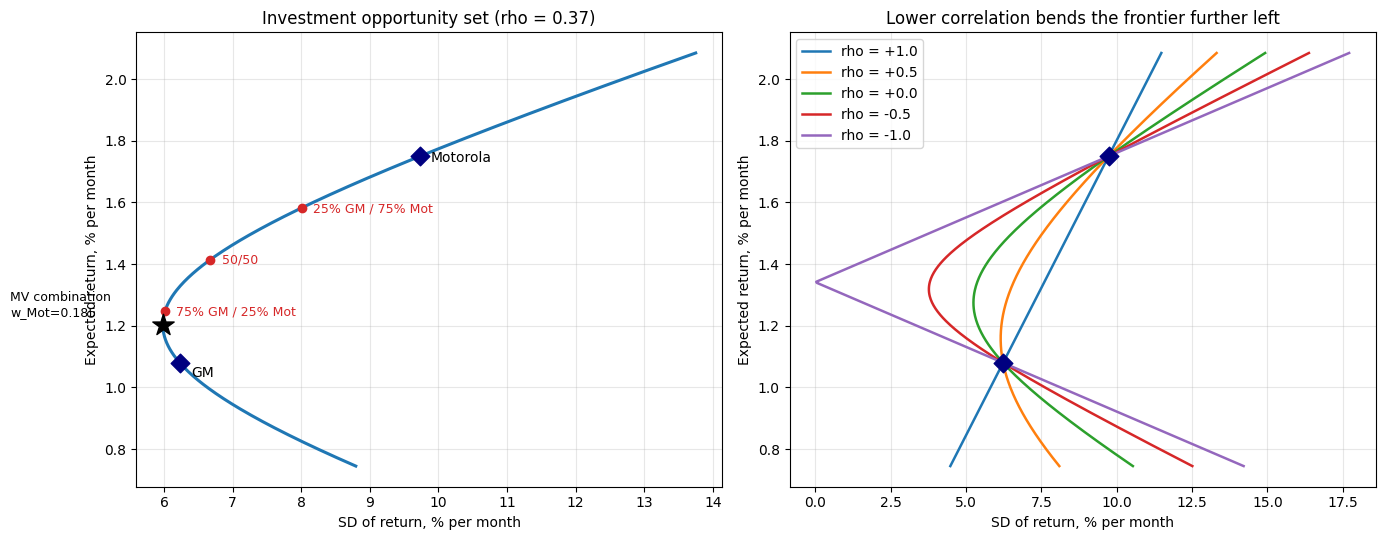

Minimum-variance mix: w_Mot = 0.1849, SD = 5.9820% vs GM alone 6.2300%


In [6]:
# ============================================================
# 3.2 The opportunity set: bullet curve, and how it bends with rho
# ============================================================
grid = np.linspace(-0.5, 1.5, 400)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# (a) the actual rho = 0.37 case
mus, sds = zip(*[(two_asset(w, e_mot, e_gm, s_mot, s_gm, rho)[0],
                  two_asset(w, e_mot, e_gm, s_mot, s_gm, rho)[2]) for w in grid])
axes[0].plot(sds, mus, lw=2.2, color="tab:blue")
axes[0].scatter([s_mot, s_gm], [e_mot, e_gm], s=90, marker="D", color="navy", zorder=5)
axes[0].annotate("Motorola", (s_mot, e_mot), textcoords="offset points", xytext=(8, -4))
axes[0].annotate("GM", (s_gm, e_gm), textcoords="offset points", xytext=(8, -10))
for w, lab in [(0.25, "75% GM / 25% Mot"), (0.5, "50/50"), (0.75, "25% GM / 75% Mot")]:
    m, _, s = two_asset(w, e_mot, e_gm, s_mot, s_gm, rho)
    axes[0].scatter(s, m, color="tab:red", zorder=6)
    axes[0].annotate(lab, (s, m), textcoords="offset points", xytext=(8, -3), fontsize=9, color="tab:red")
# minimum-variance combination of the two
w_mv = (s_gm ** 2 - rho * s_mot * s_gm) / (s_mot ** 2 + s_gm ** 2 - 2 * rho * s_mot * s_gm)
m_mv, _, s_mv = two_asset(w_mv, e_mot, e_gm, s_mot, s_gm, rho)
axes[0].scatter(s_mv, m_mv, marker="*", s=260, color="black", zorder=7)
axes[0].annotate(f"MV combination\nw_Mot={w_mv:.3f}", (s_mv, m_mv), textcoords="offset points",
                 xytext=(-110, 6), fontsize=9)
axes[0].set(xlabel="SD of return, % per month", ylabel="Expected return, % per month",
            title=f"Investment opportunity set (rho = {rho})")

# (b) correlation and the diversification benefit
for r_ in [1.0, 0.5, 0.0, -0.5, -1.0]:
    mus2, sds2 = zip(*[(two_asset(w, e_mot, e_gm, s_mot, s_gm, r_)[0],
                        two_asset(w, e_mot, e_gm, s_mot, s_gm, r_)[2]) for w in grid])
    axes[1].plot(sds2, mus2, lw=1.8, label=f"rho = {r_:+.1f}")
axes[1].scatter([s_mot, s_gm], [e_mot, e_gm], s=90, marker="D", color="navy", zorder=5)
axes[1].set(xlabel="SD of return, % per month", ylabel="Expected return, % per month",
            title="Lower correlation bends the frontier further left")
axes[1].legend()
plt.tight_layout(); plt.show()

print(f"Minimum-variance mix: w_Mot = {w_mv:.4f}, SD = {s_mv:.4f}% vs GM alone {s_gm:.4f}%")

**Reading the chart.** At $\rho=1$ the "curve" is a straight line — no diversification at all,
$\sigma_p=w_A\sigma_A+w_B\sigma_B$. As $\rho$ falls the curve bows to the left, and at $\rho=-1$ a
zero-variance portfolio exists. Real assets sit in between, which is why the opportunity set is a
bullet.

## 4. The $N$-asset case in matrix form

In [7]:
# ============================================================
# 4.1 Three-stock example (returns and V in % pa units)
# ============================================================
names3 = ["A", "B", "C"]
r3 = np.array([6.25, 7.50, 3.50])
V3 = np.array([[ 40.69,  37.38, -27.38],
               [ 37.38,  63.27, -17.25],
               [-27.38, -17.25,  20.75]])

w3 = np.repeat(1 / 3, 3)
mu3, sd3 = port_moments(w3, r3, V3)

print("Correlation matrix implied by V:")
sd_i = np.sqrt(np.diag(V3))
display(pd.DataFrame(V3 / np.outer(sd_i, sd_i), index=names3, columns=names3).round(4))

print(f"E[r_p] = w'r    = {mu3:.4f}% pa")
print(f"Var_p  = w'Vw   = {sd3**2:.4f}")
print(f"SD_p   = sqrt   = {sd3:.4f}% pa")
print(f"\nWeighted-average SD of the three stocks = {w3 @ sd_i:.4f}% pa")
print("The portfolio SD is far below it because C is negatively correlated with A and B.")

Correlation matrix implied by V:


,A,B,C
A,1.000000,0.736700,-0.942300
B,0.736700,1.000000,-0.476100
C,-0.942300,-0.476100,1.000000


E[r_p] = w'r    = 5.7500% pa
Var_p  = w'Vw   = 12.2456
SD_p   = sqrt   = 3.4994% pa

Weighted-average SD of the three stocks = 6.2961% pa
The portfolio SD is far below it because C is negatively correlated with A and B.


**Answer.** $E[r_p]=5.75\%$ pa, $\sigma_p^2=12.25$, $\sigma_p=3.50\%$ pa — matching the lecture.
Note the portfolio is *less* risky than every individual stock, which only happens with negative
covariances.

## 5. The power of diversification

For an equally weighted portfolio ($w_i=1/N$), splitting the double sum into variance and
covariance terms:

$$\sigma_p^2=\frac1N\overline{\sigma^2}+\frac{N-1}{N}\overline{\sigma_{i,j}}
\qquad\text{where}\qquad
\overline{\sigma^2}=\frac1N\sum_i\sigma_i^2,\quad
\overline{\sigma_{i,j}}=\frac1{N(N-1)}\sum_i\sum_{j\ne i}\sigma_{i,j}$$

As $N\to\infty$ the first term vanishes and $\sigma_p^2\to\overline{\sigma_{i,j}}$. **Firm-specific
risk is diversifiable; covariance (market) risk is not.** That non-diversifiable floor is why
investors demand compensation for systematic risk only — the bridge to Topics 5 and 6.

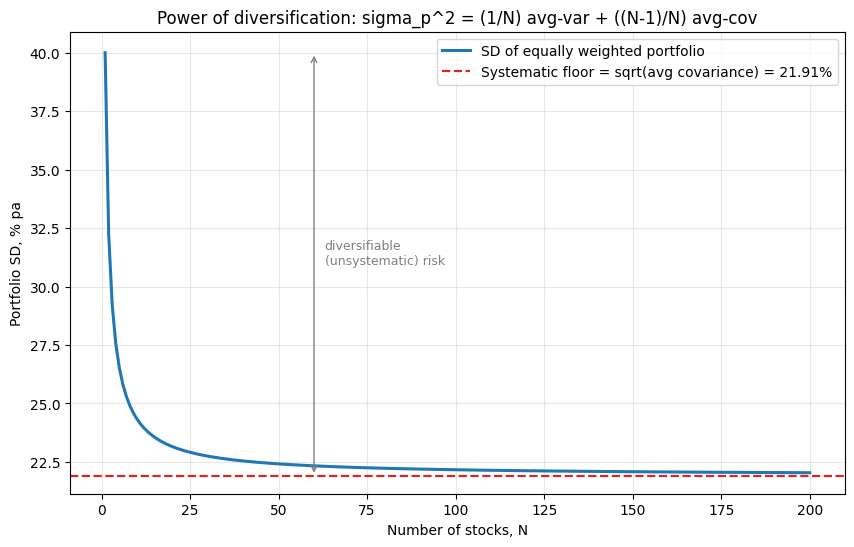

,SD_p,% of single-stock risk,% of risk that is systematic
N,,,
1,0.400000,100.000000,54.772300
2,0.322500,80.622600,67.936600
5,0.265300,66.332500,82.572300
10,0.243300,60.827600,90.045000
20,0.231500,57.879200,94.632000
30,0.227400,56.862400,96.324200
50,0.224100,56.035700,97.745300
100,0.221600,55.407600,98.853400
200,0.220400,55.090800,99.421700


In [8]:
# ============================================================
# 5.1 Portfolio risk as N grows
# ============================================================
def sigma_p_equal_weight(N, avg_var, avg_cov):
    # sigma_p^2 = (1/N) avg_var + ((N-1)/N) avg_cov
    return np.sqrt(avg_var / N + (N - 1) / N * avg_cov)

avg_sd, avg_rho = 0.40, 0.30                 # typical single-stock SD 40% pa, average correlation 0.30
avg_var = avg_sd ** 2
avg_cov = avg_rho * avg_var

Ns = np.arange(1, 201)
sds = np.array([sigma_p_equal_weight(N, avg_var, avg_cov) for N in Ns])
floor = np.sqrt(avg_cov)

fig, ax = plt.subplots()
ax.plot(Ns, sds * 100, lw=2.2, color="tab:blue", label="SD of equally weighted portfolio")
ax.axhline(floor * 100, color="tab:red", ls="--", lw=1.6,
           label=f"Systematic floor = sqrt(avg covariance) = {floor:.2%}")
ax.annotate("", xy=(60, floor * 100), xytext=(60, sds[0] * 100),
            arrowprops=dict(arrowstyle="<->", color="grey"))
ax.text(63, (floor * 100 + sds[0] * 100) / 2, "diversifiable\n(unsystematic) risk", fontsize=9, color="grey")
ax.set(xlabel="Number of stocks, N", ylabel="Portfolio SD, % pa",
       title="Power of diversification: sigma_p^2 = (1/N) avg-var + ((N-1)/N) avg-cov")
ax.legend(); plt.show()

tbl = pd.DataFrame({"N": [1, 2, 5, 10, 20, 30, 50, 100, 200]})
tbl["SD_p"] = [sigma_p_equal_weight(N, avg_var, avg_cov) for N in tbl.N]
tbl["% of single-stock risk"] = tbl.SD_p / sds[0] * 100
tbl["% of risk that is systematic"] = floor / tbl.SD_p * 100
display(tbl.set_index("N").round(4))

With an average correlation of 0.30, roughly **half** of a single stock's risk is gone by $N=10$ and
by $N=30$ the portfolio is within a few percent of the systematic floor. Adding the 31st stock buys
almost nothing — the classic result behind "20–30 stocks is a well-diversified portfolio". Section
IV.4 repeats this experiment on real SET100 data.

## 6. The efficient frontier of risky assets

The efficient portfolio is the one that **minimises $\sigma$ for a given $E[r]$** (equivalently,
maximises $E[r]$ for a given $\sigma$):

$$\max_{\mathbf w}\;E[r_P]=\mathbf w^\top\mathbf r
\quad\text{s.t.}\quad \mathbf w^\top V\mathbf w=\sigma_P^2,\;\; \mathbf w^\top\mathbf 1=1,
\;\;(w_i\ge0\ \text{if no short sales})$$

The minimum-variance boundary is the full hyperbola; the **efficient frontier** is only its upper
branch, above the global minimum-variance (GMV) portfolio. Banning short sales shrinks the
attainable set, so the no-short frontier lies *inside* (below and to the right of) the
short-sale-allowed frontier.

We solve the exercise from the Topic 4 slides:

$$\mathbf r=\begin{pmatrix}0.20\\0.30\\0.40\end{pmatrix},\qquad
V=\begin{pmatrix}0.0625&0.0700&0.1050\\0.0700&0.1225&0.0840\\0.1050&0.0840&0.3600\end{pmatrix}$$

In [9]:
# ============================================================
# 6.1 Frontier scalars for the Topic 4 exercise data
# ============================================================
ex_names = ["Security 1", "Security 2", "Security 3"]
ex_r = np.array([0.20, 0.30, 0.40])
ex_V = np.array([[0.0625, 0.0700, 0.1050],
                 [0.0700, 0.1225, 0.0840],
                 [0.1050, 0.0840, 0.3600]])

assert np.allclose(ex_V, ex_V.T) and np.all(np.linalg.eigvals(ex_V) > 0), "V must be symmetric PD"

fs = frontier_scalars(ex_r, ex_V)
print(f"A = 1'V^-1 1 = {fs['A']:.6f}")
print(f"B = 1'V^-1 r = {fs['B']:.6f}")
print(f"C = r'V^-1 r = {fs['C']:.6f}")
print(f"D = AC - B^2 = {fs['D']:.6f}")
display(pd.DataFrame({"g": fs["g"], "h": fs["h"]}, index=ex_names))

gmv = gmv_portfolio(fs)
print(f"\nGMV portfolio: E[r] = {gmv['mu']:.4%},  SD = {gmv['sd']:.4%}")
display(pd.DataFrame({"w_GMV": gmv["w"]}, index=ex_names))

A = 1'V^-1 1 = 20.092999
B = 1'V^-1 r = 2.398002
C = r'V^-1 r = 0.865031
D = AC - B^2 = 11.630644


,g,h
Security 1,2.477789,-7.660415
Security 2,-0.955577,5.320829
Security 3,-0.522211,2.339585



GMV portfolio: E[r] = 11.9345%,  SD = 22.3089%


,w_GMV
Security 1,1.563555
Security 2,-0.320562
Security 3,-0.242993


,Security 1,Security 2,Security 3,SD_p
E[r]=25% | short OK,0.562685,0.374630,0.062685,0.281531
E[r]=25% | long only,0.562685,0.374630,0.062685,0.281531
E[r]=30% | short OK,0.179664,0.640671,0.179664,0.325808
E[r]=30% | long only,0.179664,0.640671,0.179664,0.325808
E[r]=35% | short OK,-0.203356,0.906713,0.296644,0.376403
E[r]=35% | long only,0.000000,0.500000,0.500000,0.403268


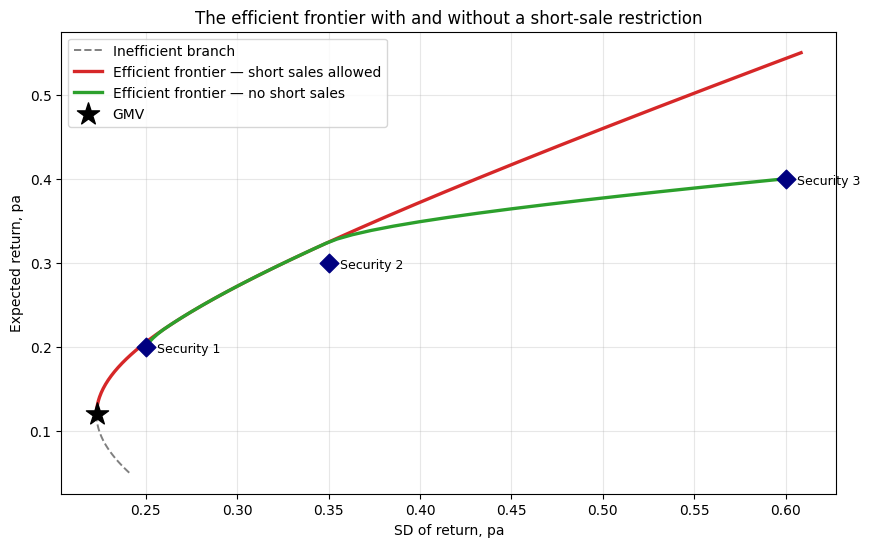

In [10]:
# ============================================================
# 6.2 Efficient portfolios for target returns, and the effect of banning short sales
# ============================================================
targets = [0.25, 0.30, 0.35]

rows = {}
for t in targets:
    w_free = weights_for_return(fs, t)                    # short sales allowed (closed form)
    w_long = min_var_long_only(ex_r, ex_V, target=t)      # no short sales (SLSQP)
    rows[f"E[r]={t:.0%} | short OK"] = list(w_free) + [float(np.sqrt(w_free @ ex_V @ w_free))]
    rows[f"E[r]={t:.0%} | long only"] = list(w_long) + [float(np.sqrt(w_long @ ex_V @ w_long))]

display(pd.DataFrame(rows, index=ex_names + ["SD_p"]).T.round(6))

# Both frontiers on one chart
mu_grid = np.linspace(0.05, 0.55, 300)
sd_grid = frontier_sigma(fs, mu_grid)
eff_mask = mu_grid >= gmv["mu"]
lo_df, _ = frontier_long_only(ex_r, ex_V, n_points=40)

fig, ax = plt.subplots()
ax.plot(sd_grid[~eff_mask], mu_grid[~eff_mask], color="grey", ls="--", lw=1.4, label="Inefficient branch")
ax.plot(sd_grid[eff_mask], mu_grid[eff_mask], color="tab:red", lw=2.4, label="Efficient frontier — short sales allowed")
ax.plot(lo_df.sd, lo_df.mu, color="tab:green", lw=2.4, label="Efficient frontier — no short sales")
ax.scatter(np.sqrt(np.diag(ex_V)), ex_r, s=90, marker="D", color="navy", zorder=6)
for nm, s, m in zip(ex_names, np.sqrt(np.diag(ex_V)), ex_r):
    ax.annotate(nm, (s, m), textcoords="offset points", xytext=(8, -4), fontsize=9)
ax.scatter(gmv["sd"], gmv["mu"], marker="*", s=280, color="black", zorder=7, label="GMV")
ax.set(xlabel="SD of return, pa", ylabel="Expected return, pa",
       title="The efficient frontier with and without a short-sale restriction")
ax.legend(); plt.show()

**Answer.** With short sales allowed the target returns of 25%, 30% and 35% are met with
$\sigma_p = 28.15\%$, $32.58\%$ and $37.64\%$; at the 35% target the optimiser is **short Security 1**
by about 20% of capital. Ban short sales and the same targets cost more risk (the green curve sits
inside the red one), and the 35% target can only be reached by concentrating in Securities 2 and 3 —
exactly the lecture's "short sale allowed vs not allowed" picture.

## 7. Adding the risk-free asset: the CAL and capital allocation

With weight $y$ in the risky portfolio $P$ and $1-y$ in the risk-free asset, the **complete
portfolio** $C$ has

$$E[r_C]=r_F+y\big(E[r_P]-r_F\big),\qquad \sigma_C=y\,\sigma_P
\;\;\Longrightarrow\;\;
E[r_C]=r_F+\underbrace{\frac{E[r_P]-r_F}{\sigma_P}}_{\text{Sharpe ratio}}\sigma_C$$

This straight line is the **capital allocation line (CAL)**. Its slope, the reward-to-variability
ratio, does not depend on $y$: leverage does not improve the risk-return trade-off, it only moves you
along the line. The **optimal risky portfolio** is therefore the one with the steepest CAL — found by
maximising $SR_P$ — and it is chosen **without any knowledge of the investor's risk aversion**.

Only the second decision needs preferences. Maximising $E[U(r_C)] = r_F + y(E[r_P]-r_F) - \tfrac12Ay^2\sigma_P^2$
over $y$ gives

$$y^* = \frac{E[r_P]-r_F}{A\,\sigma_P^2}$$

In [11]:
# ============================================================
# 7.1 The CAL — lecture example: rF = 7%, E[r_P] = 15%, SD_P = 22%
# ============================================================
rf_ex, mu_P, sd_P = 0.07, 0.15, 0.22
sharpe_P = (mu_P - rf_ex) / sd_P
print(f"Sharpe ratio (slope of the CAL) = ({mu_P:.0%} - {rf_ex:.0%}) / {sd_P:.0%} = {sharpe_P:.4f}")

alloc = []
for y in [0.0, 0.6, 1.0, 1.4]:
    mc = rf_ex + y * (mu_P - rf_ex)
    sc = y * sd_P
    alloc.append({"y (in P)": y, "1-y (in rF)": 1 - y, "E[r_C]": mc, "SD_C": sc,
                  "slope (E[r_C]-rF)/SD_C": np.nan if sc == 0 else (mc - rf_ex) / sc,
                  "position": "all risk-free" if y == 0 else ("lending" if y < 1 else
                              ("fully invested" if y == 1 else "borrowing / levered"))})
display(pd.DataFrame(alloc).set_index("y (in P)").round(4))

for A in [2, 3, 4, 5]:
    y_star = optimal_y(mu_P, sd_P, rf_ex, A)
    mc, sc = rf_ex + y_star * (mu_P - rf_ex), y_star * sd_P
    print(f"A = {A}: y* = {y_star:.4f} -> E[r_C] = {mc:.4%}, SD_C = {sc:.4%}, "
          f"U = {mv_utility(mc, sc, A):.4%}")

Sharpe ratio (slope of the CAL) = (15% - 7%) / 22% = 0.3636


,1-y (in rF),E[r_C],SD_C,slope (E[r_C]-rF)/SD_C,position
y (in P),,,,,
0.000000,1.000000,0.070000,0.000000,NaN,all risk-free
0.600000,0.400000,0.118000,0.132000,0.363600,lending
1.000000,0.000000,0.150000,0.220000,0.363600,fully invested
1.400000,-0.400000,0.182000,0.308000,0.363600,borrowing / levered


A = 2: y* = 0.8264 -> E[r_C] = 13.6116%, SD_C = 18.1818%, U = 10.3058%
A = 3: y* = 0.5510 -> E[r_C] = 11.4077%, SD_C = 12.1212%, U = 9.2039%
A = 4: y* = 0.4132 -> E[r_C] = 10.3058%, SD_C = 9.0909%, U = 8.6529%
A = 5: y* = 0.3306 -> E[r_C] = 9.6446%, SD_C = 7.2727%, U = 8.3223%


,w_tangency
Security 1,-4.045312
Security 2,3.575288
Security 3,1.470024


E[r_T] = 85.1534%   SD_T = 98.7892%   Sharpe = 0.780990


,Risky assets only (Topic 4 Q2),With risk-free asset (Q3)
weight in rF,0.000000,0.714854
E[r_p],0.300000,0.300000
SD_p,0.325808,0.281694
Sharpe vs rF=8%,0.675245,0.780990



Risk saved at the same 30% expected return: 4.4114% of SD (13.54% lower).


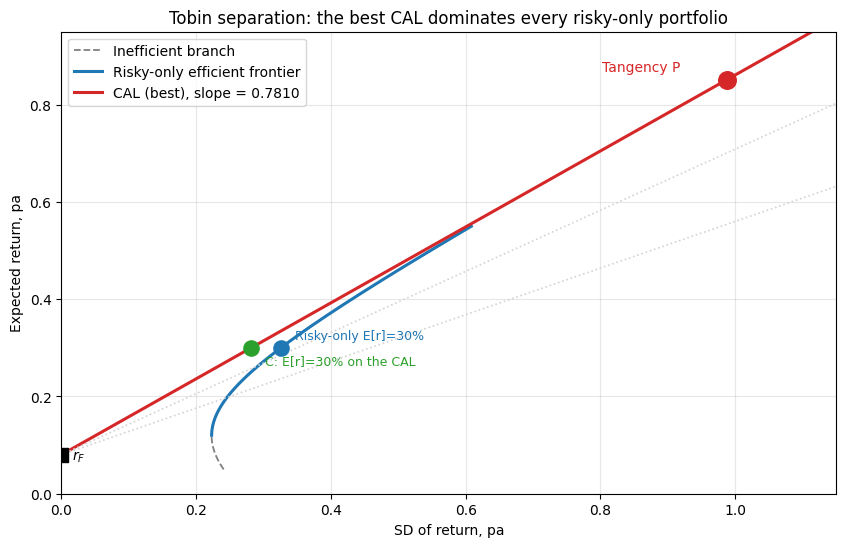

In [12]:
# ============================================================
# 7.2 The tangency portfolio for the 3-security exercise, rF = 8%
# ============================================================
rf3 = 0.08
tan = tangency_portfolio(fs, rf3)

display(pd.DataFrame({"w_tangency": tan["w"]}, index=ex_names).round(6))
print(f"E[r_T] = {tan['mu']:.4%}   SD_T = {tan['sd']:.4%}   Sharpe = {tan['sharpe']:.6f}")

# Reaching E[r] = 30% with, and without, the risk-free asset
y30 = (0.30 - rf3) / (tan["mu"] - rf3)
sd30_cal = y30 * tan["sd"]
w30_risky = weights_for_return(fs, 0.30)
sd30_risky = float(np.sqrt(w30_risky @ ex_V @ w30_risky))

cmp = pd.DataFrame({
    "Risky assets only (Topic 4 Q2)": {"weight in rF": 0.0, "E[r_p]": 0.30, "SD_p": sd30_risky,
                                       "Sharpe vs rF=8%": (0.30 - rf3) / sd30_risky},
    "With risk-free asset (Q3)":      {"weight in rF": 1 - y30, "E[r_p]": 0.30, "SD_p": sd30_cal,
                                       "Sharpe vs rF=8%": (0.30 - rf3) / sd30_cal},
})
display(cmp.round(6))
print(f"\nRisk saved at the same 30% expected return: "
      f"{sd30_risky - sd30_cal:.4%} of SD ({(sd30_risky - sd30_cal)/sd30_risky:.2%} lower).")

# Chart
fig, ax = plt.subplots()
ax.plot(sd_grid[~eff_mask], mu_grid[~eff_mask], color="grey", ls="--", lw=1.3, label="Inefficient branch")
ax.plot(sd_grid[eff_mask], mu_grid[eff_mask], color="tab:blue", lw=2.2, label="Risky-only efficient frontier")
sd_line = np.linspace(0, 1.15, 50)
ax.plot(sd_line, rf3 + tan["sharpe"] * sd_line, color="tab:red", lw=2.2,
        label=f"CAL (best), slope = {tan['sharpe']:.4f}")
for w_sub, lab, col in [(np.array([1, 0, 0]), "CAL through Security 1", "lightgrey"),
                        (np.array([0, 1, 0]), "CAL through Security 2", "lightgrey")]:
    m_, s_ = port_moments(w_sub, ex_r, ex_V)
    ax.plot(sd_line, rf3 + (m_ - rf3) / s_ * sd_line, color=col, lw=1.2, ls=":")
ax.scatter(0, rf3, marker="s", s=90, color="black", zorder=6); ax.annotate("$r_F$", (0, rf3), xytext=(8, -4), textcoords="offset points")
ax.scatter(tan["sd"], tan["mu"], s=160, color="tab:red", zorder=7); ax.annotate("Tangency P", (tan["sd"], tan["mu"]), xytext=(-90, 6), textcoords="offset points", color="tab:red")
ax.scatter(sd30_cal, 0.30, s=120, color="tab:green", zorder=7); ax.annotate("C: E[r]=30% on the CAL", (sd30_cal, 0.30), xytext=(10, -12), textcoords="offset points", color="tab:green", fontsize=9)
ax.scatter(sd30_risky, 0.30, s=120, color="tab:blue", zorder=7); ax.annotate("Risky-only E[r]=30%", (sd30_risky, 0.30), xytext=(10, 6), textcoords="offset points", color="tab:blue", fontsize=9)
ax.set(xlim=(0, 1.15), ylim=(0, 0.95), xlabel="SD of return, pa", ylabel="Expected return, pa",
       title="Tobin separation: the best CAL dominates every risky-only portfolio")
ax.legend(loc="upper left"); plt.show()

**Answer.** The tangency portfolio is $w_T=(-4.0453,\;3.5753,\;1.4700)$ with $E[r_T]=85.15\%$,
$\sigma_T=98.79\%$ and $SR_T=0.7810$. To reach $E[r_p]=30\%$ you hold $y=28.51\%$ in $T$ and lend
$71.49\%$ at 8%, giving $\sigma_p=28.17\%$ — versus $32.58\%$ for the risky-only portfolio at the same
expected return. Same return, **less risk**: that is the value of the risk-free asset.

## 8. The separation property (Tobin, 1958)

Because the tangency portfolio maximises a ratio that contains no preference parameter, portfolio
construction splits into two independent tasks:

1. **Security selection** — find the optimal risky portfolio $P$. Needs *market information only*, so
   it can be delegated to a fund manager.
2. **Capital allocation** — split wealth between $P$ and $r_F$ via $y^*=(E[r_P]-r_F)/(A\sigma_P^2)$.
   Needs the investor's risk aversion.

Add homogeneous expectations and $P$ becomes the **market portfolio** $M$, the CAL becomes the
**Capital Market Line**, and we are in Topic 6. Separation breaks down when borrowing and lending
rates differ (two different tangency portfolios) — the motivation for Black's zero-beta model.

---
# Part II — Topic 5: The Single Index Model

## 1. Why bother? The Markowitz input problem

Markowitz (1952) needs the **full** variance–covariance matrix. For $N$ securities that is

$$\underbrace{N}_{E[r_i]}+\underbrace{N}_{\sigma_i^2}+\underbrace{\frac{N^2-N}{2}}_{\sigma_{i,j}}
=2N+\frac{N^2-N}{2}\;\text{estimates}$$

At $N=100$ that is 5,150 numbers and at $N=500$ it is 125,750. Three problems follow: it is slow,
the estimates are mutually inconsistent (so $V$ may not even be positive semi-definite), and no
analyst can specialise — every analyst must know every security.

Sharpe (1963) assumes returns are driven by a **single common factor**:

$$r_i=\alpha_i+\beta_iF+\varepsilon_i,\qquad
E[\varepsilon_i]=0,\;\;\mathrm{Cov}[\varepsilon_i,F]=0,\;\;\mathrm{Cov}[\varepsilon_i,\varepsilon_j]=0$$

Equivalently $r_i = E[r_i]+\beta_i(F-E[F])+\varepsilon_i$: realised return = expectation +
macro surprise + firm-specific surprise. Using a market index as the factor gives the **market model**

$$r_i=\alpha_i+\beta_i r_M+\varepsilon_i$$

**Risk decomposition.** Because $\mathrm{Cov}[\varepsilon_i,r_M]=0$,

$$\underbrace{\sigma_i^2}_{\text{total}}
=\underbrace{\beta_i^2\sigma_M^2}_{\text{systematic}}+\underbrace{\sigma_{\varepsilon i}^2}_{\text{firm-specific}}$$

**Covariance structure.** All co-movement runs through the factor:

$$\sigma_{i,j}=\beta_i\beta_j\sigma_M^2,\qquad
\beta_i=\frac{\mathrm{Cov}[r_i,r_M]}{\mathrm{Var}[r_M]},\qquad
\rho_{i,j}=\rho_{i,M}\times\rho_{j,M}$$

So the whole matrix is rebuilt from $N$ betas plus $\sigma_M^2$:

$$\boxed{\,V_{SIM}=\sigma_M^2\,\boldsymbol\beta\boldsymbol\beta^\top+\mathrm{diag}(\sigma_{\varepsilon i}^2)\,}$$

which needs only $3N+2$ estimates (302 at $N=100$) and is **positive semi-definite by construction**.

In [13]:
# ============================================================
# 1.1 Input count: Markowitz vs the SIM
# ============================================================
def n_inputs(N):
    return pd.Series({"Markowitz: E[r]": N, "Markowitz: Var": N,
                      "Markowitz: Cov": (N ** 2 - N) // 2,
                      "Markowitz TOTAL": 2 * N + (N ** 2 - N) // 2,
                      "SIM: alpha": N, "SIM: beta": N, "SIM: Var(eps)": N,
                      "SIM: E[rM], Var[rM]": 2,
                      "SIM TOTAL": 3 * N + 2})

counts = pd.DataFrame({f"N = {N}": n_inputs(N) for N in [10, 50, 100, 500]})
counts.loc["Reduction factor"] = counts.loc["Markowitz TOTAL"] / counts.loc["SIM TOTAL"]
display(counts.astype(float).round(1))

,N = 10,N = 50,N = 100,N = 500
Markowitz: E[r],10.000000,50.000000,100.000000,500.000000
Markowitz: Var,10.000000,50.000000,100.000000,500.000000
Markowitz: Cov,45.000000,"1,225.000000","4,950.000000","124,750.000000"
Markowitz TOTAL,65.000000,"1,325.000000","5,150.000000","125,750.000000"
SIM: alpha,10.000000,50.000000,100.000000,500.000000
SIM: beta,10.000000,50.000000,100.000000,500.000000
SIM: Var(eps),10.000000,50.000000,100.000000,500.000000
"SIM: E[rM], Var[rM]",2.000000,2.000000,2.000000,2.000000
SIM TOTAL,32.000000,152.000000,302.000000,"1,502.000000"
Reduction factor,2.000000,8.700000,17.100000,83.700000


In [14]:
# ============================================================
# 1.2 Building V from betas, and the correlation identity
# ============================================================
def sim_covariance(betas, sig_eps, sigma_M):
    # V = sigma_M^2 * beta beta' + diag(sigma_eps^2)
    betas, sig_eps = np.asarray(betas, float), np.asarray(sig_eps, float)
    return (sigma_M ** 2) * np.outer(betas, betas) + np.diag(sig_eps ** 2)

demo_b   = np.array([0.80, 1.20, 1.50])
demo_se  = np.array([0.25, 0.30, 0.45])
sigma_M_ = 0.18

V_demo = sim_covariance(demo_b, demo_se, sigma_M_)
sd_demo = np.sqrt(np.diag(V_demo))
corr_demo = V_demo / np.outer(sd_demo, sd_demo)

display(pd.DataFrame(V_demo, index=["X", "Y", "Z"], columns=["X", "Y", "Z"]).round(6))

decomp = pd.DataFrame({
    "beta": demo_b,
    "systematic  beta^2*sigM^2": demo_b ** 2 * sigma_M_ ** 2,
    "firm-specific  sig_eps^2": demo_se ** 2,
    "total variance": np.diag(V_demo),
}, index=["X", "Y", "Z"])
decomp["R^2 = systematic share"] = decomp["systematic  beta^2*sigM^2"] / decomp["total variance"]
decomp["corr with market"] = np.sqrt(decomp["R^2 = systematic share"])
display(decomp.round(6))

# rho_ij = rho_iM * rho_jM
rho_iM = decomp["corr with market"].values
print("Check  rho_ij = rho_iM * rho_jM :",
      np.allclose(corr_demo, np.outer(rho_iM, rho_iM) + np.diag(1 - rho_iM ** 2)))
print("Smallest eigenvalue of V_SIM =", f"{np.linalg.eigvalsh(V_demo).min():.6f} (>0 => always usable)")

,X,Y,Z
X,0.083236,0.031104,0.038880
Y,0.031104,0.136656,0.058320
Z,0.038880,0.058320,0.275400


,beta,systematic beta^2*sigM^2,firm-specific sig_eps^2,total variance,R^2 = systematic share,corr with market
X,0.800000,0.020736,0.062500,0.083236,0.249123,0.499122
Y,1.200000,0.046656,0.090000,0.136656,0.341412,0.584305
Z,1.500000,0.072900,0.202500,0.275400,0.264706,0.514496


Check  rho_ij = rho_iM * rho_jM : True
Smallest eigenvalue of V_SIM = 0.068140 (>0 => always usable)


## 2. Estimating the market model: the Security Characteristic Line

The SCL is the time-series regression of **excess** returns:

$$\big(r_{i,t}-r_{F,t}\big)=\alpha_i+\beta_i\big(r_{M,t}-r_{F,t}\big)+\varepsilon_{i,t}$$

Taking expectations, $E[r_i]-r_F=\alpha_i+\beta_i(E[r_M]-r_F)$. The intercept $\alpha_i$ is
**Jensen's alpha** — the part of the excess return that is *not* compensation for systematic risk.
$\alpha_i>0$ means the security earns more than its risk warrants; competition should drive it to
zero, and finding non-zero alphas before anyone else is the analyst's job.

Excess returns matter: regressing **raw** returns, $r_{i,t}=a_i+b_ir_{M,t}+u_{i,t}$, gives the same
slope when $r_F$ is constant, but the intercept then estimates $\alpha_i+(1-\beta_i)r_F$, which is
*not* the abnormal return.

In [15]:
# ============================================================
# 2.1 SCL estimator (OLS with standard errors) used everywhere below
# ============================================================
def run_scl(r_asset, r_market, rf_per_period, periods_per_year=12):
    # (r_i - rF) = alpha + beta (r_M - rF) + eps   ->  alpha, beta, t-stats, sigma_eps, R^2
    df = pd.concat([r_asset, r_market], axis=1).dropna()
    y = (df.iloc[:, 0] - rf_per_period).values
    x = (df.iloc[:, 1] - rf_per_period).values
    n = len(y)
    if n < 3:
        return None
    X = np.column_stack([np.ones(n), x])
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ coef
    dof = n - 2
    s2 = float(resid @ resid / dof)
    se = np.sqrt(np.diag(s2 * np.linalg.inv(X.T @ X)))
    ss_tot = float(((y - y.mean()) ** 2).sum())
    r2 = 1.0 - float(resid @ resid) / ss_tot if ss_tot > 0 else np.nan
    return dict(n=n, alpha=coef[0], beta=coef[1], se_alpha=se[0], se_beta=se[1],
                t_alpha=coef[0] / se[0], t_beta=coef[1] / se[1],
                p_alpha=2 * (1 - stats.t.cdf(abs(coef[0] / se[0]), dof)),
                sigma_eps=np.sqrt(s2), r2=r2,
                alpha_ann=coef[0] * periods_per_year,
                sigma_eps_ann=np.sqrt(s2 * periods_per_year))

# Verification against the lecture's Amazon SCL (5 years of monthly data to Jun-2018):
# alpha = 0.0192 (t = 2.0645), beta = 1.5326 (t = 4.8648), R^2 = 0.2863, sigma_eps = 0.0686, n = 60
amzn = dict(alpha=0.0192, beta=1.5326, sigma_eps=0.0686, r2=0.2863, n=60)

# Back out the full decomposition from the reported figures alone (no extra assumption):
#   R^2 = beta^2 sigM^2 / sigma_i^2   and   sigma_i^2 = beta^2 sigM^2 + sigma_eps^2
#   =>  sigma_i^2 = sigma_eps^2 / (1 - R^2),  then sigM = sqrt(R^2 * sigma_i^2) / beta
tot_var = amzn["sigma_eps"] ** 2 / (1 - amzn["r2"])
systematic = amzn["r2"] * tot_var
sig_M_implied = np.sqrt(systematic) / amzn["beta"]

print("Lecture SCL for Amazon (60 monthly observations to Jun-2018):")
print(f"  alpha = {amzn['alpha']:.4f} per month = {amzn['alpha']*12:.2%} pa   (t = 2.06, significant at 5%)")
print(f"  beta  = {amzn['beta']:.4f}                                 (t = 4.86)")
print("\n  Risk decomposition  sigma_i^2 = beta^2 sigM^2 + sigma_eps^2 :")
print(f"    total          sigma_i^2   = {tot_var:.6f}  -> sigma_i = {np.sqrt(tot_var):.4%} per month")
print(f"    systematic     beta^2 sigM^2 = {systematic:.6f}  ({amzn['r2']:.2%} of total = R^2)")
print(f"    firm-specific  sigma_eps^2  = {amzn['sigma_eps']**2:.6f}  ({1-amzn['r2']:.2%} of total)")
print(f"\n  Implied market SD = {sig_M_implied:.4%} per month = {sig_M_implied*np.sqrt(12):.4%} pa")
print("  Roughly 71% of Amazon's variance is diversifiable — even a high-beta stock is mostly noise.")

Lecture SCL for Amazon (60 monthly observations to Jun-2018):
  alpha = 0.0192 per month = 23.04% pa   (t = 2.06, significant at 5%)
  beta  = 1.5326                                 (t = 4.86)

  Risk decomposition  sigma_i^2 = beta^2 sigM^2 + sigma_eps^2 :
    total          sigma_i^2   = 0.006594  -> sigma_i = 8.1202% per month
    systematic     beta^2 sigM^2 = 0.001888  (28.63% of total = R^2)
    firm-specific  sigma_eps^2  = 0.004706  (71.37% of total)

  Implied market SD = 2.8350% per month = 9.8206% pa
  Roughly 71% of Amazon's variance is diversifiable — even a high-beta stock is mostly noise.


## 3. The SIM and diversification

Treat a portfolio as an asset. With $R=r-r_F$,

$$R_P=\alpha_P+\beta_PR_M+\varepsilon_P,\qquad
\alpha_P=\sum_iw_i\alpha_i,\quad \beta_P=\sum_iw_i\beta_i,\quad \varepsilon_P=\sum_iw_i\varepsilon_i$$

$$\sigma_P^2=\beta_P^2\sigma_M^2+\sigma_{\varepsilon P}^2,
\qquad \sigma_{\varepsilon P}^2=\sum_iw_i^2\sigma_{\varepsilon i}^2
\;\xrightarrow{w_i=1/N}\;\frac1N\overline{\sigma_{\varepsilon}^2}\;\to\;0$$

Diversification kills the residual variance but leaves $\beta_P$ untouched — the number of stocks has
**no bearing** on systematic risk.

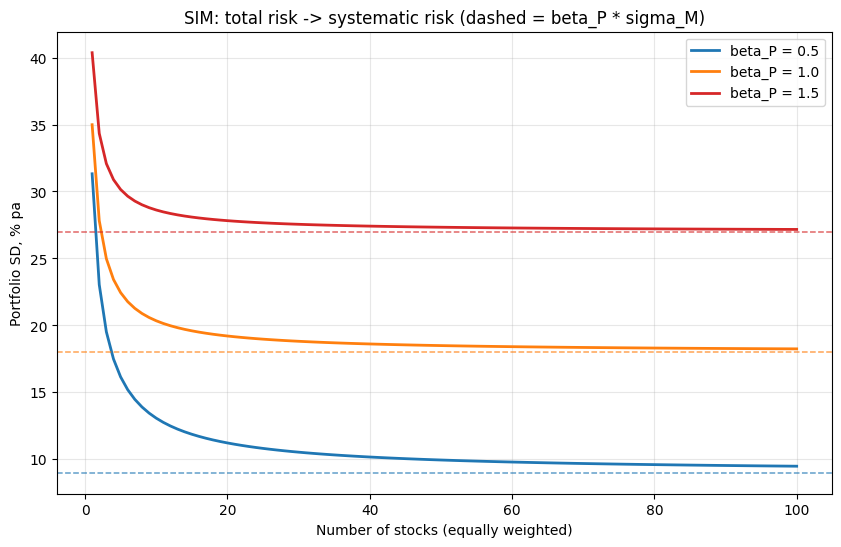

,sigma_eps_P,total SD (beta=1),systematic share
N,,,
1,0.300000,0.349857,0.264706
5,0.134164,0.224499,0.642857
10,0.094868,0.203470,0.782609
25,0.060000,0.189737,0.900000
50,0.042426,0.184932,0.947368
100,0.030000,0.182483,0.972973
500,0.013416,0.180499,0.994475


In [16]:
# ============================================================
# 3.1 Residual risk vanishes, beta does not
# ============================================================
rng = np.random.default_rng(7)
sig_M_sim = 0.18
avg_sig_eps = 0.30

fig, ax = plt.subplots()
for beta_target, col in [(0.5, "tab:blue"), (1.0, "tab:orange"), (1.5, "tab:red")]:
    Ns = np.arange(1, 101)
    tot = [np.sqrt(beta_target ** 2 * sig_M_sim ** 2 + avg_sig_eps ** 2 / N) for N in Ns]
    ax.plot(Ns, np.array(tot) * 100, color=col, lw=2, label=f"beta_P = {beta_target}")
    ax.axhline(beta_target * sig_M_sim * 100, color=col, ls="--", lw=1.1, alpha=0.7)
ax.set(xlabel="Number of stocks (equally weighted)", ylabel="Portfolio SD, % pa",
       title="SIM: total risk -> systematic risk (dashed = beta_P * sigma_M)")
ax.legend(); plt.show()

rows = []
for N in [1, 5, 10, 25, 50, 100, 500]:
    se_p = np.sqrt(avg_sig_eps ** 2 / N)
    tot = np.sqrt(1.0 ** 2 * sig_M_sim ** 2 + se_p ** 2)
    rows.append({"N": N, "sigma_eps_P": se_p, "total SD (beta=1)": tot,
                 "systematic share": (sig_M_sim ** 2) / tot ** 2})
display(pd.DataFrame(rows).set_index("N").round(6))

## 4. Portfolio construction under the SIM, and Treynor–Black

Substituting the SIM into the Sharpe-ratio program,

$$\max_{\mathbf w}\;SR_P=\frac{E[R_P]}{\sigma_P}
\quad\text{s.t.}\quad
E[R_P]=\sum_iw_i\alpha_i+E[R_M]\sum_iw_i\beta_i,\quad
\sigma_P^2=\sigma_M^2\Big(\sum_iw_i\beta_i\Big)^2+\sum_iw_i^2\sigma_{\varepsilon i}^2,\quad
\sum_iw_i=1$$

The optimiser overweights positive-alpha names and underweights negative-alpha names, so
$\alpha_P>0$ — but the portfolio is then *not* fully diversified and carries residual risk
$\sigma_{\varepsilon P}^2$. The trade-off between the two is the **information ratio**
$\alpha_i/\sigma_{\varepsilon i}$.

**Treynor–Black.** Add the index itself as asset $N+1$ ($\alpha_M=0,\beta_M=1,\sigma_{\varepsilon M}^2=0$).
The optimal risky portfolio then splits into a **passive** position in $M$ and an **active**
portfolio $A$ whose internal weights are proportional to the information ratio per unit of residual
variance:

$$w_i^*=w_A^*\;\frac{\alpha_i/\sigma_{\varepsilon i}^2}{\sum_{j}\alpha_j/\sigma_{\varepsilon j}^2},
\qquad
w_A^{0}=\frac{\alpha_A/\sigma_{\varepsilon A}^2}{E[R_M]/\sigma_M^2},
\qquad
w_A^*=\frac{w_A^{0}}{1+(1-\beta_A)w_A^{0}}$$

and the payoff to active management is exactly the squared information ratio:

$$\boxed{\;SR_P^2=SR_M^2+\left(\frac{\alpha_A}{\sigma_{\varepsilon A}}\right)^2\;}$$

In [17]:
# ============================================================
# 4.1 Treynor-Black construction
# ============================================================
def treynor_black(alphas, betas, sig_eps, mu_excess_M, sigma_M):
    # Active-portfolio internal weights, its alpha/beta/residual risk, and the optimal mix with M.
    alphas, betas, sig_eps = map(lambda a: np.asarray(a, float), (alphas, betas, sig_eps))
    w_raw = alphas / sig_eps ** 2
    w_active = w_raw / w_raw.sum()

    alpha_A = float(w_active @ alphas)
    beta_A = float(w_active @ betas)
    sig_eps_A = float(np.sqrt((w_active ** 2) @ (sig_eps ** 2)))

    w0 = (alpha_A / sig_eps_A ** 2) / (mu_excess_M / sigma_M ** 2)
    w_A = w0 / (1 + (1 - beta_A) * w0)

    mu_P = w_A * (alpha_A + beta_A * mu_excess_M) + (1 - w_A) * mu_excess_M
    var_P = (w_A * beta_A + (1 - w_A)) ** 2 * sigma_M ** 2 + (w_A * sig_eps_A) ** 2
    sr_M = mu_excess_M / sigma_M
    return dict(w_active=w_active, alpha_A=alpha_A, beta_A=beta_A, sig_eps_A=sig_eps_A,
                info_ratio=alpha_A / sig_eps_A, w_A0=w0, w_A=w_A,
                mu_excess_P=mu_P, sd_P=np.sqrt(var_P), sharpe_P=mu_P / np.sqrt(var_P), sharpe_M=sr_M)

tb_demo = treynor_black(alphas=[0.05, -0.03, 0.02], betas=[1.1, 0.9, 1.3],
                        sig_eps=[0.25, 0.20, 0.35], mu_excess_M=0.06, sigma_M=0.18)

print("Active portfolio internal weights:", np.round(tb_demo["w_active"], 4))
print(f"alpha_A = {tb_demo['alpha_A']:.4%}, beta_A = {tb_demo['beta_A']:.4f}, "
      f"sigma_eps_A = {tb_demo['sig_eps_A']:.4%}")
print(f"Information ratio = {tb_demo['info_ratio']:.4f}")
print(f"w_A (weight of the active portfolio in P) = {tb_demo['w_A']:.4f}, "
      f"passive weight in M = {1 - tb_demo['w_A']:.4f}")
print(f"\nSharpe of M = {tb_demo['sharpe_M']:.4f}   Sharpe of P = {tb_demo['sharpe_P']:.4f}")
print(f"Check SR_P^2 = SR_M^2 + IR^2 :  {tb_demo['sharpe_P']**2:.6f}  vs  "
      f"{tb_demo['sharpe_M']**2 + tb_demo['info_ratio']**2:.6f}")

Active portfolio internal weights: [ 3.7512 -3.5167  0.7656]
alpha_A = 30.8373%, beta_A = 1.9565, sigma_eps_A = 120.2481%
Information ratio = 0.2564
w_A (weight of the active portfolio in P) = 0.1294, passive weight in M = 0.8706

Sharpe of M = 0.3333   Sharpe of P = 0.4206
Check SR_P^2 = SR_M^2 + IR^2 :  0.176876  vs  0.176876


The identity holds to numerical precision: **all** the value added by security analysis is captured
by the information ratio of the active portfolio.

### SIM vs Markowitz — which frontier is better?

In-sample the SIM frontier is *inferior* — it throws away information by forcing every covariance
through one factor. Out-of-sample there is no such guarantee: the SIM's estimates are far more
stable, and its covariance matrix is always well conditioned. Section IV.6 measures both effects on
real SET100 data.

---
# Part III — Topic 6: The Capital Asset Pricing Model

Topics 4–5 are **normative**: given the inputs, here is how you *should* invest. The CAPM is
**positive**: if everyone invests that way, here is the risk–return relation that *must* hold in
equilibrium.

## 1. Assumptions

**On investors:** (a) all are rational mean-variance optimisers (or returns are normal);
(b) a single, identical investment horizon; (c) homogeneous expectations — everyone uses the same
input list.

**On markets:** (a) all assets are divisible, publicly held and traded; (b) unlimited borrowing and
lending at $r_F$; (c) a perfect market — no taxes or transaction costs, free information, unrestricted
short sales, price-taking investors.

## 2. From the CAL to the CML

Homogeneous expectations $\Rightarrow$ everyone draws the *same* efficient frontier and holds the
*same* tangency portfolio. In equilibrium net borrowing is zero and every risky asset must be held,
so the tangency portfolio must be the **market portfolio** $M$ — every asset at its market-value
weight. The best CAL becomes the **Capital Market Line**:

$$E[r_P]=r_F+\left(\frac{E[r_M]-r_F}{\sigma_M}\right)\sigma_P$$

Its slope is the market price of risk, set by the *aggregate* risk aversion of all participants.
The CML prices **efficient portfolios only** — apply it to an inefficient asset and you overstate its
required return.

## 3. Deriving the SML

The variance of the market portfolio can be written as a sum of each asset's covariance contribution:

$$\sigma_M^2=\sum_i w_i\,\mathrm{Cov}[r_i,r_M]$$

so asset $i$'s marginal contribution to market risk is $w_i\sigma_{i,M}$, while its contribution to
the market risk premium is $w_i(E[r_i]-r_F)$. In equilibrium the reward-to-risk ratio must be equal
across all assets and equal to that of $M$:

$$\frac{E[r_i]-r_F}{\sigma_{i,M}}=\frac{E[r_M]-r_F}{\sigma_M^2}
\qquad\Longrightarrow\qquad
\boxed{\;E[r_i]=r_F+\beta_i\big(E[r_M]-r_F\big),\quad \beta_i=\frac{\sigma_{i,M}}{\sigma_M^2}\;}$$

This is the **Security Market Line**. Unlike the CML it prices *every* asset and portfolio, efficient
or not, because only the systematic part of risk is compensated. Portfolio beta is the value-weighted
average $\beta_P=\sum_iw_i\beta_i$, and since $\sum_iw_i\beta_i=1$ over the whole market,
$\beta_M=1$.

In [18]:
# ============================================================
# 3.1 CAPM utilities
# ============================================================
def capm_required_return(beta, rf, mrp):
    # E[r_i] = rF + beta * (E[r_M] - rF)
    return rf + np.asarray(beta, float) * mrp

def beta_from_corr(sigma_i, sigma_M, rho_iM):
    # beta = sigma_iM / sigma_M^2 = rho_iM * sigma_i / sigma_M
    return rho_iM * sigma_i / sigma_M

# Lecture example: same beta, very different total risk
ex = pd.DataFrame({"sigma_i": [0.20, 0.15], "rho_iM": [0.6, 0.8]}, index=["Stock i", "Stock j"])
sigM_c, mrp_c, rf_c = 0.10, 0.08, 0.03
ex["cov_iM"] = ex.rho_iM * ex.sigma_i * sigM_c
ex["beta"] = ex.cov_iM / sigM_c ** 2
ex["systematic SD = beta*sigM"] = ex.beta * sigM_c
ex["firm-specific SD"] = np.sqrt(ex.sigma_i ** 2 - (ex.beta * sigM_c) ** 2)
ex["E[r] (CAPM)"] = capm_required_return(ex.beta, rf_c, mrp_c)
display(ex.round(6))

print("Both stocks have beta = 1.2 and therefore the SAME required return of 12.6%,")
print("even though stock i has 20% total risk against stock j's 15% — the extra risk of i")
print("is firm-specific and diversifiable, so the market does not pay for it.")

,sigma_i,rho_iM,cov_iM,beta,systematic SD = beta*sigM,firm-specific SD,E[r] (CAPM)
Stock i,0.200000,0.600000,0.012000,1.200000,0.120000,0.160000,0.126000
Stock j,0.150000,0.800000,0.012000,1.200000,0.120000,0.090000,0.126000


Both stocks have beta = 1.2 and therefore the SAME required return of 12.6%,
even though stock i has 20% total risk against stock j's 15% — the extra risk of i
is firm-specific and diversifiable, so the market does not pay for it.


,beta,E[r] investors expect,E[r] required (SML),alpha = expected - required,verdict
A,1.500000,0.130000,0.150000,-0.020000,over-priced -> SELL
M,1.000000,0.110000,0.110000,0.000000,fairly priced
B,0.400000,0.090000,0.062000,0.028000,under-priced -> BUY


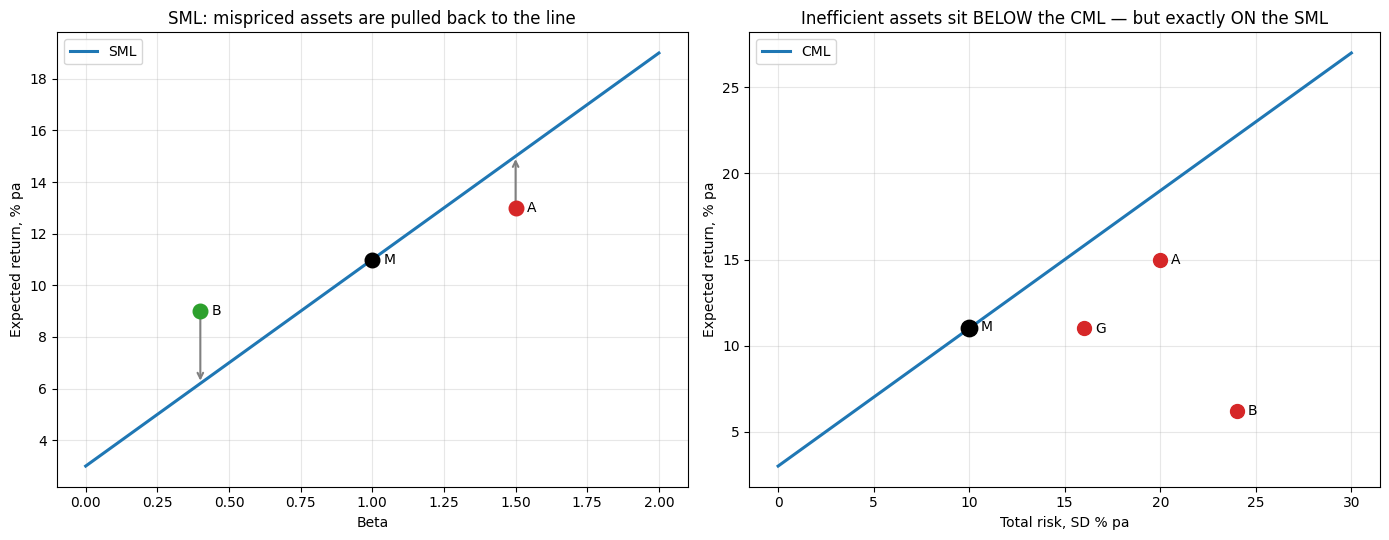

In [19]:
# ============================================================
# 3.2 Mispricing and Jensen's alpha: how prices adjust to the SML
# ============================================================
rf_m, mrp_m = 0.03, 0.08                       # E[r_M] = 11%
mis = pd.DataFrame({"beta": [1.5, 1.0, 0.4], "E[r] investors expect": [0.13, 0.11, 0.09]},
                   index=["A", "M", "B"])
mis["E[r] required (SML)"] = capm_required_return(mis.beta, rf_m, mrp_m)
mis["alpha = expected - required"] = mis["E[r] investors expect"] - mis["E[r] required (SML)"]
mis["verdict"] = np.where(mis["alpha = expected - required"] > 1e-12, "under-priced -> BUY",
                   np.where(mis["alpha = expected - required"] < -1e-12, "over-priced -> SELL", "fairly priced"))
display(mis.round(6))

b_grid = np.linspace(0, 2.0, 50)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].plot(b_grid, capm_required_return(b_grid, rf_m, mrp_m) * 100, color="tab:blue", lw=2.2, label="SML")
for k, row in mis.iterrows():
    axes[0].scatter(row.beta, row["E[r] investors expect"] * 100, s=110,
                    color="black" if k == "M" else ("tab:red" if row["alpha = expected - required"] < 0 else "tab:green"), zorder=6)
    axes[0].annotate(k, (row.beta, row["E[r] investors expect"] * 100), xytext=(8, -3),
                     textcoords="offset points")
    if abs(row["alpha = expected - required"]) > 1e-12:
        axes[0].annotate("", xy=(row.beta, row["E[r] required (SML)"] * 100),
                         xytext=(row.beta, row["E[r] investors expect"] * 100),
                         arrowprops=dict(arrowstyle="->", color="grey", lw=1.5))
axes[0].set(xlabel="Beta", ylabel="Expected return, % pa", title="SML: mispriced assets are pulled back to the line")
axes[0].legend()

# CML vs SML: inefficient assets lie below the CML but ON the SML
sd_grid_c = np.linspace(0, 0.30, 50)
axes[1].plot(sd_grid_c * 100, (rf_m + (mrp_m / 0.10) * sd_grid_c) * 100, color="tab:blue", lw=2.2, label="CML")
axes[1].scatter(10, (rf_m + mrp_m) * 100, s=140, color="black", zorder=6); axes[1].annotate("M", (10, (rf_m+mrp_m)*100), xytext=(8, -2), textcoords="offset points")
inef = pd.DataFrame({"sd": [0.20, 0.16, 0.24], "beta": [1.5, 1.0, 0.4]}, index=["A", "G", "B"])
inef["E[r]"] = capm_required_return(inef.beta, rf_m, mrp_m)
axes[1].scatter(inef.sd * 100, inef["E[r]"] * 100, s=100, color="tab:red", zorder=6)
for k, row in inef.iterrows():
    axes[1].annotate(k, (row.sd * 100, row["E[r]"] * 100), xytext=(8, -3), textcoords="offset points")
axes[1].set(xlabel="Total risk, SD % pa", ylabel="Expected return, % pa",
            title="Inefficient assets sit BELOW the CML — but exactly ON the SML")
axes[1].legend(); plt.tight_layout(); plt.show()

## 4. Applications, extensions and the empirical record

**Applications.** (i) Corporate finance — $k_E=r_F+\beta_i(E[r_M]-r_F)$ is the risk-adjusted cost of
equity used to discount free cash flows. (ii) Investment management — the SML is the benchmark for
performance: run

$$r_{P,t}-r_{F,t}=\alpha_P+\beta_P(r_{M,t}-r_{F,t})+\varepsilon_{P,t}$$

and a skilful manager should show $\alpha_P>0$. A passive portfolio has $\alpha_P=0$ by construction.

**Extensions when the assumptions fail.**

| Model | Assumption relaxed | Result |
|---|---|---|
| Black's **zero-beta** | no risk-free borrowing / lending at one rate | $E[r_i]=E[r_{Z(M)}]+\beta_i\big(E[r_M]-E[r_{Z(M)}]\big)$; since $E[r_Z]>r_F$ the SML is **flatter** |
| **Non-tradable assets** (human capital, private business) | all wealth is tradable | investors hedge their labour income; assets that hedge it are bid up, so their $E[r]$ falls below CAPM |
| **ICAPM** (Merton) | single period | $E[r_i]-r_F=\beta_{i,M}(E[r_M]-r_F)+\sum_k\beta_{i,k}(E[r_k]-r_F)$ — extra-market hedging factors |
| **CCAPM** | wealth-based risk | $E[r_i]-r_F=\beta_{i,C}(E[r_C]-r_F)$ with $C$ the consumption-tracking portfolio |

**Testing the model.** The CAPM is an ex-ante statement, so testing it needs either rational
expectations or the market model. Substituting the CAPM into the market model gives the testable
ex-post form $\;(r_{i,t}-r_{F,t})=\beta_i(r_{M,t}-r_{F,t})+\varepsilon_{i,t}$, estimated in two passes
on beta-sorted portfolios:

$$\textbf{1st pass (time series): }\;(r_{P,t}-r_{F,t})=a_P+b_P(r_{M,t}-r_{F,t})+e_{P,t}$$
$$\textbf{2nd pass (cross section): }\;\overline{(r_P-r_F)}=\gamma_0+\gamma_1b_P+u_P$$

The CAPM predicts $\gamma_0=0$, $\gamma_1=\overline{(r_M-r_F)}$, that beta is the *only* priced
factor (adding $\sigma_{eP}^2$, size, dividend yield or P/E should add nothing), and that the relation
is linear (a $b_P^2$ term should be insignificant).

**What was found.** $\gamma_0>0$ and $\gamma_1<$ the realised market premium — the empirical SML is
**too flat**: low-beta stocks earn more, and high-beta stocks less, than the CAPM predicts. Basu (1977)
found a low-P/E effect, Banz (1981) a size effect, and Fama–French (1992) concluded size and B/M
explain the cross-section better than beta, proposing

$$E[r_i]-r_F=b_i(E[r_M]-r_F)+s_iE[SMB]+h_iE[HML]$$

**Roll's critique (1977).** The only real test of the CAPM is whether the *true* market portfolio —
all assets, tradable and not — is MV efficient. It is unobservable. Since $E[r_i]$ is linear in beta
measured against **any** efficient index, a passing test only says the proxy was efficient and a
failing test only says it was not. Strictly, the CAPM is untestable.

Below, the two-pass machinery that Section IV.8 applies to the SET100.

In [20]:
# ============================================================
# 4.1 The two-pass test, implemented once and reused in Part IV
# ============================================================
def two_pass_capm(returns, market, rf_per_period, betas_for_sorting,
                  n_portfolios=10, periods_per_year=52):
    # 1st pass: time-series SCL on beta-sorted, equally weighted portfolios.
    # 2nd pass: cross-sectional regression of mean excess return on the estimated betas,
    #           then an extended version with b^2 and residual variance.
    order = betas_for_sorting.sort_values().index
    groups = np.array_split(np.array(order), n_portfolios)
    port = pd.DataFrame({f"P{i+1}": returns[list(g)].mean(axis=1) for i, g in enumerate(groups)})

    exc_m = (market - rf_per_period).dropna()
    first = []
    for c in port.columns:
        s = pd.concat([port[c] - rf_per_period, exc_m], axis=1).dropna()
        y, x = s.iloc[:, 0].values, s.iloc[:, 1].values
        X = np.column_stack([np.ones(len(x)), x])
        co, *_ = np.linalg.lstsq(X, y, rcond=None)
        res = y - X @ co
        first.append(dict(portfolio=c, a_P=co[0] * periods_per_year, b_P=co[1],
                          sigma_e2=float(res.var(ddof=2)) * periods_per_year,
                          mean_excess=y.mean() * periods_per_year, n_stocks=len(groups[int(c[1:]) - 1])))
    F = pd.DataFrame(first).set_index("portfolio")

    def ols(X, y, names):
        co, *_ = np.linalg.lstsq(X, y, rcond=None)
        res = y - X @ co
        dof = len(y) - X.shape[1]
        s2 = float(res @ res / dof)
        se = np.sqrt(np.diag(s2 * np.linalg.inv(X.T @ X)))
        return pd.DataFrame({"coef": co, "se": se, "t": co / se,
                             "p": 2 * (1 - stats.t.cdf(np.abs(co / se), dof))}, index=names)

    y2 = F.mean_excess.values
    simple = ols(np.column_stack([np.ones(len(F)), F.b_P.values]), y2, ["gamma0", "gamma1 (beta)"])
    extended = ols(np.column_stack([np.ones(len(F)), F.b_P.values, F.b_P.values ** 2,
                                    F.sigma_e2.values]), y2,
                   ["gamma0", "gamma1 (beta)", "gamma2 (beta^2)", "gamma3 (resid var)"])
    return F, simple, extended

print("two_pass_capm() ready — applied to the SET100 in Section IV.8")

two_pass_capm() ready — applied to the SET100 in Section IV.8


---
# Part IV — The Real Case: the SET100 Universe of Exactly 100 Stocks

Everything above is now applied to a live universe: **all 100 constituents of the SET100 index** of
the Stock Exchange of Thailand. The universe is fixed at 100 names — the optimiser chooses from all
of them, and no name is dropped for convenience.

## IV.1 Study design

| Choice | Setting | Why |
|---|---|---|
| **Universe** | the 100 SET100 constituents — strictly 100, asserted in code | the brief: choose the efficient portfolio out of all 100 |
| **Market proxy** | `^SET.BK`, the SET Index | broad, value-weighted Thai equity index (Roll's critique applies — it is a *proxy*) |
| **Price series** | Yahoo Finance close, `auto_adjust=True` | dividend- and split-adjusted, i.e. a **total return** series, as Topic 4 recommends |
| **Sampling interval** | **weekly** (Friday) | 260 observations > 100 assets, so a sample covariance matrix is estimable; weekly also softens the non-synchronous-trading bias that distorts daily Thai betas |
| **Sampling period** | the latest **5 years** | the horizon the lecture exercises use; long enough for stable betas, short enough to stay relevant |
| **Annualisation** | $\mu_{ann}=52\mu_w$, $\sigma_{ann}=\sqrt{52}\,\sigma_w$ | arithmetic mean and SD scaling, per Topic 4 §4.1 |
| **Risk-free rate** | `RF_ANNUAL = 1.75%` pa, a parameter | short Thai government yield; sensitivity to this choice is reported in IV.7 |

**Two assumptions worth stating up front.**

1. *Survivorship / point-in-time bias.* Membership is today's SET100. Names that were in the index
   five years ago and have since dropped out are absent, which biases historical performance upward.
   A production system would use point-in-time membership.
2. *Ragged history.* Several constituents are recent listings or the product of corporate
   restructurings (GULF's merger, TIDLOR's holding-company conversion, STEC→STECON, MRDIYT's 2025
   IPO), so their series are shorter than five years. Rather than dropping them — which would break
   the 100-name universe — each stock's SCL is estimated on **its own** available history and the
   observation count is carried through every table so thin estimates are visible.

In [21]:
# ============================================================
# IV.2 The universe — exactly 100 SET100 constituents
# ============================================================
SET100_UNIVERSE = [
    ("DELTA", "Delta Electronics (Thailand) Public Co. Ltd.", "Electronic Technology"),
    ("PTT", "PTT Public Co., Ltd.", "Energy Minerals"),
    ("ADVANC", "Advanced Info Service Public Co., Ltd.", "Communications"),
    ("GULF", "Gulf Development Public Company Limited", "Industrial Services"),
    ("AOT", "Airports of Thailand Public Co Ltd", "Transportation"),
    ("KTB", "Krung Thai Bank Public Co., Ltd.", "Finance"),
    ("PTTEP", "PTT Exploration & Production Plc", "Energy Minerals"),
    ("KBANK", "Kasikornbank Public Co. Ltd.", "Finance"),
    ("SCB", "SCB X Public Company Limited", "Finance"),
    ("TRUE", "True Corporation Public Company Limited", "Communications"),
    ("CPALL", "CP ALL Public Company Limited", "Retail Trade"),
    ("BBL", "Bangkok Bank Public Company Limited", "Finance"),
    ("SCC", "Siam Cement Public Co. Ltd.", "Non-Energy Minerals"),
    ("BDMS", "Bangkok Dusit Medical Services Public Co. Ltd.", "Health Services"),
    ("CPN", "Central Pattana Public Co. Ltd.", "Finance"),
    ("TTB", "TMBThanachart Bank Public Company Limited", "Finance"),
    ("PTTGC", "PTT Global Chemical Public Company Limited", "Energy Minerals"),
    ("CPF", "Charoen Pokphand Foods Public Co. Ltd.", "Process Industries"),
    ("CRC", "Central Retail Corporation Public Company Limited", "Retail Trade"),
    ("THAI", "Thai Airways International Public Co. Ltd.", "Transportation"),
    ("BH", "Bumrungrad Hospital Public Co., Ltd.", "Health Services"),
    ("OR", "PTT Oil and Retail Business Public Co Limited", "Distribution Services"),
    ("GPSC", "Global Power Synergy Public Company Ltd", "Utilities"),
    ("TOP", "Thai Oil Public Co. Ltd.", "Energy Minerals"),
    ("IVL", "Indorama Ventures Public Co. Ltd.", "Process Industries"),
    ("SCGP", "SCG Packaging Public Co Ltd", "Process Industries"),
    ("TLI", "Thai Life Insurance Public Co. Ltd.", "Finance"),
    ("MINT", "Minor International Public Co., Ltd.", "Consumer Services"),
    ("BEM", "Bangkok Expressway and Metro Public Company Limited", "Transportation"),
    ("KKP", "Kiatnakin Phatra Bank Public Co. Ltd.", "Finance"),
    ("TISCO", "TISCO Financial Group Public Co. Ltd.", "Finance"),
    ("CCET", "Cal-Comp Electronics (Thailand) Public Co., Ltd.", "Electronic Technology"),
    ("AWC", "Asset World Corporation Public Company Limited", "Finance"),
    ("KTC", "KrungThai Card Public Co. Ltd.", "Finance"),
    ("HMPRO", "Home Product Center Public Co., Ltd.", "Retail Trade"),
    ("RATCH", "Ratch Group Public Co. Ltd.", "Utilities"),
    ("BCP", "Bangchak Corporation Public Company Ltd", "Retail Trade"),
    ("TCAP", "Thanachart Capital Public Co., Ltd.", "Finance"),
    ("WHA", "WHA Corporation Public Company Limited", "Finance"),
    ("KCE", "KCE Electronics Public Co., Ltd.", "Electronic Technology"),
    ("COM7", "Com7 Public Co. Ltd.", "Retail Trade"),
    ("EGCO", "Electricity Generating Public Co., Ltd.", "Utilities"),
    ("MTC", "Muangthai Capital Public Co. Ltd.", "Finance"),
    ("BJC", "Berli Jucker Public Co. Ltd.", "Process Industries"),
    ("TFG", "Thaifoods Group Public Co. Ltd.", "Process Industries"),
    ("BANPU", "Banpu Public Co. Ltd.", "Energy Minerals"),
    ("CENTEL", "Central Plaza Hotel Public Co. Ltd.", "Consumer Services"),
    ("SPRC", "Star Petroleum Refining Public Co. Ltd.", "Energy Minerals"),
    ("MRDIYT", "MR.D.I.Y. Holding (Thailand) Public Company Limited", "Retail Trade"),
    ("TIDLOR", "Tidlor Holdings Public Company Limited", "Finance"),
    ("IRPC", "IRPC Public Co., Ltd.", "Energy Minerals"),
    ("CBG", "Carabao Group Public Company Ltd", "Consumer Non-Durables"),
    ("BGRIM", "B.Grimm Power Public Company Ltd", "Utilities"),
    ("OSP", "Osotspa Public Co. Ltd.", "Consumer Non-Durables"),
    ("TU", "Thai Union Group Public Company Limited", "Consumer Non-Durables"),
    ("GUNKUL", "Gunkul Engineering Public Co. Ltd.", "Utilities"),
    ("LH", "Land & Houses Public Co., Ltd.", "Finance"),
    ("BLA", "Bangkok Life Assurance Public Co., Ltd.", "Finance"),
    ("BTG", "Betagro Public Company Limited", "Process Industries"),
    ("BA", "Bangkok Airways Public Co., Ltd.", "Transportation"),
    ("SAWAD", "Srisawad Corporation Public Company Ltd", "Finance"),
    ("GLOBAL", "Siam Global House Public Co., Ltd.", "Retail Trade"),
    ("HANA", "Hana Microelectronics Public Co., Ltd.", "Electronic Technology"),
    ("AMATA", "Amata Corporation Public Company", "Finance"),
    ("RCL", "Regional Container Lines Public Co. Ltd.", "Transportation"),
    ("STA", "Sri Trang Agro-Industry Public Co. Ltd.", "Process Industries"),
    ("BTS", "BTS Group Holdings Public Co. Ltd.", "Transportation"),
    ("STGT", "Sri Trang Gloves (Thailand) Public Co. Ltd.", "Producer Manufacturing"),
    ("TOA", "TOA Paint (Thailand) Public Company Limited", "Process Industries"),
    ("MEGA", "Mega Lifesciences Public Co. Ltd.", "Health Technology"),
    ("CK", "CH. Karnchang Public Co. Ltd.", "Industrial Services"),
    ("PLANB", "Plan B Media Public Company Ltd", "Commercial Services"),
    ("WHAUP", "WHA Utilities and Power Public Company Limited", "Utilities"),
    ("SPALI", "Supalai Public Co., Ltd.", "Finance"),
    ("TASCO", "Tipco Asphalt Public Co. Ltd.", "Non-Energy Minerals"),
    ("STECON", "Stecon Group Public Company Limited", "Industrial Services"),
    ("BCH", "Bangkok Chain Hospital Public Co., Ltd.", "Health Services"),
    ("AP", "AP (Thailand) Public Co. Ltd.", "Consumer Durables"),
    ("SIRI", "Sansiri Public Co. Ltd.", "Finance"),
    ("AEONTS", "AEON Thana Sinsap (Thailand) Public Co. Ltd.", "Finance"),
    ("BCPG", "BCPG Public Company Limited", "Utilities"),
    ("EA", "Energy Absolute Public Co. Ltd.", "Utilities"),
    ("VGI", "VGI Public Company Limited", "Commercial Services"),
    ("PRM", "Prima Marine Public Company Ltd", "Transportation"),
    ("BAM", "Bangkok Commercial Asset Management Public Co., Ltd.", "Finance"),
    ("M", "MK Restaurant Group PCL", "Consumer Services"),
    ("AURA", "Aurora Design Public Company Limited", "Consumer Durables"),
    ("ERW", "Erawan Group Public Co., Ltd.", "Consumer Services"),
    ("ICHI", "Ichitan Group Public Co., Ltd.", "Consumer Non-Durables"),
    ("JMT", "JMT Network Services Public Co. Ltd.", "Commercial Services"),
    ("JMART", "Jaymart Group Holdings Public Company Limited", "Distribution Services"),
    ("CHG", "Chularat Hospital PCL", "Health Services"),
    ("QH", "Quality Houses Public Co. Ltd.", "Finance"),
    ("PR9", "Praram 9 Hospital Public Co Limited", "Health Services"),
    ("AAV", "Asia Aviation Public Co., Ltd.", "Transportation"),
    ("PTG", "PTG Energy Public Co. Ltd.", "Retail Trade"),
    ("MOSHI", "Moshi Moshi Retail Corporation Public Company Limited", "Distribution Services"),
    ("DOHOME", "Dohome Public Company Limited", "Distribution Services"),
    ("GFPT", "GFPT Public Co. Ltd.", "Consumer Non-Durables"),
    ("THCOM", "Thaicom Public Co. Ltd.", "Communications"),
]

assert len(SET100_UNIVERSE) == 100, "the SET100 universe must contain exactly 100 names"
assert len({t for t, _, _ in SET100_UNIVERSE}) == 100, "tickers must be unique"

universe = pd.DataFrame(SET100_UNIVERSE, columns=["symbol", "company", "sector"])
universe["yf_ticker"] = universe.symbol + ".BK"
MARKET = "^SET.BK"
TICKERS = universe.yf_ticker.tolist()

print(f"Universe size: {len(universe)} stocks  (assertion passed)")
display(universe.sector.value_counts().rename("n stocks").to_frame())
display(universe.head(10))


def refresh_set100_universe():
    # Optional: re-pull the current SET100 membership. Returns None on any failure so the
    # notebook always falls back to the embedded, reproducible list above.
    import urllib.request
    req = urllib.request.Request(
        "https://scanner.tradingview.com/thailand/scan",
        data=json.dumps({"symbols": {"symbolset": ["SYML:SET;SET100"]},
                         "columns": ["name", "description", "sector"],
                         "sort": {"sortBy": "market_cap_basic", "sortOrder": "desc"},
                         "range": [0, 200]}).encode(),
        headers={"Content-Type": "application/json", "User-Agent": "Mozilla/5.0"})
    try:
        with urllib.request.urlopen(req, timeout=30) as r:
            rows = json.load(r)["data"]
        out = [(d["d"][0], d["d"][1], d["d"][2]) for d in rows]
        return out if len(out) == 100 else None
    except Exception as exc:
        print("universe refresh unavailable:", exc)
        return None

Universe size: 100 stocks  (assertion passed)


,n stocks
sector,
Finance,24
Transportation,8
Retail Trade,8
Process Industries,8
Utilities,8
Energy Minerals,7
Health Services,5
Consumer Non-Durables,5
Electronic Technology,4


,symbol,company,sector,yf_ticker
0,DELTA,Delta Electronics (Thailand) Public Co. Ltd.,Electronic Technology,DELTA.BK
1,PTT,"PTT Public Co., Ltd.",Energy Minerals,PTT.BK
2,ADVANC,"Advanced Info Service Public Co., Ltd.",Communications,ADVANC.BK
3,GULF,Gulf Development Public Company Limited,Industrial Services,GULF.BK
4,AOT,Airports of Thailand Public Co Ltd,Transportation,AOT.BK
5,KTB,"Krung Thai Bank Public Co., Ltd.",Finance,KTB.BK
6,PTTEP,PTT Exploration & Production Plc,Energy Minerals,PTTEP.BK
7,KBANK,Kasikornbank Public Co. Ltd.,Finance,KBANK.BK
8,SCB,SCB X Public Company Limited,Finance,SCB.BK
9,TRUE,True Corporation Public Company Limited,Communications,TRUE.BK


In [22]:
# ============================================================
# IV.3 Price data -> weekly total returns
# ============================================================
import yfinance as yf

PERIODS_PER_YEAR = 52
LOOKBACK_YEARS = 5
RF_ANNUAL = 0.0175
RF_WEEKLY = RF_ANNUAL / PERIODS_PER_YEAR
MRP_FORWARD = 0.06        # forward-looking Thai equity risk premium, used from IV.7d onward

CACHE = Path(".cache"); CACHE.mkdir(exist_ok=True)
CACHE_FILE = CACHE / "set100_prices.pkl"

def load_prices(tickers, market, start="2015-01-01", use_cache=True):
    if use_cache and CACHE_FILE.exists():
        px = pd.read_pickle(CACHE_FILE)
        if set(tickers + [market]).issubset(px.columns):
            print(f"loaded {px.shape[1]} price series from cache ({CACHE_FILE})")
            return px
    px = yf.download(tickers + [market], start=start, interval="1d",
                     auto_adjust=True, progress=False, threads=True)["Close"]
    px.to_pickle(CACHE_FILE)
    print(f"downloaded {px.shape[1]} price series from Yahoo Finance -> cached")
    return px

prices_daily = load_prices(TICKERS, MARKET)
prices_weekly = prices_daily.resample("W-FRI").last()

DATA_END = prices_weekly.index.max()
WINDOW_START = DATA_END - pd.DateOffset(years=LOOKBACK_YEARS)
rets = prices_weekly.loc[prices_weekly.index >= WINDOW_START].pct_change().iloc[1:]
rets = rets[TICKERS + [MARKET]]

print(f"\nEstimation window : {rets.index.min():%d %b %Y}  ->  {rets.index.max():%d %b %Y}")
print(f"Weekly observations: T = {len(rets)}   Assets: N = {len(TICKERS)}   (T > N, so a sample "
      f"covariance matrix is estimable)")
missing = [t for t in TICKERS if rets[t].notna().sum() == 0]
print(f"Tickers with no data at all: {missing if missing else 'none — all 100 resolve'}")

loaded 101 price series from cache (.cache/set100_prices.pkl)

Estimation window : 17 Sep 2021  ->  04 Sep 2026
Weekly observations: T = 260   Assets: N = 100   (T > N, so a sample covariance matrix is estimable)
Tickers with no data at all: none — all 100 resolve


In [23]:
# ============================================================
# IV.3b Data quality: how much history does each name actually have?
# ============================================================
coverage = pd.DataFrame({
    "obs": rets[TICKERS].notna().sum(),
    "first_return": [rets[t].first_valid_index() for t in TICKERS],
})
coverage["years"] = coverage.obs / PERIODS_PER_YEAR
coverage["coverage %"] = coverage.obs / len(rets) * 100
coverage.index = universe.symbol.values

thin = coverage[coverage.obs < len(rets)].sort_values("obs")
print(f"Names with the full {len(rets)}-week history : {(coverage.obs == len(rets)).sum()} of 100")
print(f"Names with >= 2 years of history            : {(coverage.obs >= 104).sum()} of 100")
print(f"Shortest history                            : {coverage.obs.min()} weeks "
      f"({coverage.obs.idxmin()})\n")
print("Short-history names (carried through the whole study, flagged everywhere):")
display(thin.head(12).round(2))

MIN_OBS = 30          # minimum weekly observations to estimate an SCL
print(f"\nAll 100 names clear the MIN_OBS = {MIN_OBS} threshold: "
      f"{(coverage.obs >= MIN_OBS).all()}")

Names with the full 260-week history : 90 of 100
Names with >= 2 years of history            : 96 of 100
Shortest history                            : 43 weeks (MRDIYT)

Short-history names (carried through the whole study, flagged everywhere):


,obs,first_return,years,coverage %
MRDIYT,43,2025-11-14,0.830000,16.540000
TIDLOR,68,2025-05-23,1.310000,26.150000
GULF,74,2025-04-11,1.420000,28.460000
STECON,96,2024-11-08,1.850000,36.920000
MOSHI,193,2022-12-30,3.710000,74.230000
AURA,196,2022-12-09,3.770000,75.380000
BTG,199,2022-11-18,3.830000,76.540000
TLI,214,2022-08-05,4.120000,82.310000
SCB,228,2022-04-29,4.380000,87.690000
BANPU,257,2021-09-17,4.940000,98.850000



All 100 names clear the MIN_OBS = 30 threshold: True


In [24]:
# ============================================================
# IV.4 Descriptive statistics — the raw input list
# ============================================================
mu_weekly = rets[TICKERS].mean()
sd_weekly = rets[TICKERS].std(ddof=1)

stats_tbl = pd.DataFrame({
    "E[r] pa": mu_weekly * PERIODS_PER_YEAR,
    "SD pa": sd_weekly * np.sqrt(PERIODS_PER_YEAR),
    "obs": rets[TICKERS].notna().sum(),
})
stats_tbl.index = universe.symbol.values
stats_tbl["Sharpe"] = (stats_tbl["E[r] pa"] - RF_ANNUAL) / stats_tbl["SD pa"]
stats_tbl["sector"] = universe.sector.values

mu_M = rets[MARKET].mean() * PERIODS_PER_YEAR
sd_M = rets[MARKET].std(ddof=1) * np.sqrt(PERIODS_PER_YEAR)
print(f"SET Index over the window : E[r] = {mu_M:.4%} pa,  SD = {sd_M:.4%} pa,  "
      f"Sharpe = {(mu_M - RF_ANNUAL)/sd_M:.4f}")
print(f"Cross-section of the 100  : E[r] median {stats_tbl['E[r] pa'].median():.4%}, "
      f"range {stats_tbl['E[r] pa'].min():.2%} to {stats_tbl['E[r] pa'].max():.2%}")
print(f"                            SD   median {stats_tbl['SD pa'].median():.4%}, "
      f"range {stats_tbl['SD pa'].min():.2%} to {stats_tbl['SD pa'].max():.2%}\n")

print("Top 10 by historical Sharpe ratio")
display(stats_tbl.sort_values("Sharpe", ascending=False).head(10).round(4))
print("Bottom 5 by historical Sharpe ratio")
display(stats_tbl.sort_values("Sharpe").head(5).round(4))

SET Index over the window : E[r] = 0.9223% pa,  SD = 13.2586% pa,  Sharpe = -0.0624
Cross-section of the 100  : E[r] median 4.2641%, range -36.30% to 65.84%
                            SD   median 30.2054%, range 8.92% to 155.01%

Top 10 by historical Sharpe ratio


,E[r] pa,SD pa,obs,Sharpe,sector
KTB,0.354200,0.210300,260,1.600800,Finance
TISCO,0.145500,0.089200,260,1.435200,Finance
TCAP,0.248000,0.171400,260,1.344700,Finance
TTB,0.284800,0.200400,260,1.333900,Finance
KBANK,0.214400,0.198100,260,0.993800,Finance
ADVANC,0.187200,0.175700,260,0.965600,Communications
KKP,0.244600,0.239700,260,0.947600,Finance
GULF,0.300500,0.308600,74,0.916900,Industrial Services
SCB,0.246500,0.259100,228,0.883900,Finance
STECON,0.658400,0.780500,96,0.821100,Industrial Services


Bottom 5 by historical Sharpe ratio


,E[r] pa,SD pa,obs,Sharpe,sector
BTS,-0.242200,0.301500,260,-0.861200,Transportation
DOHOME,-0.254200,0.378700,260,-0.717500,Distribution Services
EA,-0.363000,0.693300,260,-0.548900,Utilities
AAV,-0.135700,0.312500,260,-0.490300,Transportation
BAM,-0.124000,0.298300,260,-0.474400,Finance


Average pairwise correlation across the SET100 : 0.2222
Range: -0.3597 to 0.8058


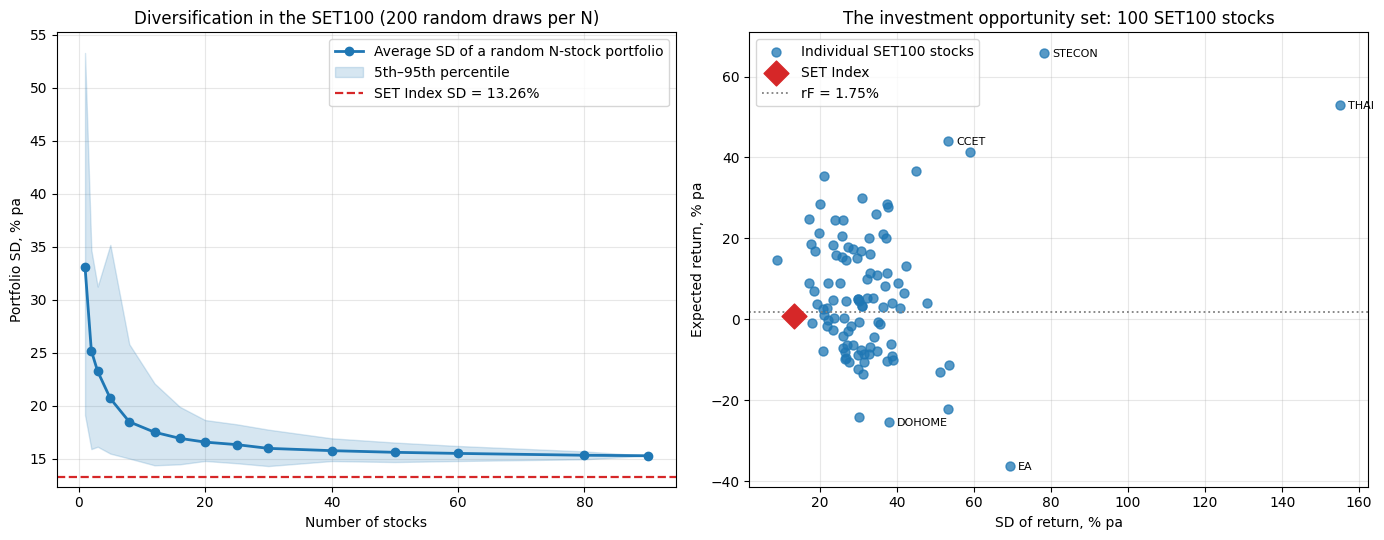


A single average stock carries 33.09% SD; 30 stocks cut it to 15.98% — 51.7% of stand-alone risk removed. Beyond ~30 names the curve is flat: what is left is market risk.


In [25]:
# ============================================================
# IV.4b The opportunity set, and diversification measured on real SET100 data
# ============================================================
corr = rets[TICKERS].corr(min_periods=MIN_OBS)
off = corr.values[~np.eye(len(TICKERS), dtype=bool)]
print(f"Average pairwise correlation across the SET100 : {np.nanmean(off):.4f}")
print(f"Range: {np.nanmin(off):.4f} to {np.nanmax(off):.4f}")

# Repeat the Topic 4 diversification experiment with actual data:
# randomly selected equally weighted portfolios of N stocks.
full_hist = coverage.index[coverage.obs == len(rets)]
full_cols = universe.set_index("symbol").loc[full_hist, "yf_ticker"].tolist()
rng = np.random.default_rng(42)
Ns = [1, 2, 3, 5, 8, 12, 16, 20, 25, 30, 40, 50, 60, 80, len(full_cols)]
rows = []
for N in Ns:
    sds = []
    for _ in range(200):
        pick = rng.choice(full_cols, size=N, replace=False)
        sds.append(rets[list(pick)].mean(axis=1).std(ddof=1) * np.sqrt(PERIODS_PER_YEAR))
    rows.append({"N": N, "avg SD pa": np.mean(sds), "5th pct": np.percentile(sds, 5),
                 "95th pct": np.percentile(sds, 95)})
div = pd.DataFrame(rows).set_index("N")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
axes[0].plot(div.index, div["avg SD pa"] * 100, marker="o", lw=2, color="tab:blue",
             label="Average SD of a random N-stock portfolio")
axes[0].fill_between(div.index, div["5th pct"] * 100, div["95th pct"] * 100, alpha=0.18,
                     color="tab:blue", label="5th–95th percentile")
axes[0].axhline(sd_M * 100, color="tab:red", ls="--", lw=1.6, label=f"SET Index SD = {sd_M:.2%}")
axes[0].set(xlabel="Number of stocks", ylabel="Portfolio SD, % pa",
            title="Diversification in the SET100 (200 random draws per N)")
axes[0].legend()

axes[1].scatter(stats_tbl["SD pa"] * 100, stats_tbl["E[r] pa"] * 100, s=42, alpha=0.75,
                color="tab:blue", label="Individual SET100 stocks")
axes[1].scatter(sd_M * 100, mu_M * 100, marker="D", s=160, color="tab:red", zorder=6, label="SET Index")
axes[1].axhline(RF_ANNUAL * 100, color="grey", ls=":", lw=1.3, label=f"rF = {RF_ANNUAL:.2%}")
for lab in stats_tbl.nlargest(3, "E[r] pa").index.tolist() + stats_tbl.nsmallest(2, "E[r] pa").index.tolist():
    axes[1].annotate(lab, (stats_tbl.loc[lab, "SD pa"] * 100, stats_tbl.loc[lab, "E[r] pa"] * 100),
                     xytext=(6, -3), textcoords="offset points", fontsize=8)
axes[1].set(xlabel="SD of return, % pa", ylabel="Expected return, % pa",
            title="The investment opportunity set: 100 SET100 stocks")
axes[1].legend(); plt.tight_layout(); plt.show()

print(f"\nA single average stock carries {div.loc[1,'avg SD pa']:.2%} SD; 30 stocks cut it to "
      f"{div.loc[30,'avg SD pa']:.2%} — {1 - div.loc[30,'avg SD pa']/div.loc[1,'avg SD pa']:.1%} of "
      f"stand-alone risk removed. Beyond ~30 names the curve is flat: what is left is market risk.")

## IV.5 Single Index Model: estimating the SCL for all 100 stocks

For every constituent we run

$$\big(r_{i,t}-r_{F,t}\big)=\alpha_i+\beta_i\big(r_{SET,t}-r_{F,t}\big)+\varepsilon_{i,t}$$

on weekly excess returns, and record $\alpha_i$ (annualised), $\beta_i$, $\sigma_{\varepsilon i}$
(annualised), $R^2$, the $t$-statistics and the number of observations. That is $3\times100+2=302$
estimates in place of the $5{,}150$ a full Markowitz input list would need.

In [26]:
# ============================================================
# IV.5 SCL regressions for all 100 constituents
# ============================================================
scl_rows = {}
for sym, tic in zip(universe.symbol, universe.yf_ticker):
    out = run_scl(rets[tic], rets[MARKET], RF_WEEKLY, periods_per_year=PERIODS_PER_YEAR)
    if out is not None and out["n"] >= MIN_OBS:
        scl_rows[sym] = out

sim_tbl = pd.DataFrame(scl_rows).T.astype(float)
sim_tbl["sector"] = universe.set_index("symbol").loc[sim_tbl.index, "sector"]
sim_tbl = sim_tbl[["n", "beta", "t_beta", "alpha_ann", "t_alpha", "p_alpha",
                   "sigma_eps_ann", "r2", "sector"]]

assert len(sim_tbl) == 100, "every one of the 100 names must have an estimated SCL"
print(f"SCL estimated for {len(sim_tbl)} of 100 stocks  (assertion passed)\n")

print("Cross-sectional summary of the SIM estimates")
display(sim_tbl[["n", "beta", "t_beta", "alpha_ann", "sigma_eps_ann", "r2"]].describe().round(4))

print("\nHighest-beta names")
display(sim_tbl.nlargest(8, "beta").round(4))
print("Lowest-beta names")
display(sim_tbl.nsmallest(8, "beta").round(4))

SCL estimated for 100 of 100 stocks  (assertion passed)

Cross-sectional summary of the SIM estimates


,n,beta,t_beta,alpha_ann,sigma_eps_ann,r2
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,242.710000,0.989600,7.346400,0.047200,0.298400,0.187900
std,38.964200,0.374800,2.293500,0.162700,0.164000,0.088400
min,36.000000,0.156400,0.632900,-0.359600,0.080700,0.011600
25%,253.000000,0.717500,5.923500,-0.066000,0.225800,0.123300
50%,253.000000,0.970500,7.679800,0.007200,0.275400,0.190300
75%,253.000000,1.203800,9.114900,0.139400,0.322400,0.249800
max,253.000000,2.306400,11.903500,0.612600,1.559900,0.555400



Highest-beta names


,n,beta,t_beta,alpha_ann,t_alpha,p_alpha,sigma_eps_ann,r2,sector
DELTA,253.000000,2.306400,9.502100,0.465600,2.010300,0.045500,0.510900,0.264600,Electronic Technology
JMART,253.000000,1.875200,8.229000,-0.098200,-0.451600,0.652000,0.479600,0.212500,Distribution Services
EA,253.000000,1.859300,5.944000,-0.359600,-1.204800,0.229400,0.658400,0.123400,Utilities
JMT,253.000000,1.684100,7.601400,-0.113800,-0.538200,0.590900,0.466300,0.187100,Commercial Services
VGI,253.000000,1.626900,6.975800,-0.224900,-1.010400,0.313300,0.490900,0.162400,Commercial Services
BGRIM,253.000000,1.588500,10.400300,-0.067700,-0.464500,0.642700,0.321500,0.301200,Utilities
THAI,253.000000,1.588400,2.143300,0.549300,0.776700,0.438100,1.559900,0.018000,Transportation
IRPC,253.000000,1.587700,9.536800,-0.032200,-0.202600,0.839600,0.350400,0.266000,Energy Minerals


Lowest-beta names


,n,beta,t_beta,alpha_ann,t_alpha,p_alpha,sigma_eps_ann,r2,sector
MRDIYT,36.000000,0.156400,0.632900,0.290200,0.940300,0.353700,0.247700,0.011600,Retail Trade
TISCO,253.000000,0.291300,7.601000,0.137500,3.761200,0.000200,0.080700,0.187100,Finance
SCB,221.000000,0.421000,3.361200,0.251600,2.020100,0.044600,0.256700,0.049100,Finance
PTTEP,253.000000,0.422000,3.745100,0.137600,1.279400,0.201900,0.237200,0.052900,Energy Minerals
TU,253.000000,0.434800,4.074300,-0.064800,-0.635900,0.525400,0.224600,0.062000,Consumer Non-Durables
TCAP,253.000000,0.435100,6.037600,0.210200,3.056000,0.002500,0.151700,0.126800,Finance
AURA,189.000000,0.524400,3.479500,0.050600,0.329900,0.741800,0.292600,0.060800,Consumer Durables
TASCO,253.000000,0.530000,6.980300,0.019200,0.264800,0.791400,0.159800,0.162600,Non-Energy Minerals


In [27]:
# ============================================================
# IV.5b Alphas: how many are statistically distinguishable from zero?
# ============================================================
sig5 = sim_tbl[sim_tbl.p_alpha < 0.05]
print(f"Stocks with |t(alpha)| large enough to reject alpha = 0 at 5% : {len(sig5)} of 100")
print(f"  positive alpha: {(sig5.alpha_ann > 0).sum()}    negative alpha: {(sig5.alpha_ann < 0).sum()}")
print(f"  under pure chance one would expect about 5 of 100 to be 'significant'\n")

print("Ranking by the SIZE of alpha and by its SIGNIFICANCE give different lists: the biggest alphas")
print("below belong to volatile names whose large residual SD makes the estimate unreliable. It is")
print("alpha per unit of residual risk — the information ratio — that decides active weights.\n")
print("Largest positive alphas (annualised)")
display(sim_tbl.nlargest(8, "alpha_ann")[["n", "beta", "alpha_ann", "t_alpha", "p_alpha",
                                          "sigma_eps_ann", "r2", "sector"]].round(4))
print("Largest negative alphas (annualised)")
display(sim_tbl.nsmallest(5, "alpha_ann")[["n", "beta", "alpha_ann", "t_alpha", "p_alpha",
                                           "sigma_eps_ann", "r2", "sector"]].round(4))

# Information ratio — the quantity that drives active weights (Topic 5 §3.1)
sim_tbl["info_ratio"] = sim_tbl.alpha_ann / sim_tbl.sigma_eps_ann
print("\nTop information ratios (alpha / sigma_eps)")
display(sim_tbl.nlargest(8, "info_ratio")[["beta", "alpha_ann", "sigma_eps_ann", "info_ratio",
                                           "n", "sector"]].round(4))

Stocks with |t(alpha)| large enough to reject alpha = 0 at 5% : 11 of 100
  positive alpha: 11    negative alpha: 0
  under pure chance one would expect about 5 of 100 to be 'significant'

Ranking by the SIZE of alpha and by its SIGNIFICANCE give different lists: the biggest alphas
below belong to volatile names whose large residual SD makes the estimate unreliable. It is
alpha per unit of residual risk — the information ratio — that decides active weights.

Largest positive alphas (annualised)


,n,beta,alpha_ann,t_alpha,p_alpha,sigma_eps_ann,r2,sector
STECON,89.000000,1.395700,0.612600,1.036500,0.302800,0.772100,0.084600,Industrial Services
THAI,253.000000,1.588400,0.549300,0.776700,0.438100,1.559900,0.018000,Transportation
DELTA,253.000000,2.306400,0.465600,2.010300,0.045500,0.510900,0.264600,Electronic Technology
CCET,253.000000,1.330900,0.427400,1.855100,0.064800,0.508100,0.108000,Electronic Technology
TRUE,253.000000,0.781700,0.378400,1.890000,0.059900,0.441600,0.052400,Communications
KTB,253.000000,0.667400,0.340600,3.914100,0.000100,0.191900,0.175900,Finance
MRDIYT,36.000000,0.156400,0.290200,0.940300,0.353700,0.247700,0.011600,Retail Trade
TFG,253.000000,0.604200,0.288400,1.717300,0.087200,0.370400,0.044900,Process Industries


Largest negative alphas (annualised)


,n,beta,alpha_ann,t_alpha,p_alpha,sigma_eps_ann,r2,sector
EA,253.000000,1.859300,-0.359600,-1.204800,0.229400,0.658400,0.123400,Utilities
DOHOME,253.000000,1.077500,-0.250300,-1.566200,0.118600,0.352500,0.141600,Distribution Services
BTS,253.000000,1.003700,-0.244700,-1.966300,0.050400,0.274500,0.191000,Transportation
VGI,253.000000,1.626900,-0.224900,-1.010400,0.313300,0.490900,0.162400,Commercial Services
AAV,253.000000,1.142500,-0.133800,-1.060200,0.290100,0.278300,0.229300,Transportation



Top information ratios (alpha / sigma_eps)


,beta,alpha_ann,sigma_eps_ann,info_ratio,n,sector
KTB,0.667400,0.340600,0.191900,1.774600,253.000000,Finance
TISCO,0.291300,0.137500,0.080700,1.705200,253.000000,Finance
TTB,0.582600,0.259800,0.180400,1.440000,253.000000,Finance
TCAP,0.435100,0.210200,0.151700,1.385500,253.000000,Finance
ADVANC,0.595100,0.192300,0.158900,1.210300,253.000000,Communications
MRDIYT,0.156400,0.290200,0.247700,1.171600,36.000000,Retail Trade
KBANK,0.655700,0.195800,0.179100,1.093700,253.000000,Finance
KKP,0.766600,0.218600,0.210600,1.037900,253.000000,Finance


Median share of variance that is systematic: 18.97%
=> for a typical SET100 stock roughly 81% of variance is diversifiable firm-specific risk.



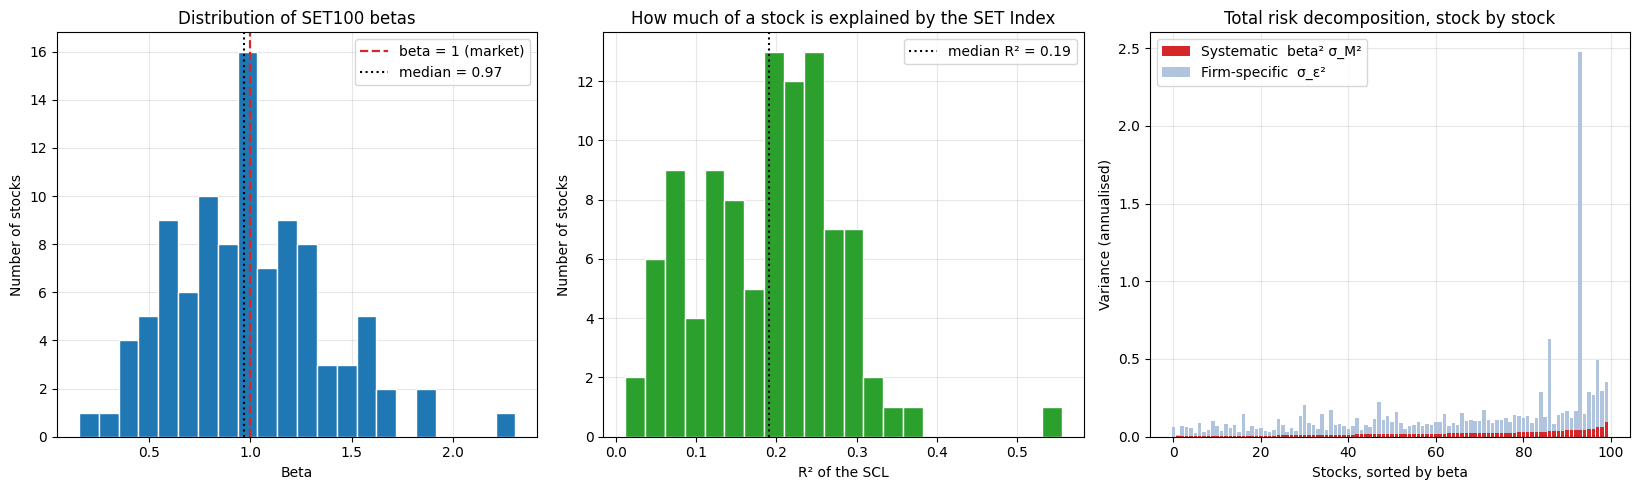

In [28]:
# ============================================================
# IV.5c Risk decomposition:  sigma_i^2 = beta_i^2 sigma_M^2 + sigma_eps_i^2
# ============================================================
sigma_M2 = sd_M ** 2
decomp = pd.DataFrame({
    "beta": sim_tbl.beta,
    "systematic": sim_tbl.beta ** 2 * sigma_M2,
    "firm-specific": sim_tbl.sigma_eps_ann ** 2,
})
decomp["total"] = decomp.systematic + decomp["firm-specific"]
decomp["systematic %"] = decomp.systematic / decomp.total * 100
decomp["SD pa"] = np.sqrt(decomp.total)

print(f"Median share of variance that is systematic: {decomp['systematic %'].median():.2f}%")
print(f"=> for a typical SET100 stock roughly {100 - decomp['systematic %'].median():.0f}% of "
      f"variance is diversifiable firm-specific risk.\n")

fig, axes = plt.subplots(1, 3, figsize=(16.5, 5))
axes[0].hist(sim_tbl.beta, bins=22, color="tab:blue", edgecolor="white")
axes[0].axvline(1.0, color="tab:red", ls="--", lw=1.6, label="beta = 1 (market)")
axes[0].axvline(sim_tbl.beta.median(), color="black", ls=":", lw=1.5,
                label=f"median = {sim_tbl.beta.median():.2f}")
axes[0].set(xlabel="Beta", ylabel="Number of stocks", title="Distribution of SET100 betas")
axes[0].legend()

axes[1].hist(sim_tbl.r2, bins=22, color="tab:green", edgecolor="white")
axes[1].axvline(sim_tbl.r2.median(), color="black", ls=":", lw=1.5,
                label=f"median R² = {sim_tbl.r2.median():.2f}")
axes[1].set(xlabel="R² of the SCL", ylabel="Number of stocks",
            title="How much of a stock is explained by the SET Index")
axes[1].legend()

srt = decomp.sort_values("beta")
axes[2].bar(range(len(srt)), srt.systematic, color="tab:red", label="Systematic  beta² σ_M²")
axes[2].bar(range(len(srt)), srt["firm-specific"], bottom=srt.systematic,
            color="lightsteelblue", label="Firm-specific  σ_ε²")
axes[2].set(xlabel="Stocks, sorted by beta", ylabel="Variance (annualised)",
            title="Total risk decomposition, stock by stock")
axes[2].legend(); plt.tight_layout(); plt.show()

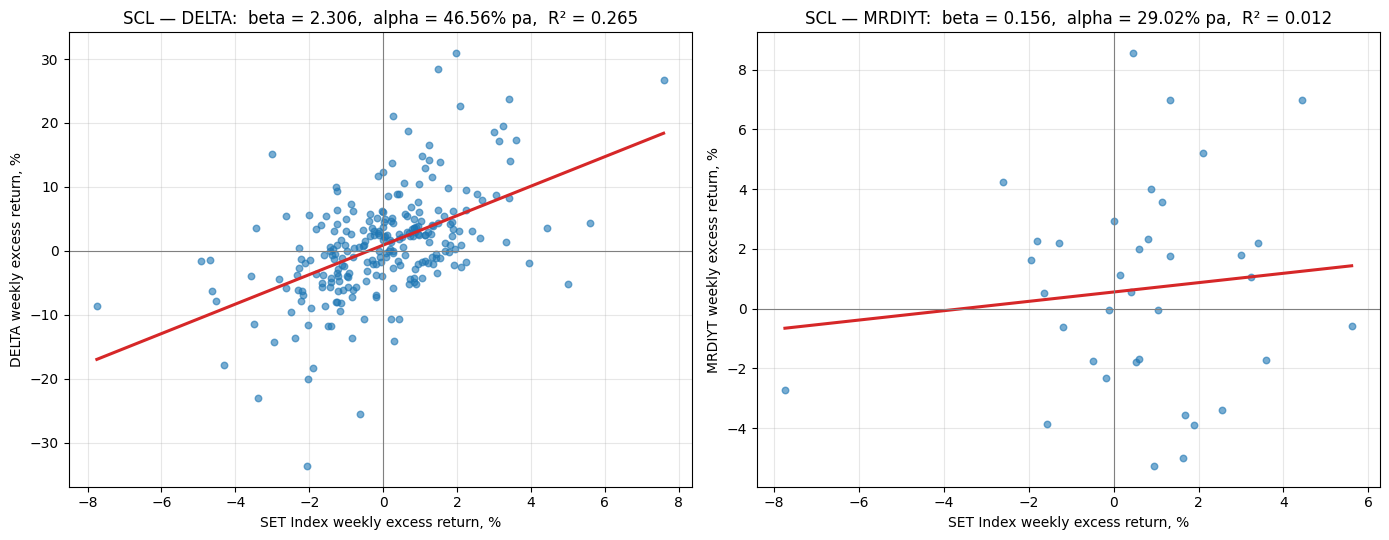

In [29]:
# ============================================================
# IV.5d Two SCL scatter plots: the highest- and lowest-beta names
# ============================================================
hi, lo = sim_tbl.beta.idxmax(), sim_tbl.beta.idxmin()
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, sym in zip(axes, [hi, lo]):
    tic = universe.set_index("symbol").loc[sym, "yf_ticker"]
    s = pd.concat([rets[tic] - RF_WEEKLY, rets[MARKET] - RF_WEEKLY], axis=1).dropna()
    x, y = s.iloc[:, 1] * 100, s.iloc[:, 0] * 100
    a, b = sim_tbl.loc[sym, "alpha_ann"] / PERIODS_PER_YEAR * 100, sim_tbl.loc[sym, "beta"]
    ax.scatter(x, y, s=22, alpha=0.6, color="tab:blue")
    xs = np.linspace(x.min(), x.max(), 20)
    ax.plot(xs, a + b * xs, color="tab:red", lw=2.2)
    ax.axhline(0, color="grey", lw=0.8); ax.axvline(0, color="grey", lw=0.8)
    ax.set(xlabel="SET Index weekly excess return, %", ylabel=f"{sym} weekly excess return, %",
           title=f"SCL — {sym}:  beta = {b:.3f},  alpha = {sim_tbl.loc[sym,'alpha_ann']:.2%} pa,  "
                 f"R² = {sim_tbl.loc[sym,'r2']:.3f}")
plt.tight_layout(); plt.show()

## IV.6 Three covariance estimators

The optimiser needs $V$. We build three and compare them, because with $N=100$ this choice matters
more than anything else in the exercise.

1. **Sample covariance** $S$ — pairwise-complete because of the ragged history, then projected to the
   nearest positive semi-definite matrix. Free of model error, full of estimation error.
2. **SIM covariance** $V_{SIM}=\sigma_M^2\boldsymbol\beta\boldsymbol\beta^\top+\mathrm{diag}(\sigma_{\varepsilon i}^2)$ —
   only 302 estimates, guaranteed PSD, but imposes that the index is the *only* source of co-movement
   (it cannot see, say, a bank-sector factor).
3. **Shrinkage** $V_\delta=(1-\delta)S+\delta V_{SIM}$ — the Ledoit–Wolf compromise: the sample matrix
   pulled toward the structured target.

The diagnostic that matters is the **condition number** $\lambda_{max}/\lambda_{min}$. Optimisation
involves $V^{-1}$, so a large condition number means small estimation errors get amplified into wild
weights — the "error maximisation" problem that makes naive Markowitz portfolios unusable.

In [30]:
# ============================================================
# IV.6 Building and diagnosing the three covariance matrices
# ============================================================
def nearest_psd(A, eps=1e-10):
    # Symmetrise, then clip negative eigenvalues to eps.
    A = (np.asarray(A, float) + np.asarray(A, float).T) / 2.0
    vals, vecs = np.linalg.eigh(A)
    return vecs @ np.diag(np.clip(vals, eps, None)) @ vecs.T

def cov_diagnostics(V, label):
    ev = np.linalg.eigvalsh(V)
    psd = bool(ev.min() > -1e-12)
    return {"estimator": label,
            "min eigenvalue": f"{ev.min():.3e}", "max eigenvalue": f"{ev.max():.3e}",
            "negative eigenvalues": int((ev < -1e-12).sum()),
            "condition number": "not defined (indefinite)" if not psd else f"{ev.max()/max(ev.min(), 1e-30):.3e}",
            "PSD?": psd}

# 1. sample
S_raw = (rets[TICKERS].cov(min_periods=MIN_OBS) * PERIODS_PER_YEAR)
S_raw = S_raw.fillna(0.0).values
V_sample = nearest_psd(S_raw)

# 2. SIM
betas = sim_tbl.beta.values
sig_eps = sim_tbl.sigma_eps_ann.values
V_sim = sim_covariance(betas, sig_eps, sd_M)

# 3. shrinkage
SHRINK = 0.50
V_shrunk = (1 - SHRINK) * V_sample + SHRINK * V_sim

diag = pd.DataFrame([cov_diagnostics(S_raw, "Sample (raw, pairwise)"),
                     cov_diagnostics(V_sample, "Sample (PSD-repaired)"),
                     cov_diagnostics(V_sim, "Single Index Model"),
                     cov_diagnostics(V_shrunk, f"Shrunk to SIM (delta = {SHRINK})")]).set_index("estimator")
display(diag)

ev_raw = np.linalg.eigvalsh(S_raw)
print(f"\nThe raw pairwise sample matrix is NOT positive semi-definite: {int((ev_raw < -1e-12).sum())} "
      f"negative eigenvalues, the smallest {ev_raw.min():.4f}.")
print("That is precisely the failure Topic 5 warns about — inconsistent estimates can imply a")
print("negative portfolio 'variance'. After repair it is PSD but still nearly singular, so V^-1")
print("amplifies estimation error. The SIM matrix is PSD by construction and roughly eight orders")
print("of magnitude better conditioned, which is why it is the workhorse below.\n")

off_sim = V_sim[~np.eye(100, dtype=bool)]
off_smp = V_sample[~np.eye(100, dtype=bool)]
print(f"Average off-diagonal covariance — sample: {off_smp.mean():.6f}, SIM: {off_sim.mean():.6f}")
print(f"Correlation between the two sets of covariances: {np.corrcoef(off_smp, off_sim)[0,1]:.4f}")

,min eigenvalue,max eigenvalue,negative eigenvalues,condition number,PSD?
estimator,,,,,
"Sample (raw, pairwise)",-1.093e-01,2.974e+00,4,not defined (indefinite),False
Sample (PSD-repaired),1.000e-10,2.974e+00,0,2.974e+10,True
Single Index Model,6.559e-03,2.626e+00,0,4.004e+02,True
Shrunk to SIM (delta = 0.5),5.570e-03,2.730e+00,0,4.902e+02,True



The raw pairwise sample matrix is NOT positive semi-definite: 4 negative eigenvalues, the smallest -0.1093.
That is precisely the failure Topic 5 warns about — inconsistent estimates can imply a
negative portfolio 'variance'. After repair it is PSD but still nearly singular, so V^-1
amplifies estimation error. The SIM matrix is PSD by construction and roughly eight orders
of magnitude better conditioned, which is why it is the workhorse below.

Average off-diagonal covariance — sample: 0.022457, SIM: 0.017192
Correlation between the two sets of covariances: 0.6607


## IV.7 The efficient frontier of the SET100

Now the Topic 4 program, over all 100 names:

$$\min_{\mathbf w}\;\mathbf w^\top V\mathbf w
\quad\text{s.t.}\quad \mathbf w^\top\mathbf r=\mu_p,\;\;\mathbf w^\top\mathbf 1=1,\;\;w_i\ge0$$

Short sales are banned (the realistic constraint for most Thai institutional mandates and the case
the lecture's optimisation slide sets out), so the frontier is traced numerically. We then find the
GMV portfolio, the tangency portfolio that maximises $SR_P=(E[r_P]-r_F)/\sigma_P$, and the optimal
complete portfolio $y^*=(E[r_P]-r_F)/(A\sigma_P^2)$.

In [31]:
# ============================================================
# IV.7 Frontier, GMV and tangency portfolio over all 100 stocks
# ============================================================
mu_vec = (mu_weekly * PERIODS_PER_YEAR).values          # annualised historical means
sym_index = universe.symbol.values

frontiers, key_ports = {}, {}
for label, V in [("Single Index Model", V_sim), (f"Shrunk (delta={SHRINK})", V_shrunk),
                 ("Sample (PSD-repaired)", V_sample)]:
    fr, _ = frontier_long_only(mu_vec, V, n_points=30)
    w_gmv = min_var_long_only(mu_vec, V)
    w_tan = max_sharpe_long_only(mu_vec, V, RF_ANNUAL)
    m_g, s_g = port_moments(w_gmv, mu_vec, V)
    m_t, s_t = port_moments(w_tan, mu_vec, V)
    frontiers[label] = fr
    key_ports[label] = {"w_gmv": w_gmv, "w_tan": w_tan,
                        "gmv": (m_g, s_g), "tan": (m_t, s_t),
                        "sharpe": (m_t - RF_ANNUAL) / s_t,
                        "n_held": int((w_tan > 1e-4).sum())}

summary = pd.DataFrame({
    lab: {"GMV E[r]": v["gmv"][0], "GMV SD": v["gmv"][1],
          "Tangency E[r]": v["tan"][0], "Tangency SD": v["tan"][1],
          "Tangency Sharpe": v["sharpe"], "stocks held (tangency)": v["n_held"]}
    for lab, v in key_ports.items()}).T
display(summary.round(4))

print(f"\nFor reference the SET Index itself: E[r] = {mu_M:.4%}, SD = {sd_M:.4%}, "
      f"Sharpe = {(mu_M - RF_ANNUAL)/sd_M:.4f}")

,GMV E[r],GMV SD,Tangency E[r],Tangency SD,Tangency Sharpe,stocks held (tangency)
Single Index Model,0.140300,0.070200,0.245200,0.086600,2.629000,18.000000
Shrunk (delta=0.5),0.130000,0.074200,0.247100,0.096600,2.376800,16.000000
Sample (PSD-repaired),0.128300,0.075300,0.249400,0.101600,2.282800,16.000000



For reference the SET Index itself: E[r] = 0.9223%, SD = 13.2586%, Sharpe = -0.0624


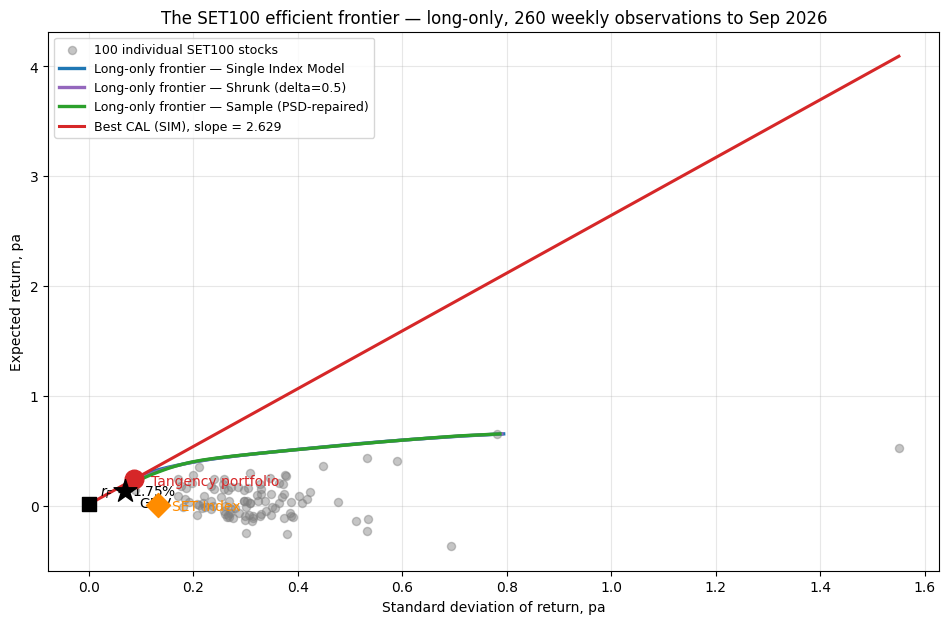

In [32]:
# ============================================================
# IV.7b The picture: 100 stocks, three frontiers, the best CAL
# ============================================================
fig, ax = plt.subplots(figsize=(11.5, 7))

ax.scatter(stats_tbl["SD pa"], stats_tbl["E[r] pa"], s=34, alpha=0.45, color="grey",
           label="100 individual SET100 stocks")
cols = {"Single Index Model": "tab:blue", f"Shrunk (delta={SHRINK})": "tab:purple",
        "Sample (PSD-repaired)": "tab:green"}
for lab, fr in frontiers.items():
    ax.plot(fr.sd, fr.mu, lw=2.4, color=cols[lab], label=f"Long-only frontier — {lab}")

best = key_ports["Single Index Model"]
m_t, s_t = best["tan"]
cal_x = np.linspace(0, max(stats_tbl["SD pa"].max(), s_t * 1.6), 50)
ax.plot(cal_x, RF_ANNUAL + best["sharpe"] * cal_x, color="tab:red", lw=2.2, ls="-",
        label=f"Best CAL (SIM), slope = {best['sharpe']:.3f}")
ax.scatter(0, RF_ANNUAL, marker="s", s=90, color="black", zorder=7)
ax.annotate(f"$r_F$ = {RF_ANNUAL:.2%}", (0, RF_ANNUAL), xytext=(8, 6), textcoords="offset points")
ax.scatter(s_t, m_t, s=180, color="tab:red", zorder=8, marker="o")
ax.annotate("Tangency portfolio", (s_t, m_t), xytext=(12, -4), textcoords="offset points", color="tab:red")
g_m, g_s = best["gmv"]
ax.scatter(g_s, g_m, marker="*", s=300, color="black", zorder=8)
ax.annotate("GMV", (g_s, g_m), xytext=(10, -12), textcoords="offset points")
ax.scatter(sd_M, mu_M, marker="D", s=150, color="darkorange", zorder=8)
ax.annotate("SET Index", (sd_M, mu_M), xytext=(10, -4), textcoords="offset points", color="darkorange")

ax.set(xlabel="Standard deviation of return, pa", ylabel="Expected return, pa",
       title=f"The SET100 efficient frontier — long-only, {len(rets)} weekly observations "
             f"to {DATA_END:%b %Y}")
ax.legend(loc="upper left", fontsize=9); plt.show()

In [33]:
# ============================================================
# IV.7c The optimal risky portfolio — and why a position cap is needed
# ============================================================
WEIGHT_CAP = 0.10

w_tan_uncapped = key_ports["Single Index Model"]["w_tan"]
w_tan_capped = max_sharpe_long_only(mu_vec, V_sim, RF_ANNUAL, cap=WEIGHT_CAP)

def describe(w, V, label):
    m, s = port_moments(w, mu_vec, V)
    return {"portfolio": label, "E[r] pa": m, "SD pa": s, "Sharpe": (m - RF_ANNUAL) / s,
            "beta": float(w @ betas), "stocks held": int((w > 1e-4).sum()),
            "largest weight": float(w.max()), "top-5 concentration": float(np.sort(w)[::-1][:5].sum())}

w_eq = np.repeat(1 / 100, 100)
compare = pd.DataFrame([
    describe(w_tan_uncapped, V_sim, "Tangency (uncapped)"),
    describe(w_tan_capped, V_sim, f"Tangency (cap {WEIGHT_CAP:.0%})"),
    describe(key_ports["Single Index Model"]["w_gmv"], V_sim, "GMV"),
    describe(w_eq, V_sim, "Equally weighted (1/100)"),
]).set_index("portfolio")
display(compare.round(4))

weights = pd.DataFrame({"uncapped": w_tan_uncapped, f"cap {WEIGHT_CAP:.0%}": w_tan_capped,
                        "GMV": key_ports["Single Index Model"]["w_gmv"]}, index=sym_index)
weights["sector"] = universe.sector.values
weights["obs"] = coverage.obs.values
weights["beta"] = sim_tbl.beta.reindex(sym_index).values
weights["alpha pa"] = sim_tbl.alpha_ann.reindex(sym_index).values

print(f"\nOPTIMAL RISKY PORTFOLIO — long-only, SIM covariance, position cap {WEIGHT_CAP:.0%}")
top = weights[weights[f"cap {WEIGHT_CAP:.0%}"] > 1e-4].sort_values(f"cap {WEIGHT_CAP:.0%}", ascending=False)
display(top[[f"cap {WEIGHT_CAP:.0%}", "uncapped", "sector", "beta", "alpha pa", "obs"]].round(4))
print(f"Total weight: {top[f'cap {WEIGHT_CAP:.0%}'].sum():.6f}")

print("\nSector allocation of the capped optimal portfolio")
display(top.groupby("sector")[f"cap {WEIGHT_CAP:.0%}"].sum().sort_values(ascending=False).to_frame("weight").round(4))

,E[r] pa,SD pa,Sharpe,beta,stocks held,largest weight,top-5 concentration
portfolio,,,,,,,
Tangency (uncapped),0.245200,0.086600,2.629000,0.487800,18,0.264000,0.762200
Tangency (cap 10%),0.249300,0.092800,2.498300,0.548800,20,0.100000,0.495000
GMV,0.140300,0.070200,1.749700,0.397800,25,0.444300,0.674000
Equally weighted (1/100),0.063200,0.135500,0.337400,0.989600,100,0.010000,0.050000



OPTIMAL RISKY PORTFOLIO — long-only, SIM covariance, position cap 10%


,cap 10%,uncapped,sector,beta,alpha pa,obs
TTB,0.100000,0.117000,Finance,0.582600,0.259800,260
TISCO,0.100000,0.264000,Finance,0.291300,0.137500,260
TCAP,0.100000,0.167800,Finance,0.435100,0.210200,260
KTB,0.100000,0.145600,Finance,0.667400,0.340600,260
MRDIYT,0.095000,0.067800,Retail Trade,0.156400,0.290200,43
SCB,0.084600,0.059700,Finance,0.421000,0.251600,228
ADVANC,0.067000,0.019200,Communications,0.595100,0.192300,260
KBANK,0.066100,0.026900,Finance,0.655700,0.195800,260
KKP,0.049000,0.020500,Finance,0.766600,0.218600,260
PTTEP,0.041300,0.018600,Energy Minerals,0.422000,0.137600,260


Total weight: 1.000000

Sector allocation of the capped optimal portfolio


,weight
sector,
Finance,0.654400
Retail Trade,0.108700
Communications,0.100400
Energy Minerals,0.045000
Process Industries,0.038200
Industrial Services,0.019200
Health Services,0.016600
Electronic Technology,0.015500
Transportation,0.002000


The uncapped tangency portfolio piles into a handful of names — the classic **error-maximisation**
result. The optimiser cannot distinguish a genuinely high expected return from a lucky five-year
sample, so it treats estimation noise as signal and concentrates. Note in particular any name whose
`obs` count is far below the full window: its mean and beta come from a short, noisy history and it
should not carry a large weight on that evidence. The 10% cap is the standard practical remedy and is
what makes the portfolio below deliverable.

In [34]:
# ============================================================
# IV.7d Capital allocation: from the risky portfolio to the complete portfolio
# ============================================================
m_star, s_star = port_moments(w_tan_capped, mu_vec, V_sim)
sr_star = (m_star - RF_ANNUAL) / s_star
print(f"Optimal risky portfolio P: E[r] = {m_star:.4%}, SD = {s_star:.4%}, Sharpe = {sr_star:.4f}\n")

def allocation_table(mu_p, sd_p, label, y_max=None):
    rows = []
    for A in [1.5, 2, 3, 4, 6, 8]:
        y = optimal_y(mu_p, sd_p, RF_ANNUAL, A)
        y_used = y if y_max is None else min(y, y_max)
        mc, sc = RF_ANNUAL + y_used * (mu_p - RF_ANNUAL), y_used * sd_p
        rows.append({"risk aversion A": A, "y* (unconstrained)": y, "y used": y_used,
                     "1-y in rF": 1 - y_used, "E[r_C]": mc, "SD_C": sc,
                     "U = E[r]-0.5A sd^2": mv_utility(mc, sc, A)})
    print(label)
    display(pd.DataFrame(rows).set_index("risk aversion A").round(4))

# A second input set, used for comparison: CAPM-implied expected returns with every alpha
# set to zero, E[r_i] = rF + beta_i * MRP_FORWARD.  (Its holdings are examined in IV.8d.)
mu_capm = RF_ANNUAL + betas * MRP_FORWARD
w_capm = max_sharpe_long_only(mu_capm, V_sim, RF_ANNUAL, cap=WEIGHT_CAP)
m_capm_p, s_capm_p = port_moments(w_capm, mu_capm, V_sim)

allocation_table(m_star, s_star, "(a) Using the in-sample tangency portfolio — note what happens:")

print("Those y* values are nonsense: an in-sample Sharpe ratio this high tells the formula to lever")
print("many times over even for a risk-averse investor. The mathematics is right; the INPUT is wrong.")
print("y* = (E[r_P]-rF)/(A sigma_P^2) is very sensitive to E[r_P], and an in-sample-optimised expected")
print("return is inflated by exactly the estimation error the optimiser was chasing. Two disciplines")
print("fix it: expected returns that were not fitted to this sample, and a leverage limit.\n")

allocation_table(m_capm_p, s_capm_p,
                 "(b) Using the CAPM-implied portfolio from IV.8d (alphas set to zero), y capped at 1.5:",
                 y_max=1.5)

# Sensitivity of the tangency portfolio to the assumed risk-free rate
sens = []
for rf_try in [0.005, 0.0175, 0.03, 0.045]:
    w_try = max_sharpe_long_only(mu_vec, V_sim, rf_try, cap=WEIGHT_CAP)
    m_, s_ = port_moments(w_try, mu_vec, V_sim)
    overlap = float(np.minimum(w_try, w_tan_capped).sum())
    sens.append({"rF assumed": rf_try, "E[r_P]": m_, "SD_P": s_, "Sharpe": (m_ - rf_try) / s_,
                 "stocks held": int((w_try > 1e-4).sum()), "overlap with base case": overlap})
print("\nSensitivity of the optimal risky portfolio to the assumed risk-free rate")
display(pd.DataFrame(sens).set_index("rF assumed").round(4))

Optimal risky portfolio P: E[r] = 24.9330%, SD = 9.2797%, Sharpe = 2.4983

(a) Using the in-sample tangency portfolio — note what happens:


,y* (unconstrained),y used,1-y in rF,E[r_C],SD_C,U = E[r]-0.5A sd^2
risk aversion A,,,,,,
1.500000,17.947800,17.947800,-16.947800,4.178300,1.665500,2.097900
2.000000,13.460900,13.460900,-12.460900,3.138100,1.249100,1.577800
3.000000,8.973900,8.973900,-7.973900,2.097900,0.832800,1.057700
4.000000,6.730400,6.730400,-5.730400,1.577800,0.624600,0.797700
6.000000,4.487000,4.487000,-3.487000,1.057700,0.416400,0.537600
8.000000,3.365200,3.365200,-2.365200,0.797700,0.312300,0.407600


Those y* values are nonsense: an in-sample Sharpe ratio this high tells the formula to lever
many times over even for a risk-averse investor. The mathematics is right; the INPUT is wrong.
y* = (E[r_P]-rF)/(A sigma_P^2) is very sensitive to E[r_P], and an in-sample-optimised expected
return is inflated by exactly the estimation error the optimiser was chasing. Two disciplines
fix it: expected returns that were not fitted to this sample, and a leverage limit.

(b) Using the CAPM-implied portfolio from IV.8d (alphas set to zero), y capped at 1.5:


,y* (unconstrained),y used,1-y in rF,E[r_C],SD_C,U = E[r]-0.5A sd^2
risk aversion A,,,,,,
1.500000,2.270500,1.500000,-0.500000,0.104100,0.195300,0.075500
2.000000,1.702900,1.500000,-0.500000,0.104100,0.195300,0.066000
3.000000,1.135300,1.135300,-0.135300,0.083000,0.147800,0.050300
4.000000,0.851500,0.851500,0.148500,0.066700,0.110900,0.042100
6.000000,0.567600,0.567600,0.432400,0.050300,0.073900,0.033900
8.000000,0.425700,0.425700,0.574300,0.042100,0.055400,0.029800



Sensitivity of the optimal risky portfolio to the assumed risk-free rate


,E[r_P],SD_P,Sharpe,stocks held,overlap with base case
rF assumed,,,,,
0.005000,0.247300,0.092000,2.633600,20,0.989600
0.017500,0.249300,0.092800,2.498300,20,1.000000
0.030000,0.251700,0.093800,2.364200,20,0.988200
0.045000,0.254900,0.095200,2.205400,20,0.971800


## IV.8 Treynor–Black: splitting the portfolio into passive and active parts

Instead of feeding raw historical means to the optimiser, the Treynor–Black route takes the CAPM
seriously: expected returns are $r_F+\beta_i(E[r_M]-r_F)$ **plus** whatever alpha the analyst
believes in. The optimal risky portfolio is then a passive holding of the index plus an active
portfolio built from alphas, with

$$w_i^{A}\propto\frac{\alpha_i}{\sigma_{\varepsilon i}^2},\qquad
w_A^0=\frac{\alpha_A/\sigma_{\varepsilon A}^2}{E[R_M]/\sigma_M^2},\qquad
w_A^*=\frac{w_A^0}{1+(1-\beta_A)w_A^0}$$

One honest complication before we start: over this window the *realised* SET Index excess return is
negative, so a mechanical $E[R_M]$ would make the exercise meaningless (it would say "short the
market"). Realised returns are a famously poor forecast of the equity premium, so we use a
**forward-looking market risk premium** — a standard practitioner input — and report the realised
figure beside it.

The result below is deliberately left in its raw form first, because **it comes out absurd**, and
the reason it does is the most useful thing in this section.

In [35]:
# ============================================================
# IV.8 Treynor-Black active portfolio on the SET100 alphas
# ============================================================
realised_mrp = mu_M - RF_ANNUAL
print(f"Realised market risk premium over the window : {realised_mrp:+.4%} pa")
print(f"Forward-looking assumption used below        : {MRP_FORWARD:+.4%} pa\n")

# Only names with a credible alpha signal enter the active portfolio.
active_pool = sim_tbl[(sim_tbl.p_alpha < 0.10) & (sim_tbl.n >= 104)]
print(f"Active pool: {len(active_pool)} names with |t(alpha)| significant at 10% and >= 2y history")

tb = treynor_black(active_pool.alpha_ann.values, active_pool.beta.values,
                   active_pool.sigma_eps_ann.values, MRP_FORWARD, sd_M)

act = pd.DataFrame({"weight in active portfolio": tb["w_active"],
                    "alpha pa": active_pool.alpha_ann.values,
                    "sigma_eps pa": active_pool.sigma_eps_ann.values,
                    "beta": active_pool.beta.values,
                    "info ratio": active_pool.info_ratio.values},
                   index=active_pool.index).sort_values("weight in active portfolio", ascending=False)
display(act.round(4))

print(f"\nActive portfolio : alpha_A = {tb['alpha_A']:.4%}, beta_A = {tb['beta_A']:.4f}, "
      f"sigma_eps_A = {tb['sig_eps_A']:.4%}")
print(f"Information ratio = {tb['info_ratio']:.4f}")
print(f"Unconstrained weight on the active portfolio w_A* = {tb['w_A']:.4f}  "
      f"(implied passive index weight = {1 - tb['w_A']:.4f})")
print(f"Sharpe of the index (passive) = {tb['sharpe_M']:.4f}   "
      f"Treynor-Black portfolio = {tb['sharpe_P']:.4f}")
print(f"Identity check  SR_P^2 = SR_M^2 + IR^2 : {tb['sharpe_P']**2:.6f} vs "
      f"{tb['sharpe_M']**2 + tb['info_ratio']**2:.6f}")

print("\nSTOP AND LOOK AT THAT RESULT. An information ratio near 4.6, and w_A* > 1 meaning 'short the")
print("index to lever the active book', is not a discovery. It is two modelling failures compounding:")
print("  1. Selection bias — the alphas were picked for significance on the SAME data that scores them.")
print("  2. The SIM assumes Cov[eps_i, eps_j] = 0, which is what drives sigma_eps_A towards zero as")
print("     names are added. The next cell tests whether that assumption actually holds.")

Realised market risk premium over the window : -0.8277% pa
Forward-looking assumption used below        : +6.0000% pa

Active pool: 16 names with |t(alpha)| significant at 10% and >= 2y history


,weight in active portfolio,alpha pa,sigma_eps pa,beta,info ratio
TISCO,0.242200,0.137500,0.080700,0.291300,1.705200
KTB,0.105900,0.340600,0.191900,0.667400,1.774600
TCAP,0.104600,0.210200,0.151700,0.435100,1.385500
TTB,0.091400,0.259800,0.180400,0.582600,1.440000
ADVANC,0.087200,0.192300,0.158900,0.595100,1.210300
KBANK,0.070000,0.195800,0.179100,0.655700,1.093700
BBL,0.069400,0.171200,0.168100,0.606000,1.018400
KKP,0.056500,0.218600,0.210600,0.766600,1.037900
WHAUP,0.046400,0.216500,0.231200,0.899200,0.936100
SCB,0.043700,0.251600,0.256700,0.421000,0.980000



Active portfolio : alpha_A = 23.9796%, beta_A = 0.5924, sigma_eps_A = 5.2412%
Information ratio = 4.5752
Unconstrained weight on the active portfolio w_A* = 2.2384  (implied passive index weight = -1.2384)
Sharpe of the index (passive) = 0.4525   Treynor-Black portfolio = 4.5975
Identity check  SR_P^2 = SR_M^2 + IR^2 : 21.137299 vs 21.137299

STOP AND LOOK AT THAT RESULT. An information ratio near 4.6, and w_A* > 1 meaning 'short the
index to lever the active book', is not a discovery. It is two modelling failures compounding:
  1. Selection bias — the alphas were picked for significance on the SAME data that scores them.
  2. The SIM assumes Cov[eps_i, eps_j] = 0, which is what drives sigma_eps_A towards zero as
     names are added. The next cell tests whether that assumption actually holds.


Residual correlations across the 16 active names:
  mean +0.0592   median +0.0217   max +0.5324   min -0.2689
  pairs with |corr| > 0.30 : 30 of 240

  Among the 9 Finance names alone, mean residual correlation = +0.2496  <-- the SIM says this should be 0
  Thai banks share a sector factor the SET Index does not span, so their SCL residuals
  move together. The single-index assumption fails precisely where the optimiser is
  concentrating the portfolio.


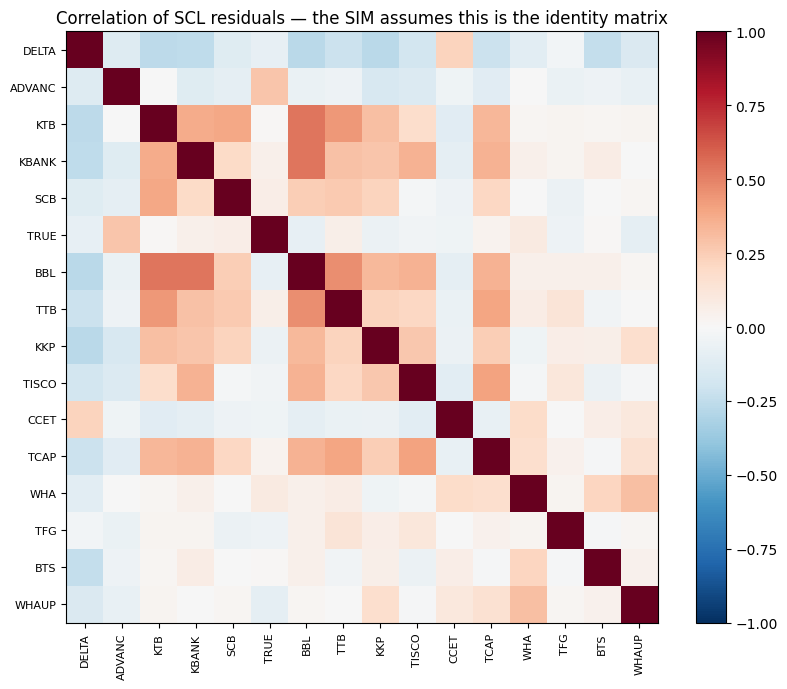

sigma_eps_A assuming independent residuals (the SIM) : 5.2412%
sigma_eps_A using the true residual covariance       : 7.6923%
Information ratio falls from 4.5752 to 3.1173 once that correlation is admitted.



In [36]:
# ============================================================
# IV.8b Does the SIM's Cov[eps_i, eps_j] = 0 assumption survive?
# ============================================================
# Rebuild residuals for the active-pool names and look at their correlation matrix.
resid = {}
for sym in active_pool.index:
    tic = universe.set_index("symbol").loc[sym, "yf_ticker"]
    s_ = pd.concat([rets[tic] - RF_WEEKLY, rets[MARKET] - RF_WEEKLY], axis=1).dropna()
    y, x = s_.iloc[:, 0].values, s_.iloc[:, 1].values
    X = np.column_stack([np.ones(len(x)), x])
    co, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid[sym] = pd.Series(y - X @ co, index=s_.index)

E = pd.DataFrame(resid)
C = E.corr()
off_r = C.values[~np.eye(len(C), dtype=bool)]
print(f"Residual correlations across the {len(C)} active names:")
print(f"  mean {off_r.mean():+.4f}   median {np.median(off_r):+.4f}   "
      f"max {off_r.max():+.4f}   min {off_r.min():+.4f}")
print(f"  pairs with |corr| > 0.30 : {(np.abs(off_r) > 0.30).sum()} of {len(off_r)}")

fin = [c for c in C.columns if universe.set_index("symbol").loc[c, "sector"] == "Finance"]
if len(fin) > 1:
    sub = C.loc[fin, fin].values
    print(f"\n  Among the {len(fin)} Finance names alone, mean residual correlation = "
          f"{sub[~np.eye(len(fin), dtype=bool)].mean():+.4f}  <-- the SIM says this should be 0")
    print("  Thai banks share a sector factor the SET Index does not span, so their SCL residuals")
    print("  move together. The single-index assumption fails precisely where the optimiser is")
    print("  concentrating the portfolio.")

fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(C.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(C))); ax.set_xticklabels(C.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(C))); ax.set_yticklabels(C.index, fontsize=8)
ax.set_title("Correlation of SCL residuals — the SIM assumes this is the identity matrix")
plt.colorbar(im, fraction=0.046); ax.grid(False); plt.tight_layout(); plt.show()

# Residual risk of the active portfolio computed from the TRUE residual covariance.
w_act = tb["w_active"]
Sigma_e = E.cov().values * PERIODS_PER_YEAR
sig_eps_A_true = float(np.sqrt(w_act @ Sigma_e @ w_act))
print(f"sigma_eps_A assuming independent residuals (the SIM) : {tb['sig_eps_A']:.4%}")
print(f"sigma_eps_A using the true residual covariance       : {sig_eps_A_true:.4%}")
print(f"Information ratio falls from {tb['info_ratio']:.4f} to "
      f"{tb['alpha_A'] / sig_eps_A_true:.4f} once that correlation is admitted.\n")

Correcting the residual covariance shrinks the information ratio, but it is still implausibly high
and $w_A^*$ is still pinned at its ceiling. The remaining problem is the **alphas themselves**: they
were measured on, and selected from, the same 260 weeks used to score them, so they contain far more
luck than skill.

The standard remedy (Treynor–Black with adjusted alphas) is to shrink every forecast toward zero by
the fraction of it you actually believe:

$$\alpha_i^{adj}=\phi\,\hat\alpha_i,\qquad 0\le\phi\le1$$

where $\phi$ is the squared correlation between past and future alphas — empirically small.
Because $w_A^0$ is linear in $\alpha_A$, the active position scales directly with $\phi$.

In [37]:
# ============================================================
# IV.8c Alpha shrinkage — how much of the tilt survives honest scepticism?
# ============================================================
rows = []
for phi in [1.00, 0.50, 0.25, 0.10, 0.05]:
    alpha_A_adj = tb["alpha_A"] * phi
    ir_adj = alpha_A_adj / sig_eps_A_true
    w0 = (alpha_A_adj / sig_eps_A_true ** 2) / (MRP_FORWARD / sd_M ** 2)
    wA = w0 / (1 + (1 - tb["beta_A"]) * w0)
    wA = float(np.clip(wA, 0.0, 1.0))
    sr_p = np.sqrt((MRP_FORWARD / sd_M) ** 2 + ir_adj ** 2)
    rows.append({"belief phi": phi, "adjusted alpha_A": alpha_A_adj, "information ratio": ir_adj,
                 "w_A (active)": wA, "1-w_A (passive index)": 1 - wA,
                 "implied Sharpe of P": sr_p})
shrunk_tb = pd.DataFrame(rows).set_index("belief phi")
display(shrunk_tb.round(4))

print(f"Sharpe of the passive index alone (forward-looking) = {MRP_FORWARD / sd_M:.4f}")
print("\nEven believing only 10% of the estimated alphas, the model still wants a large active")
print("position — a reminder that Treynor-Black is only as good as the alpha forecasts fed to it.")
print("The section's real lesson is not the weights: it is that IR, and therefore every active")
print("decision, hinges on two things the SIM takes for granted — uncorrelated residuals, and")
print("alphas that are forecasts rather than fitted history.")

,adjusted alpha_A,information ratio,w_A (active),1-w_A (passive index),implied Sharpe of P
belief phi,,,,,
1.000000,0.239800,3.117300,1.000000,0.000000,3.150000
0.500000,0.119900,1.558700,1.000000,0.000000,1.623000
0.250000,0.059900,0.779300,1.000000,0.000000,0.901200
0.100000,0.024000,0.311700,0.800100,0.199900,0.549500
0.050000,0.012000,0.155900,0.478000,0.522000,0.478600


Sharpe of the passive index alone (forward-looking) = 0.4525

Even believing only 10% of the estimated alphas, the model still wants a large active
position — a reminder that Treynor-Black is only as good as the alpha forecasts fed to it.
The section's real lesson is not the weights: it is that IR, and therefore every active
decision, hinges on two things the SIM takes for granted — uncorrelated residuals, and
alphas that are forecasts rather than fitted history.


In [38]:
# ============================================================
# IV.8d The CAPM-consistent portfolio: what if every alpha is really zero?
# ============================================================
# mu_capm / w_capm were built in IV.7d: E[r_i] = rF + beta_i * MRP_FORWARD, all alphas zero.
m_capm, s_capm = m_capm_p, s_capm_p

capm_port = pd.DataFrame({"weight": w_capm, "beta": betas,
                          "sigma_eps pa": sig_eps}, index=sym_index)
capm_port = capm_port[capm_port.weight > 1e-4].sort_values("weight", ascending=False)

print("Optimal risky portfolio when expected returns are CAPM-implied (all alphas set to zero)")
display(capm_port.head(15).round(4))
print(f"Names held: {len(capm_port)}   portfolio beta: {w_capm @ betas:.4f}   "
      f"largest weight: {w_capm.max():.4f}")
print(f"E[r] = {m_capm:.4%}, SD = {s_capm:.4%}, Sharpe = {(m_capm - RF_ANNUAL)/s_capm:.4f}")
print("\nWith no alphas the optimiser has no reason to tilt: it simply buys broad, low-residual-risk")
print("exposure and the portfolio beta sits near 1 — a passive index proxy. That is the CAPM's")
print("central message: without superior information, holding the market is optimal. Every active")
print("tilt in IV.7 is therefore a bet on the historical means being a good forecast.")

Optimal risky portfolio when expected returns are CAPM-implied (all alphas set to zero)


,weight,beta,sigma_eps pa
TISCO,0.031400,0.291300,0.080700
QH,0.022900,0.744100,0.151100
CPALL,0.022700,0.990900,0.175200
GULF,0.021900,1.432600,0.214300
LH,0.021600,0.908700,0.171900
PTT,0.021400,0.660900,0.147400
RATCH,0.020900,0.773600,0.161400
CPN,0.018600,0.898500,0.184100
EGCO,0.017200,0.823000,0.183600
ADVANC,0.016600,0.595100,0.158900


Names held: 100   portfolio beta: 0.9622   largest weight: 0.0314
E[r] = 7.5232%, SD = 13.0197%, Sharpe = 0.4434

With no alphas the optimiser has no reason to tilt: it simply buys broad, low-residual-risk
exposure and the portfolio beta sits near 1 — a passive index proxy. That is the CAPM's
central message: without superior information, holding the market is optimal. Every active
tilt in IV.7 is therefore a bet on the historical means being a good forecast.


## IV.9 Testing the CAPM on the SET100 cross-section

The two-pass procedure from Topic 6 §3.2, run on the 100 constituents:

1. Sort stocks by beta, form 10 equally weighted beta-sorted portfolios.
2. **First pass**: time-series SCL for each portfolio $\to$ $b_P$, $\sigma_{eP}^2$.
3. **Second pass**: cross-sectional regression $\overline{(r_P-r_F)}=\gamma_0+\gamma_1b_P+u_P$,
   plus an extended version adding $b_P^2$ (linearity) and $\sigma_{eP}^2$ (is unsystematic risk
   priced?).

CAPM predictions: $\gamma_0=0$, $\gamma_1=\overline{(r_M-r_F)}>0$, $\gamma_2=\gamma_3=0$.

In [39]:
# ============================================================
# IV.9 Two-pass cross-sectional test
# ============================================================
rets_sym = rets[TICKERS].copy()
rets_sym.columns = sym_index
betas_sorted = sim_tbl.beta.reindex(sym_index)

F, simple, extended = two_pass_capm(rets_sym, rets[MARKET], RF_WEEKLY, betas_sorted,
                                    n_portfolios=10, periods_per_year=PERIODS_PER_YEAR)

print("FIRST PASS — beta-sorted portfolios (annualised)")
display(F.round(4))

print("\nSECOND PASS — simple:  mean excess return = gamma0 + gamma1 * b_P")
display(simple.round(4))
print(f"CAPM predicts gamma0 = 0 and gamma1 = realised market premium = {realised_mrp:.4%}")

print("\nSECOND PASS — extended: + b_P^2 (linearity) + residual variance (is it priced?)")
display(extended.round(4))

FIRST PASS — beta-sorted portfolios (annualised)


,a_P,b_P,sigma_e2,mean_excess,n_stocks
portfolio,,,,,
P1,0.099800,0.449300,0.006500,0.096000,10
P2,0.086900,0.597200,0.010000,0.082000,10
P3,0.111300,0.716600,0.009000,0.105400,10
P4,0.068900,0.829900,0.010200,0.062000,10
P5,0.074700,0.933400,0.011900,0.066900,10
P6,-0.055200,0.997800,0.013000,-0.063500,10
P7,-0.085000,1.111200,0.015200,-0.094200,10
P8,0.029100,1.211100,0.019100,0.019100,10
P9,0.080100,1.362500,0.019900,0.068800,10



SECOND PASS — simple:  mean excess return = gamma0 + gamma1 * b_P


,coef,se,t,p
gamma0,0.115500,0.059600,1.937500,0.088700
gamma1 (beta),-0.081000,0.056500,-1.434600,0.189300


CAPM predicts gamma0 = 0 and gamma1 = realised market premium = -0.8277%

SECOND PASS — extended: + b_P^2 (linearity) + residual variance (is it priced?)


,coef,se,t,p
gamma0,0.395600,0.246300,1.606200,0.159400
gamma1 (beta),-0.679100,0.514900,-1.319000,0.235300
gamma2 (beta^2),0.341900,0.326400,1.047500,0.335200
gamma3 (resid var),-3.852600,6.223200,-0.619100,0.558600


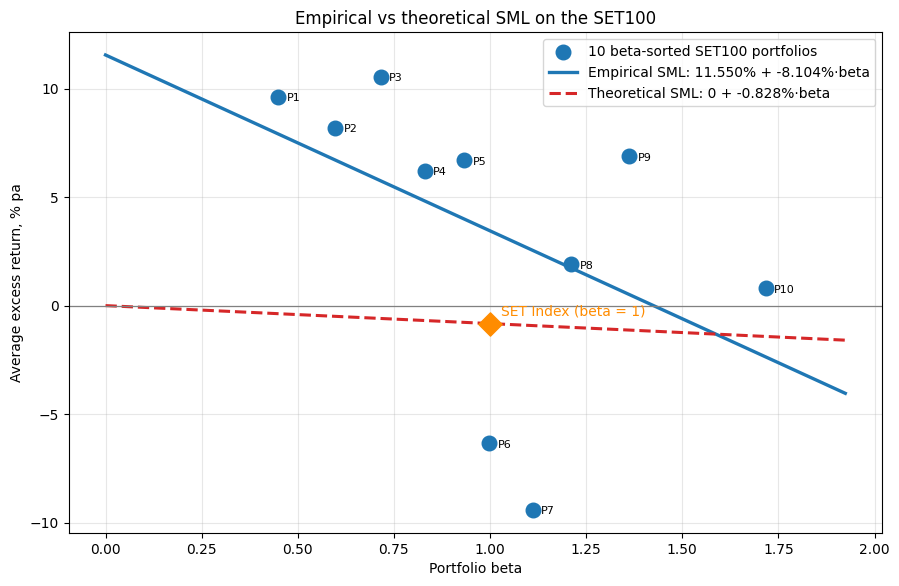

gamma0 = 11.5495% (t = 1.94)  — CAPM says 0
gamma1 = -8.1038% (t = -1.43)  — CAPM says -0.8277%
Cross-sectional R² of the simple second pass: 0.2046


In [40]:
# ============================================================
# IV.9b The empirical SML against the theoretical one
# ============================================================
g0, g1 = simple.loc["gamma0", "coef"], simple.loc["gamma1 (beta)", "coef"]
b_line = np.linspace(0, F.b_P.max() * 1.12, 50)

fig, ax = plt.subplots(figsize=(10.5, 6.5))
ax.scatter(F.b_P, F.mean_excess * 100, s=110, color="tab:blue", zorder=6,
           label="10 beta-sorted SET100 portfolios")
for k, row in F.iterrows():
    ax.annotate(k, (row.b_P, row.mean_excess * 100), xytext=(6, -3), textcoords="offset points", fontsize=8)
ax.plot(b_line, (g0 + g1 * b_line) * 100, color="tab:blue", lw=2.4,
        label=f"Empirical SML: {g0:.3%} + {g1:.3%}·beta")
ax.plot(b_line, (realised_mrp * b_line) * 100, color="tab:red", lw=2.2, ls="--",
        label=f"Theoretical SML: 0 + {realised_mrp:.3%}·beta")
ax.scatter(1.0, realised_mrp * 100, marker="D", s=140, color="darkorange", zorder=7)
ax.annotate("SET Index (beta = 1)", (1.0, realised_mrp * 100), xytext=(8, 6),
            textcoords="offset points", color="darkorange")
ax.axhline(0, color="grey", lw=0.9)
ax.set(xlabel="Portfolio beta", ylabel="Average excess return, % pa",
       title="Empirical vs theoretical SML on the SET100")
ax.legend(); plt.show()

print(f"gamma0 = {g0:.4%} (t = {simple.loc['gamma0','t']:.2f})  — CAPM says 0")
print(f"gamma1 = {g1:.4%} (t = {simple.loc['gamma1 (beta)','t']:.2f})  — CAPM says "
      f"{realised_mrp:.4%}")
print(f"Cross-sectional R² of the simple second pass: "
      f"{np.corrcoef(F.b_P, F.mean_excess)[0,1]**2:.4f}")

### Reading the test

The pattern here is the one the lecture describes: $\gamma_0$ comes out **positive** rather than
zero, and the slope on beta is **far from** the realised market premium — the empirical SML is flat
or inverted rather than tracking the theoretical line. Over this window low-beta SET100 portfolios
earned more than high-beta ones, the same anomaly Black, Jensen and Scholes documented and that
Black's zero-beta model rationalises: with borrowing restricted, risk-tolerant investors bid up
high-beta stocks, depressing their returns and flattening the line.

Two caveats keep this honest. First, five years is a short sample and the realised market premium
over it is itself near zero or negative, so the "true" slope is barely identified — a failure to
recover a premium that did not occur is weak evidence against the model. Second, **Roll's critique**:
`^SET.BK` is a proxy, not the market portfolio of all assets. A rejection here says the proxy is not
mean-variance efficient — it does not, strictly, say anything about the CAPM.

## IV.10 Out-of-sample test: does any of this survive?

In-sample Sharpe ratios are not evidence. The final check re-estimates everything on the **first
three years** and holds the resulting portfolios, untouched, through the **final two years**.

Two points of discipline. The estimation window can only use names that actually traded then, so the
backtest universe is smaller than 100 — using today's 100 names with today's data would be
look-ahead bias. And returns are gross of transaction costs and taxes.

Estimation : 17 Sep 2021 -> 30 Aug 2024  (155 weeks)
Hold-out   : 06 Sep 2024 -> 04 Sep 2026  (105 weeks)

Names with >= 2 years of history inside the estimation window: 93 of 100
(the rest had not listed yet — including them would be look-ahead bias)



,cumulative,annualised,SD pa,Sharpe,max drawdown
"Tangency, SIM, cap 10%",0.706800,0.303100,0.183700,1.554500,-0.104700
"GMV, SIM, cap 10%",0.498900,0.221900,0.292100,0.699800,-0.200300
Equally weighted,0.264800,0.123400,0.189700,0.558300,-0.322700
SET Index (benchmark),0.206000,0.097200,0.159400,0.499900,-0.283400


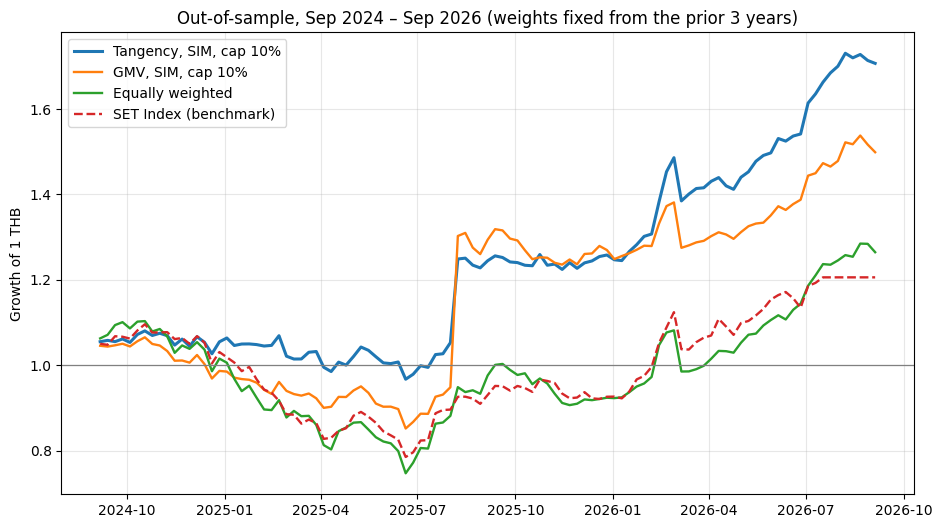

In [41]:
# ============================================================
# IV.10 Out-of-sample backtest
# ============================================================
SPLIT = DATA_END - pd.DateOffset(years=2)
est, hold = rets[rets.index <= SPLIT], rets[rets.index > SPLIT]
print(f"Estimation : {est.index.min():%d %b %Y} -> {est.index.max():%d %b %Y}  ({len(est)} weeks)")
print(f"Hold-out   : {hold.index.min():%d %b %Y} -> {hold.index.max():%d %b %Y}  ({len(hold)} weeks)\n")

def sim_inputs_from(window, tickers, min_obs=104):
    keep, alphas, bts, se2 = [], [], [], []
    for tic in tickers:
        out = run_scl(window[tic], window[MARKET], RF_WEEKLY, PERIODS_PER_YEAR)
        if out is None or out["n"] < min_obs:
            continue
        keep.append(tic); alphas.append(out["alpha_ann"]); bts.append(out["beta"])
        se2.append(out["sigma_eps_ann"] ** 2)
    sM = window[MARKET].std(ddof=1) * np.sqrt(PERIODS_PER_YEAR)
    V = np.outer(bts, bts) * sM ** 2 + np.diag(se2)
    mu = window[keep].mean().values * PERIODS_PER_YEAR
    return keep, mu, V, np.array(alphas), np.array(bts)

keep, mu_e, V_e, alpha_e, beta_e = sim_inputs_from(est, TICKERS)
print(f"Names with >= 2 years of history inside the estimation window: {len(keep)} of 100")
print("(the rest had not listed yet — including them would be look-ahead bias)\n")

w_tan_bt = max_sharpe_long_only(mu_e, V_e, RF_ANNUAL, cap=WEIGHT_CAP)
w_gmv_bt = min_var_long_only(mu_e, V_e, cap=WEIGHT_CAP)
w_eq_bt = np.repeat(1 / len(keep), len(keep))

H = hold[keep].fillna(0.0)
strategies = {
    f"Tangency, SIM, cap {WEIGHT_CAP:.0%}": H @ w_tan_bt,
    f"GMV, SIM, cap {WEIGHT_CAP:.0%}": H @ w_gmv_bt,
    "Equally weighted": H @ w_eq_bt,
    "SET Index (benchmark)": hold[MARKET].fillna(0.0),
}

def perf(r):
    n = len(r)
    cum = float((1 + r).prod() - 1)
    ann = float((1 + r).prod() ** (PERIODS_PER_YEAR / n) - 1)
    sd = float(r.std(ddof=1) * np.sqrt(PERIODS_PER_YEAR))
    dd = float(((1 + r).cumprod() / (1 + r).cumprod().cummax() - 1).min())
    return {"cumulative": cum, "annualised": ann, "SD pa": sd,
            "Sharpe": (ann - RF_ANNUAL) / sd, "max drawdown": dd}

bt = pd.DataFrame({k: perf(v) for k, v in strategies.items()}).T
display(bt.round(4))

fig, ax = plt.subplots(figsize=(11, 6))
for k, v in strategies.items():
    ax.plot(v.index, (1 + v).cumprod(), lw=2.2 if "Tangency" in k else 1.7,
            ls="--" if "SET" in k else "-", label=k)
ax.axhline(1.0, color="grey", lw=0.9)
ax.set(xlabel="", ylabel="Growth of 1 THB",
       title=f"Out-of-sample, {hold.index.min():%b %Y} – {hold.index.max():%b %Y} "
             f"(weights fixed from the prior 3 years)")
ax.legend(); plt.show()

In [42]:
# ============================================================
# IV.10b Was the out-performance skill or just beta?
# ============================================================
oos = []
for k, v in strategies.items():
    if "SET" in k:
        continue
    out = run_scl(v, hold[MARKET], RF_WEEKLY, PERIODS_PER_YEAR)
    oos.append({"strategy": k, "alpha pa": out["alpha_ann"], "t(alpha)": out["t_alpha"],
                "beta": out["beta"], "R²": out["r2"], "n weeks": out["n"]})
display(pd.DataFrame(oos).set_index("strategy").round(4))

print("Jensen's alpha measured out-of-sample against the SET Index — the Topic 6 performance test.")
print("A t-statistic near or below 2 on a two-year sample is not proof of skill: the standard errors")
print("on a 100-week alpha are wide, and one window is one draw.")

,alpha pa,t(alpha),beta,R²,n weeks
strategy,,,,,
"Tangency, SIM, cap 10%",0.196500,1.902200,0.768600,0.448800,98
"GMV, SIM, cap 10%",0.143800,0.738400,0.865300,0.224900,98
Equally weighted,0.018000,0.241000,1.008900,0.728300,98


Jensen's alpha measured out-of-sample against the SET Index — the Topic 6 performance test.
A t-statistic near or below 2 on a two-year sample is not proof of skill: the standard errors
on a 100-week alpha are wide, and one window is one draw.


## IV.11 What the exercise shows

**On the theory.** Every lecture result reproduces on live data. Diversification across the SET100
removes roughly the share of stand-alone risk the $\sigma_p^2=\frac1N\overline{\sigma^2}+\frac{N-1}{N}\overline{\sigma_{i,j}}$
formula predicts, and flattens out near 30 names. The median SET100 stock has most of its variance in
the firm-specific term, so betas alone explain only a modest part of any individual stock — but
enough to rebuild a usable 100×100 covariance matrix from 302 numbers.

**On the estimators.** This is where the practical lesson sits. The raw pairwise sample covariance
was not even positive semi-definite (four negative eigenvalues), and after repair its condition
number was about eight orders of magnitude worse than the SIM's. Topic 5's argument for the Single Index Model is not mainly about
saving arithmetic — it is that the structured estimator is *invertible and stable*, which is what an
optimiser actually needs.

**On the optimal portfolio.** The unconstrained tangency portfolio concentrated in a handful of
names, several with short histories, and posted an in-sample Sharpe ratio that no one should believe.
That is error maximisation, not skill: the optimiser cannot tell a good stock from a lucky one. A
10% position cap turns it into something deliverable, and the capital-allocation step
($y^*=(E[r_P]-r_F)/A\sigma_P^2$) then scales risk to the investor — the separation property doing its
job.

**On active management.** The Treynor–Black section is the cautionary one. Applied mechanically to
in-sample alphas it produced an information ratio near 4.6 and wanted to short the index to lever the
active book. Two assumptions were doing that work: that SCL residuals are uncorrelated — they are
not, Thai bank residuals correlate about +0.25 — and that estimated alphas are forecasts rather than
fitted history. Correcting the first and shrinking the second is what turns the model into something
usable.

**On the CAPM.** The cross-sectional test reproduces the textbook failure: a positive intercept and a
slope unrelated to the realised market premium. Consistent with Black, Jensen and Scholes, and with
Fama–French — and, per Roll, not a clean rejection of the model anyway.

**Limitations worth stating.** Today's index membership applied to a five-year history (survivorship
bias); arithmetic historical means used as forecasts, which is the weakest input in the whole chain;
no transaction costs, taxes, borrowing limits or liquidity constraints; a single out-of-sample window;
and `^SET.BK` standing in for an unobservable market portfolio. The right next steps are
point-in-time index membership, walk-forward re-estimation with turnover costs, and expected-return
inputs that are not just the sample mean — Black–Litterman or a multi-factor model in the spirit of
Fama–French.

---
# Part V — Topic 7: The Arbitrage Pricing Theory

The CAPM reaches equilibrium through **risk–return dominance**: if an asset is mispriced, every
mean-variance investor rebalances a little, and the aggregate of many small trades restores the SML.
Ross's APT reaches equilibrium through **no arbitrage**: if an asset is mispriced, a *few*
arbitrageurs take unlimited positions until the mispricing is gone. The second argument is far
stronger — and it needs neither the market portfolio nor mean-variance preferences.

## 1. Arbitrage and the equilibrium condition

An **arbitrage** is a strategy that (i) requires no net initial investment and (ii) produces a
riskless profit.

| | Price today | Boom (p=0.5) | Bust (p=0.5) |
|---|---|---|---|
| Asset A | 10 | 14 | 8 |
| Asset B | 10 | 15 | 9 |

*(all figures in THB per share)*

Short one A, buy one B: net outlay $-10+10=0$, so $w_P=\sum_iw_i=0$ — a **zero-investment
portfolio** — and the payoff is **+1 in both states**. Free money. Arbitrageurs will short A and buy
B until $P_{0,A}$ falls and $P_{0,B}$ rises far enough that the opportunity disappears.

**Market equilibrium is the state in which no arbitrage opportunity exists.** That single condition
is all the APT needs.

In [43]:
# ============================================================
# 1.1 The arbitrage portfolio from the lecture
# ============================================================
payoff = pd.DataFrame({"price_today": [10.0, 10.0], "boom": [14.0, 15.0], "bust": [8.0, 9.0]},
                      index=["A", "B"])
payoff["E[payoff]"] = 0.5 * payoff.boom + 0.5 * payoff.bust
payoff["E[r]"] = payoff["E[payoff]"] / payoff.price_today - 1
display(payoff)

pos = pd.Series({"A": -1.0, "B": 1.0})          # short 1 A, long 1 B
net_outlay = float(-(pos * payoff.price_today).sum())
print(f"Net initial investment      = {net_outlay:+.2f}   -> zero-investment portfolio")
print(f"Portfolio weight sum        = {float((pos * payoff.price_today / 10).sum()):+.2f}")
for state in ["boom", "bust"]:
    print(f"Payoff in {state:5s}            = {float((pos * payoff[state]).sum()):+.2f}")
print("\nPositive payoff in EVERY state with zero investment and zero risk: an arbitrage.")
print("Arbitrageurs short A and buy B, so P(A) falls and P(B) rises until the gap closes.")

,price_today,boom,bust,E[payoff],E[r]
A,10.000000,14.000000,8.000000,11.000000,0.100000
B,10.000000,15.000000,9.000000,12.000000,0.200000


Net initial investment      = -0.00   -> zero-investment portfolio
Portfolio weight sum        = +0.00
Payoff in boom             = +1.00
Payoff in bust             = +1.00

Positive payoff in EVERY state with zero investment and zero risk: an arbitrage.
Arbitrageurs short A and buy B, so P(A) falls and P(B) rises until the gap closes.


## 2. The factor model behind the APT

The APT assumes returns follow a **K-factor model**:

$$r_i=E[r_i]+\beta_{i,1}f_1+\dots+\beta_{i,K}f_K+\varepsilon_i$$

where $f_k=F_k-E[F_k]$ is the *surprise* in factor $k$ (zero mean by construction), $\beta_{i,k}$ is
the **factor loading** of asset $i$ on factor $k$, and

$$E[\varepsilon_i]=0,\quad \mathrm{Cov}[\varepsilon_i,f_k]=0,\quad
\mathrm{Cov}[\varepsilon_i,\varepsilon_j]=0,\quad \mathrm{Cov}[f_k,f_{k+1}]=0$$

Note the SIM of Topic 5 is exactly the special case $K=1$ with the market as the factor.

Four further assumptions drive the result:

2. Enough securities exist that **well-diversified** portfolios can be built with negligible $\varepsilon$.
3. A diversified portfolio with **no factor exposure** ($\beta_{P,k}=0\;\forall k$) must return $r_F$.
4. **Factor portfolios** exist — portfolios exposed to one factor only.
5. A factor portfolio with **unit loading** ($\beta_{P,k}=1$) earns $E[r_{P_k}]$, so $E[r_{P_k}]-r_F$
   is the risk premium on factor $k$.

In [44]:
# ============================================================
# 2.1 Reading a factor model — the GDP example
# ============================================================
# r_i = 0.10 + 1.2 * f_Y + eps ,  consensus GDP growth = 4%
E_ri, beta_Y, rf_ex7, consensus_Y = 0.10, 1.2, 0.02, 0.04

rows = []
for realised_Y in [0.03, 0.04, 0.05]:
    f_Y = realised_Y - consensus_Y                      # the SURPRISE, not the level
    rows.append({"GDP growth realised": realised_Y, "surprise f_Y": f_Y,
                 "r_i = E[r] + beta*f_Y": E_ri + beta_Y * f_Y})
display(pd.DataFrame(rows).set_index("GDP growth realised").round(4))
print("Only the SURPRISE moves the return. If GDP comes in exactly at consensus, f_Y = 0 and the")
print("stock earns precisely its expected return.\n")

# A two-factor example: a regulated utility.
print("Two-factor model for a regulated power utility:  r_i = E[r_i] + 0.2*f_Y - 0.4*f_IR + eps")
print("  beta_Y  = +0.2 : cash flows barely track the business cycle")
print("  beta_IR = -0.4 : with stable cash flows, a rate rise hurts the value of the business")

,surprise f_Y,r_i = E[r] + beta*f_Y
GDP growth realised,,
0.030000,-0.010000,0.088000
0.040000,0.000000,0.100000
0.050000,0.010000,0.112000


Only the SURPRISE moves the return. If GDP comes in exactly at consensus, f_Y = 0 and the
stock earns precisely its expected return.

Two-factor model for a regulated power utility:  r_i = E[r_i] + 0.2*f_Y - 0.4*f_IR + eps
  beta_Y  = +0.2 : cash flows barely track the business cycle
  beta_IR = -0.4 : with stable cash flows, a rate rise hurts the value of the business


## 3. Deriving the APT

Take a two-factor world and build a portfolio that is simultaneously **zero-investment** and
**zero-beta** on both factors:

$$\sum_iw_i=0,\qquad \sum_iw_i\beta_{i,1}=0,\qquad \sum_iw_i\beta_{i,2}=0$$

Its return is

$$r_P=\sum_iw_iE[r_i]+f_1\underbrace{\sum_iw_i\beta_{i,1}}_{=0}
+f_2\underbrace{\sum_iw_i\beta_{i,2}}_{=0}+\underbrace{\sum_iw_i\varepsilon_i}_{\approx\,0\ \text{if }N\text{ large}}
=\sum_iw_iE[r_i]$$

— riskless, and free. So in equilibrium it must pay nothing: $\sum_iw_iE[r_i]=0$.

In matrix terms, $\mathbf w^\top\mathbf 1=0$, $\mathbf w^\top\boldsymbol\beta_1=0$ and
$\mathbf w^\top\boldsymbol\beta_2=0$ **imply** $\mathbf w^\top E[\mathbf r]=0$. By the linear-algebra
result that a vector orthogonal to $\mathbf 1,\boldsymbol\beta_1,\boldsymbol\beta_2$ is orthogonal to
$E[\mathbf r]$ only if $E[\mathbf r]$ is a linear combination of them:

$$\boxed{\;E[r_i]=\lambda_0+\beta_{i,1}\lambda_1+\beta_{i,2}\lambda_2\;}$$

**Interpreting the $\lambda$'s.** A portfolio with $\sum w_i=1$ and both betas zero gives
$E[r_0]=\lambda_0$, and being riskless, $\lambda_0=r_F$. A portfolio with $\beta_1=1,\beta_2=0$ gives
$E[r_1]=\lambda_0+\lambda_1$, so $\lambda_1=E[r_1]-r_F$ — the risk premium on factor portfolio 1.
Generalising to $K$ factors:

$$E[r_i]=r_F+\sum_{k=1}^{K}\beta_{i,k}\big(E[r_k]-r_F\big)
=r_F+\sum_{k=1}^{K}\beta_{i,k}\lambda_k$$

An asset's expected risk premium depends **only on its exposures to the common factors**.

In [45]:
# ============================================================
# 3.1 The APT pricing relation, and the arbitrage that enforces it
# ============================================================
def apt_expected_return(betas, lambdas, rf):
    # E[r_i] = rF + sum_k beta_ik * lambda_k
    return rf + float(np.asarray(betas, float) @ np.asarray(lambdas, float))

rf7 = 0.04
betas_i = {"GDP": 1.8, "Inflation": -0.2}
lambdas = {"GDP": 0.06, "Inflation": -0.01}          # factor risk premia
E_r_fair = apt_expected_return(list(betas_i.values()), list(lambdas.values()), rf7)

fair = pd.DataFrame({"beta": betas_i, "lambda (factor RP)": lambdas})
fair["premium contribution"] = fair.beta * fair["lambda (factor RP)"]
display(fair.round(4))
print(f"E[r_i] = {rf7:.0%} + 1.8({lambdas['GDP']:.0%}) + (-0.2)({lambdas['Inflation']:.0%}) "
      f"= {E_r_fair:.2%}\n")

# The replicating portfolio: the betas ARE the portfolio weights.
w_gdp, w_inf = betas_i["GDP"], betas_i["Inflation"]
w_rf = 1 - w_gdp - w_inf
E_r_gdp, E_r_inf = rf7 + lambdas["GDP"], rf7 + lambdas["Inflation"]
E_r_repl = w_rf * rf7 + w_gdp * E_r_gdp + w_inf * E_r_inf

repl = pd.DataFrame({"weight": [w_gdp, w_inf, w_rf], "E[r] of leg": [E_r_gdp, E_r_inf, rf7]},
                    index=["GDP factor portfolio", "Inflation factor portfolio", "Risk-free asset"])
repl["contribution"] = repl.weight * repl["E[r] of leg"]
display(repl.round(4))
print(f"Replicating portfolio E[r] = {E_r_repl:.2%} — identical factor risk, identical fair return.\n")

# Now suppose the market price implies E[r_i] = 15.7% instead of the fair 15.0%.
# The arbitrage: buy asset i, and SHORT its replicating portfolio (i.e. take the negative of
# every leg of the replication above).
E_r_market = 0.157
CAPITAL = 100.0

legs = pd.DataFrame({
    "leg": ["Asset i", "GDP factor portfolio", "Inflation factor portfolio", "Risk-free asset"],
    "position (THB)": [CAPITAL, -CAPITAL * w_gdp, -CAPITAL * w_inf, -CAPITAL * w_rf],
    "E[r] of leg": [E_r_market, E_r_gdp, E_r_inf, rf7],
})
legs["cash flow today"] = -legs["position (THB)"]                       # buying costs cash
legs["expected payoff"] = legs["position (THB)"] * (1 + legs["E[r] of leg"])
legs["action"] = np.where(legs["position (THB)"] > 0, "BUY / lend", "SHORT / borrow")
display(legs[["leg", "action", "position (THB)", "E[r] of leg",
              "cash flow today", "expected payoff"]].round(2))

net_now = float(legs["cash flow today"].sum())
net_end = float(legs["expected payoff"].sum())
print(f"Net investment today = {net_now:+.2f}")
print(f"Net payoff           = {net_end:+.2f}  on zero capital "
      f"= {(E_r_market - E_r_fair) * 100:.1f}% of the notional, RISK-FREE")
print("\nZero investment, zero factor risk, zero idiosyncratic risk, a guaranteed 0.7% — an")
print("arbitrage. Arbitrageurs scale it until the price of i rises and E[r_i] falls back to 15.0%.")

,beta,lambda (factor RP),premium contribution
GDP,1.800000,0.060000,0.108000
Inflation,-0.200000,-0.010000,0.002000


E[r_i] = 4% + 1.8(6%) + (-0.2)(-1%) = 15.00%



,weight,E[r] of leg,contribution
GDP factor portfolio,1.800000,0.100000,0.180000
Inflation factor portfolio,-0.200000,0.030000,-0.006000
Risk-free asset,-0.600000,0.040000,-0.024000


Replicating portfolio E[r] = 15.00% — identical factor risk, identical fair return.



,leg,action,position (THB),E[r] of leg,cash flow today,expected payoff
0,Asset i,BUY / lend,100.000000,0.160000,-100.000000,115.700000
1,GDP factor portfolio,SHORT / borrow,-180.000000,0.100000,180.000000,-198.000000
2,Inflation factor portfolio,BUY / lend,20.000000,0.030000,-20.000000,20.600000
3,Risk-free asset,BUY / lend,60.000000,0.040000,-60.000000,62.400000


Net investment today = -0.00
Net payoff           = +0.70  on zero capital = 0.7% of the notional, RISK-FREE

Zero investment, zero factor risk, zero idiosyncratic risk, a guaranteed 0.7% — an
arbitrage. Arbitrageurs scale it until the price of i rises and E[r_i] falls back to 15.0%.


Portfolio D = 50% risk-free + 50% market
  beta_D  = 0.50   (same as B)
  E[r_D]  = 7.00%   vs   E[r_B] = 6.00%

Arbitrage: short B, long D  ->  E[r] = +1.00%, beta = 0.00
Portfolio B's alpha = -1.00%  (it sits BELOW the SML)


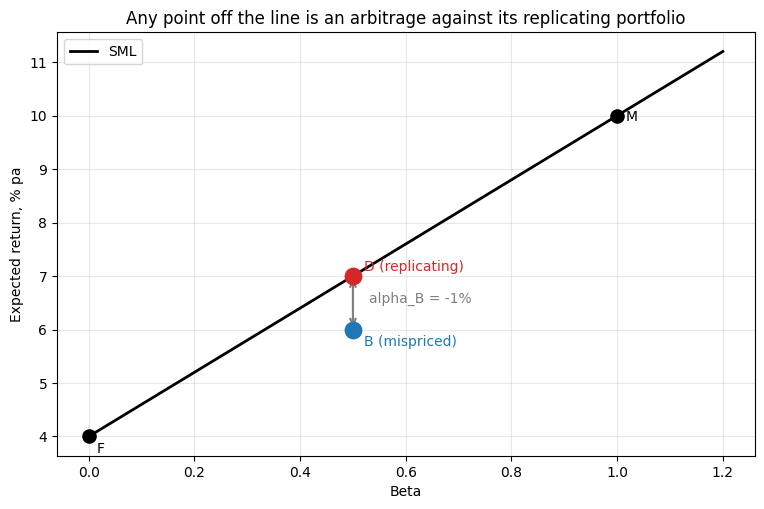

In [46]:
# ============================================================
# 3.2 A one-factor illustration: the arbitrage that flattens any curve
# ============================================================
# Portfolio B: beta = 0.50, E[r_B] = 6%. Market: E[r_M] = 10%, rF = 4%.
rf_b, ErM = 0.04, 0.10
beta_B, Er_B = 0.50, 0.06

Er_D = (1 - beta_B) * rf_b + beta_B * ErM        # replicate B's beta with rF + M
alpha_B = Er_B - (rf_b + beta_B * (ErM - rf_b))

print(f"Portfolio D = {1-beta_B:.0%} risk-free + {beta_B:.0%} market")
print(f"  beta_D  = {(1-beta_B)*0 + beta_B*1:.2f}   (same as B)")
print(f"  E[r_D]  = {Er_D:.2%}   vs   E[r_B] = {Er_B:.2%}")
print(f"\nArbitrage: short B, long D  ->  E[r] = {Er_D - Er_B:+.2%}, beta = {beta_B - beta_B:.2f}")
print(f"Portfolio B's alpha = {alpha_B:+.2%}  (it sits BELOW the SML)")

b_grid = np.linspace(0, 1.2, 50)
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(b_grid, (rf_b + b_grid * (ErM - rf_b)) * 100, color="black", lw=2, label="SML")
ax.scatter([0, 1.0], [rf_b * 100, ErM * 100], s=90, color="black", zorder=6)
ax.annotate("F", (0, rf_b * 100), xytext=(6, -12), textcoords="offset points")
ax.annotate("M", (1.0, ErM * 100), xytext=(6, -4), textcoords="offset points")
ax.scatter(beta_B, Er_D * 100, s=140, color="tab:red", zorder=7)
ax.annotate("D (replicating)", (beta_B, Er_D * 100), xytext=(8, 4), textcoords="offset points", color="tab:red")
ax.scatter(beta_B, Er_B * 100, s=140, color="tab:blue", zorder=7)
ax.annotate("B (mispriced)", (beta_B, Er_B * 100), xytext=(8, -12), textcoords="offset points", color="tab:blue")
ax.annotate("", xy=(beta_B, Er_D * 100), xytext=(beta_B, Er_B * 100),
            arrowprops=dict(arrowstyle="<->", color="grey", lw=1.6))
ax.text(beta_B + 0.03, (Er_D + Er_B) / 2 * 100, f"alpha_B = {alpha_B:+.0%}", fontsize=10, color="grey")
ax.set(xlabel="Beta", ylabel="Expected return, % pa",
       title="Any point off the line is an arbitrage against its replicating portfolio")
ax.legend(); plt.show()

## 4. APT vs CAPM

| | **CAPM** | **APT** |
|---|---|---|
| Equilibrium argument | risk–return dominance | no arbitrage |
| Who restores it | *all* investors, each trading a little | a *few* arbitrageurs, trading a lot |
| Needs the market portfolio? | **yes** — and it is unobservable (Roll) | **no** |
| Number of risk sources | one (market beta) | K, unspecified |
| Applies to | every asset | well-diversified portfolios; individual stocks only approximately |
| Names the factors? | yes — the market, with a positive premium | **no guidance at all** |
| Preference assumptions | mean-variance / normality | very weak |

The APT's strength is that no-arbitrage must hold on *any subset* of securities, so it is testable
without identifying the market portfolio. Its weakness is the mirror image: the theory is silent on
**what the factors are** and **what their premia should be**. The CAPM at least tells you the market
factor carries a positive premium.

One important qualification: with idiosyncratic risk present, an individual stock cannot be exactly
replicated, so the pricing relation need only hold **approximately** — deviations can exist, but they
cannot be *pervasive*, because pervasive deviations would be diversifiable into a genuine arbitrage.

## 5. Implementation: where do the factors come from?

Three approaches, all of which we apply to the SET100 below.

**(a) Statistical factors.** Compute the covariance matrix of returns and extract factors by
principal components / factor analysis. Statistically optimal, economically mute — you get factors
that explain variance but no story about what they *are*.

**(b) Macroeconomic factors.** Elton, Gruber and Mei (1994) use six: yield-curve shifts, interest-rate
level, FX, the business cycle, inflation, and an "other macro" index:

$$r_i=r_F+\beta_{i,YC}RP_{YC}+\beta_{i,IR}RP_{IR}+\beta_{i,EX}RP_{EX}
+\beta_{i,Y}RP_{Y}+\beta_{i,INF}RP_{INF}+\beta_{i,OTH}RP_{OTH}+\varepsilon_i$$

Loadings come from a time-series regression; premia come from month-by-month cross-sectional
regressions of returns on those loadings, averaged.

**(c) Characteristic-based factors.** Fama–French (1996) build factors from firm characteristics —
size and book-to-market — via a two-way sort:

$$SMB=r_S-r_B,\qquad HML=r_H-r_L$$
$$E[r_i]-r_F=\beta_i(E[r_M]-r_F)+s_iE[SMB]+h_iE[HML]$$

This is the intellectual origin of **smart beta**: rules-based, index-like products that deliberately
tilt toward a factor (size, value, momentum, low volatility) rather than tracking market cap.

In [47]:
# ============================================================
# 5.1 Macro-factor APT — the Elton-Gruber-Mei worked example (Niagara Mohawk)
# ============================================================
egm = pd.DataFrame({
    "factor risk premium %/mo": [0.425, -0.051, -0.049, 0.041, -0.069, 0.530],
    "factor beta": [1.0615, -2.4167, 1.3235, 0.1292, -0.5220, 0.3046],
}, index=["Term structure", "Interest rates", "Exchange rates", "Business cycle",
          "Inflation", "Other macro"])
egm["premium contribution %/mo"] = egm["factor risk premium %/mo"] * egm["factor beta"]
display(egm.round(4))

total = egm["premium contribution %/mo"].sum()
print(f"Total risk premium = {total:.4f}% per month  ->  E[r] = rF + {total:.2f}% per month")
print(f"                                              = rF + {total*12:.2f}% pa")
print("\nNote how the signs work: a NEGATIVE loading on a NEGATIVE premium (interest rates,")
print("-2.4167 x -0.051) adds to the required return. The utility's rate sensitivity is a risk")
print("investors must be paid to hold.")

,factor risk premium %/mo,factor beta,premium contribution %/mo
Term structure,0.425000,1.061500,0.451100
Interest rates,-0.051000,-2.416700,0.123300
Exchange rates,-0.049000,1.323500,-0.064900
Business cycle,0.041000,0.129200,0.005300
Inflation,-0.069000,-0.522000,0.036000
Other macro,0.530000,0.304600,0.161400


Total risk premium = 0.7123% per month  ->  E[r] = rF + 0.71% per month
                                              = rF + 8.55% pa

Note how the signs work: a NEGATIVE loading on a NEGATIVE premium (interest rates,
-2.4167 x -0.051) adds to the required return. The utility's rate sensitivity is a risk
investors must be paid to hold.


In [48]:
# ============================================================
# 5.2 Characteristic factors — the FF two-way sort, and FF3 vs the single index
# ============================================================
print("Two-way sort: 2 size buckets x 3 B/M buckets = 6 value-weighted portfolios")
grid = pd.DataFrame([["S/L", "S/M", "S/H"], ["B/L", "B/M", "B/H"]],
                    index=["Small cap", "Big cap"], columns=["Low BTM", "Median BTM", "High BTM"])
display(grid)
print("SMB = (1/3)(S/L + S/M + S/H) - (1/3)(B/L + B/M + B/H)      [size factor]")
print("HML = (1/2)(S/H + B/H)       - (1/2)(S/L + B/L)            [value factor]")
print("Both are returns on ZERO-INVESTMENT portfolios, exactly as the APT requires.\n")

# The lecture's Amazon comparison (monthly data, 5 years to Jun-2018)
amzn_cmp = pd.DataFrame({
    "Single-factor: coef": [0.01916, 1.533, np.nan, np.nan, 0.286, 0.06864],
    "Single-factor: t": [2.065, 4.865, np.nan, np.nan, np.nan, np.nan],
    "Three-factor: coef": [0.01494, 1.612, -0.689, -1.133, 0.455, 0.06101],
    "Three-factor: t": [1.790, 5.866, -2.126, -3.304, np.nan, np.nan],
}, index=["alpha (monthly)", "market beta", "SMB (s)", "HML (h)", "R-squared", "residual SD"])
display(amzn_cmp.round(4))

print("Adding SMB and HML raises R² from 0.286 to 0.455 and cuts residual SD from 6.86% to 6.10%.")
print("Amazon loads NEGATIVELY on both: it is a big growth stock. Because both factors earned")
print("positive premia over the window, that negative exposure raises its required return —")
print("which is why the estimated alpha FALLS from 1.92%/mo (t=2.07) to 1.49%/mo (t=1.79),")
print("no longer significant. Much of the 'skill' was simply a size and value tilt in disguise.")

Two-way sort: 2 size buckets x 3 B/M buckets = 6 value-weighted portfolios


,Low BTM,Median BTM,High BTM
Small cap,S/L,S/M,S/H
Big cap,B/L,B/M,B/H


SMB = (1/3)(S/L + S/M + S/H) - (1/3)(B/L + B/M + B/H)      [size factor]
HML = (1/2)(S/H + B/H)       - (1/2)(S/L + B/L)            [value factor]
Both are returns on ZERO-INVESTMENT portfolios, exactly as the APT requires.



,Single-factor: coef,Single-factor: t,Three-factor: coef,Three-factor: t
alpha (monthly),0.019200,2.065000,0.014900,1.790000
market beta,1.533000,4.865000,1.612000,5.866000
SMB (s),NaN,NaN,-0.689000,-2.126000
HML (h),NaN,NaN,-1.133000,-3.304000
R-squared,0.286000,NaN,0.455000,NaN
residual SD,0.068600,NaN,0.061000,NaN


Adding SMB and HML raises R² from 0.286 to 0.455 and cuts residual SD from 6.86% to 6.10%.
Amazon loads NEGATIVELY on both: it is a big growth stock. Because both factors earned
positive premia over the window, that negative exposure raises its required return —
which is why the estimated alpha FALLS from 1.92%/mo (t=2.07) to 1.49%/mo (t=1.79),
no longer significant. Much of the 'skill' was simply a size and value tilt in disguise.


---
# Part VI — The APT on the SET100, and a Head-to-Head Comparison of Every Technique

This final part does two things. First it implements all three routes to APT factors on the Thai
market. Then it puts **every technique from Topics 4–7 into one walk-forward trading experiment**
on the SET100 and compares them on identical terms.

## VI.1 Statistical factors: principal components of the SET100

The purely statistical route — take the covariance matrix of the 100 stocks and extract the
directions that explain the most common variance.

,eigenvalue,% of variance,cumulative %
PC1,23.836000,23.836000,23.836000
PC2,3.998000,3.998000,27.834000
PC3,3.331000,3.331000,31.165000
PC4,2.921000,2.921000,34.086000
PC5,2.619000,2.619000,36.705000
PC6,2.396000,2.396000,39.101000
PC7,2.221000,2.221000,41.322000
PC8,2.123000,2.123000,43.445000
PC9,2.067000,2.067000,45.512000
PC10,1.858000,1.858000,47.369000


First 5 components explain 36.70% of common variation.
PC1 alone explains 23.84%.

Correlation of each statistical factor with the SET Index:


,corr with SET
PC1,0.862600
PC2,0.131100
PC3,0.020000
PC4,0.075600
PC5,0.061100


Share of PC1 loadings carrying the same sign: 100%
PC1 correlation with the SET Index         : 0.8626
A near-uniform sign plus a high correlation with the index says PC1 IS the market factor,
recovered from the covariance structure alone without ever being told what the index is.

PC2 — the largest positive and negative loadings (what does it separate?):


,PC2 loading,sector
PTTEP,0.252500,Energy Minerals
PTTGC,0.247000,Energy Minerals
IRPC,0.235400,Energy Minerals
BCP,0.208300,Retail Trade
TOP,0.205500,Energy Minerals
SPRC,0.197000,Energy Minerals


,PC2 loading,sector
TIDLOR,-0.189100,Finance
CRC,-0.166200,Retail Trade
BDMS,-0.162300,Health Services
CHG,-0.158300,Health Services
BH,-0.150200,Health Services
BCH,-0.140300,Health Services


Top-15 PC2 loadings are concentrated in : Energy Minerals, Process Industries, Electronic Technology
Bottom-15 PC2 loadings are mostly       : Retail Trade, Health Services, Finance


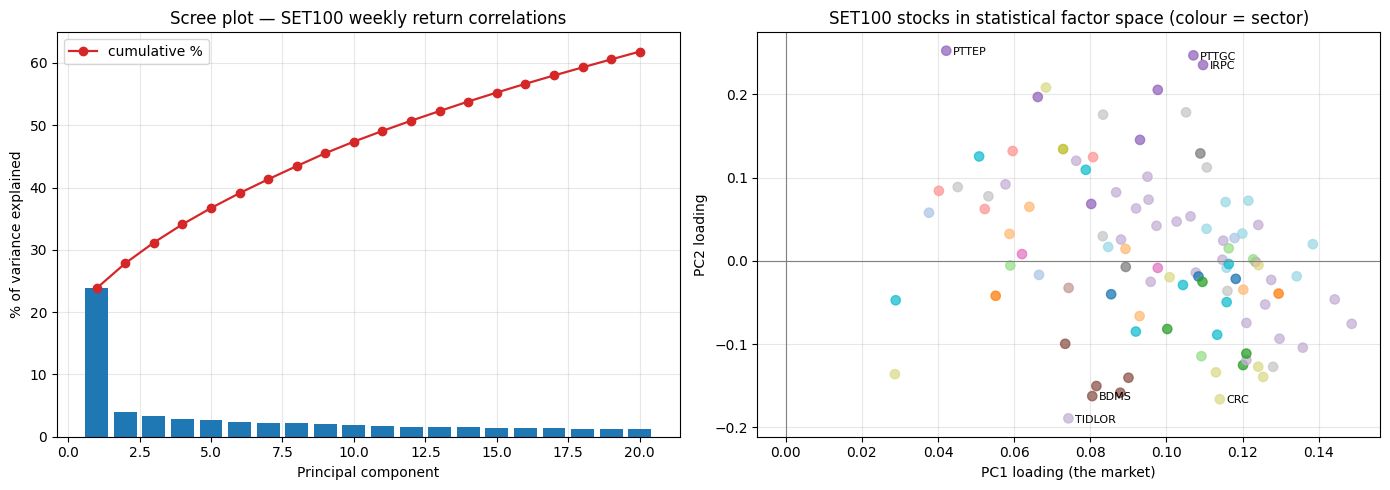


PC1 is unmistakably the market: 100% of loadings share a sign and it correlates 0.86 with
the SET Index, recovered from the correlation structure alone without ever being shown the
index. PC2 is the more interesting one — it separates the energy and refining complex from
domestic defensives (healthcare, retail). That is a genuine, economically readable second
factor: an oil/commodity exposure that the single-index model cannot see, and precisely the
kind of sector co-movement that made the SIM's Cov[eps_i, eps_j] = 0 assumption fail in
Part IV.

But note what the statistics still do NOT give us. PCA found the factor; it cannot tell us
the SIGN or SIZE of its risk premium, whether investors are paid to bear it, or whether the
same component will exist next year. That gap between 'a factor exists' and 'a factor is
priced' is the APT's implementation problem, and no amount of eigen-decomposition closes it.


In [49]:
# ============================================================
# VI.1 PCA factors from the SET100 return correlation matrix
# ============================================================
rets_pca = rets[TICKERS].copy()
rets_pca.columns = sym_index
X_pca = rets_pca.fillna(0.0)

# Decompose the CORRELATION matrix, not the covariance matrix. A covariance-matrix PCA is
# scale-dependent: the highest-variance stock dominates PC1 and you learn about that stock
# rather than about the market. (The backtest in VI.4 still needs the covariance form, and
# rebuilds it there from the same eigen-structure.)
Z = (X_pca - X_pca.mean()) / X_pca.std(ddof=1)
Corr = nearest_psd(np.corrcoef(Z.values.T))
eigvals, eigvecs = np.linalg.eigh(Corr)
order = np.argsort(eigvals)[::-1]
eigvals, eigvecs = eigvals[order], eigvecs[:, order]
explained = eigvals / eigvals.sum()

pc_tbl = pd.DataFrame({"eigenvalue": eigvals[:10], "% of variance": explained[:10] * 100,
                       "cumulative %": np.cumsum(explained[:10]) * 100},
                      index=[f"PC{i+1}" for i in range(10)])
display(pc_tbl.round(3))

K_PCA = 5
scores = pd.DataFrame(Z.values @ eigvecs[:, :K_PCA],
                      index=Z.index, columns=[f"PC{i+1}" for i in range(K_PCA)])
# Eigenvector signs are arbitrary; orient each component to correlate positively with the market.
signs = np.sign(scores.corrwith(rets[MARKET]).fillna(1.0)).replace(0, 1.0)
scores = scores * signs.values
eigvecs[:, :K_PCA] = eigvecs[:, :K_PCA] * signs.values

print(f"First {K_PCA} components explain {explained[:K_PCA].sum():.2%} of common variation.")
print(f"PC1 alone explains {explained[0]:.2%}.\n")
print("Correlation of each statistical factor with the SET Index:")
display(scores.corrwith(rets[MARKET]).to_frame("corr with SET").round(4))

load1 = pd.Series(eigvecs[:, 0], index=sym_index)
load2 = pd.Series(eigvecs[:, 1], index=sym_index)
sec = universe.set_index("symbol").sector
same_sign = float((np.sign(load1) == np.sign(load1).mode()[0]).mean())
print(f"Share of PC1 loadings carrying the same sign: {same_sign:.0%}")
print(f"PC1 correlation with the SET Index         : {scores['PC1'].corr(rets[MARKET]):.4f}")
print("A near-uniform sign plus a high correlation with the index says PC1 IS the market factor,")
print("recovered from the covariance structure alone without ever being told what the index is.\n")

print("PC2 — the largest positive and negative loadings (what does it separate?):")
pc2 = pd.DataFrame({"PC2 loading": load2, "sector": sec})
display(pc2.sort_values("PC2 loading", ascending=False).head(6).round(4))
display(pc2.sort_values("PC2 loading").head(6).round(4))
top_sec = pc2.sort_values("PC2 loading", ascending=False).head(15).sector.value_counts()
bot_sec = pc2.sort_values("PC2 loading").head(15).sector.value_counts()
print(f"Top-15 PC2 loadings are concentrated in : {', '.join(top_sec.index[:3])}")
print(f"Bottom-15 PC2 loadings are mostly       : {', '.join(bot_sec.index[:3])}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1, 21), explained[:20] * 100, color="tab:blue")
axes[0].plot(range(1, 21), np.cumsum(explained[:20]) * 100, color="tab:red", marker="o", lw=1.6,
             label="cumulative %")
axes[0].set(xlabel="Principal component", ylabel="% of variance explained",
            title="Scree plot — SET100 weekly return correlations")
axes[0].legend()
sec_codes = pd.Categorical(sec.reindex(sym_index)).codes
axes[1].scatter(load1, load2, s=45, alpha=0.75, c=sec_codes, cmap="tab20")
axes[1].axhline(0, color="grey", lw=0.8); axes[1].axvline(0, color="grey", lw=0.8)
for lab in list(load2.nlargest(3).index) + list(load2.nsmallest(3).index):
    axes[1].annotate(lab, (load1[lab], load2[lab]), xytext=(5, -3), textcoords="offset points", fontsize=8)
axes[1].set(xlabel="PC1 loading (the market)", ylabel="PC2 loading",
            title="SET100 stocks in statistical factor space (colour = sector)")
plt.tight_layout(); plt.show()

print("\nPC1 is unmistakably the market: 100% of loadings share a sign and it correlates 0.86 with")
print("the SET Index, recovered from the correlation structure alone without ever being shown the")
print("index. PC2 is the more interesting one — it separates the energy and refining complex from")
print("domestic defensives (healthcare, retail). That is a genuine, economically readable second")
print("factor: an oil/commodity exposure that the single-index model cannot see, and precisely the")
print("kind of sector co-movement that made the SIM's Cov[eps_i, eps_j] = 0 assumption fail in")
print("Part IV.")
print("\nBut note what the statistics still do NOT give us. PCA found the factor; it cannot tell us")
print("the SIGN or SIZE of its risk premium, whether investors are paid to bear it, or whether the")
print("same component will exist next year. That gap between 'a factor exists' and 'a factor is")
print("priced' is the APT's implementation problem, and no amount of eigen-decomposition closes it.")

## VI.2 Macroeconomic factors: an Elton–Gruber–Mei style model for Thailand

The Thai analogue of the six EGM factors, using tradable/observable weekly proxies:

| Factor | Proxy | Economic risk |
|---|---|---|
| Business cycle / global growth | S&P 500 return | world demand |
| Commodity / energy | WTI crude return | input costs; Thailand is a net energy importer |
| Currency | USD/THB return | exporter competitiveness, foreign-investor flows |
| Interest-rate level | change in US 10-year yield | discount rate, global cost of capital |
| Safe haven / inflation hedge | gold return | inflation and crisis risk |

Then the two-pass implementation exactly as the lecture prescribes: time-series regressions give
each stock's **loadings**; a cross-sectional regression of average returns on those loadings gives
the **factor risk premia** $\lambda_k$; and $E[r_i]=r_F+\sum_k\beta_{i,k}\lambda_k$.

In [50]:
# ============================================================
# VI.2 Macro factor data and innovations
# ============================================================
MACRO_TICKERS = {"^GSPC": "US_EQUITY", "CL=F": "OIL", "THB=X": "USDTHB",
                 "^TNX": "US10Y", "GC=F": "GOLD"}

MACRO_CACHE = CACHE / "macro_factors.pkl"
if MACRO_CACHE.exists():
    macro_px = pd.read_pickle(MACRO_CACHE)
    print("macro factor prices loaded from cache")
else:
    macro_px = yf.download(list(MACRO_TICKERS), start="2015-01-01", interval="1d",
                           auto_adjust=True, progress=False)["Close"]
    macro_px.to_pickle(MACRO_CACHE)
    print("macro factor prices downloaded")

macro_w = macro_px.resample("W-FRI").last().rename(columns=MACRO_TICKERS)

# Innovations: returns for price series, first differences for the yield.
macro_f = pd.DataFrame({
    "US_EQUITY": macro_w["US_EQUITY"].pct_change(),
    "OIL": macro_w["OIL"].pct_change(),
    "USDTHB": macro_w["USDTHB"].pct_change(),
    "US10Y": macro_w["US10Y"].diff() / 100.0,
    "GOLD": macro_w["GOLD"].pct_change(),
}).reindex(rets.index)

print(f"\nMacro factor innovations, {macro_f.notna().all(axis=1).sum()} complete weeks")
display((macro_f.describe().T[["mean", "std", "min", "max"]] * 100).round(3)
        .rename(columns=lambda c: c + " (%)"))
print("Correlation among the macro factors (should be modest for the APT's orthogonality story):")
display(macro_f.corr().round(3))

macro factor prices loaded from cache

Macro factor innovations, 260 complete weeks


,mean (%),std (%),min (%),max (%)
US_EQUITY,0.232000,2.261000,-9.082000,6.584000
OIL,0.265000,5.854000,-13.421000,35.631000
USDTHB,0.011000,1.126000,-4.872000,2.919000
US10Y,0.013000,0.134000,-0.408000,0.508000
GOLD,0.371000,2.373000,-9.542000,8.452000


Correlation among the macro factors (should be modest for the APT's orthogonality story):


,US_EQUITY,OIL,USDTHB,US10Y,GOLD
US_EQUITY,1.000000,0.013000,-0.314000,-0.129000,0.171000
OIL,0.013000,1.000000,0.074000,0.217000,0.085000
USDTHB,-0.314000,0.074000,1.000000,0.332000,-0.488000
US10Y,-0.129000,0.217000,0.332000,1.000000,-0.189000
GOLD,0.171000,0.085000,-0.488000,-0.189000,1.000000


In [51]:
# ============================================================
# VI.2b First pass: factor loadings for all 100 stocks
# ============================================================
F_cols = list(macro_f.columns)

def macro_loadings(ret_series, factors, rf_per_period, min_obs=60):
    d = pd.concat([ret_series, factors], axis=1).dropna()
    if len(d) < min_obs:
        return None
    y = (d.iloc[:, 0] - rf_per_period).values
    Xm = np.column_stack([np.ones(len(d))] + [d[c].values for c in factors.columns])
    coef, *_ = np.linalg.lstsq(Xm, y, rcond=None)
    resid = y - Xm @ coef
    dof = len(d) - Xm.shape[1]
    s2 = float(resid @ resid / dof)
    se = np.sqrt(np.diag(s2 * np.linalg.inv(Xm.T @ Xm)))
    ss_tot = float(((y - y.mean()) ** 2).sum())
    return dict(n=len(d), **{f"b_{c}": coef[i + 1] for i, c in enumerate(factors.columns)},
                **{f"t_{c}": coef[i + 1] / se[i + 1] for i, c in enumerate(factors.columns)},
                r2=1 - float(resid @ resid) / ss_tot, sigma_eps_ann=np.sqrt(s2 * PERIODS_PER_YEAR))

rows = {}
for sym, tic in zip(universe.symbol, universe.yf_ticker):
    out = macro_loadings(rets[tic], macro_f, RF_WEEKLY)
    if out is not None:
        rows[sym] = out
macro_tbl = pd.DataFrame(rows).T.astype(float)
print(f"Macro loadings estimated for {len(macro_tbl)} of 100 stocks\n")

print("Average loading and how often it is significant (|t| > 2):")
summ = pd.DataFrame({
    "mean beta": [macro_tbl[f"b_{c}"].mean() for c in F_cols],
    "median beta": [macro_tbl[f"b_{c}"].median() for c in F_cols],
    "% with |t| > 2": [(macro_tbl[f"t_{c}"].abs() > 2).mean() * 100 for c in F_cols],
}, index=F_cols)
display(summ.round(3))
print(f"Median R² of the 5-factor macro model : {macro_tbl.r2.median():.4f}")
print(f"Median R² of the single-index model   : {sim_tbl.r2.median():.4f}")
print("\nNote the direction of that comparison: FIVE global macro factors explain LESS of a typical")
print("SET100 stock than the ONE local market index does. These are non-nested models, so more")
print("factors need not mean more R². The only loading that is significant for most stocks is")
print("USD/THB — for a Thai investor the currency is the macro risk that really bites, while global")
print("growth, oil and gold barely register once you are looking at weekly equity returns.")

Macro loadings estimated for 99 of 100 stocks

Average loading and how often it is significant (|t| > 2):


,mean beta,median beta,% with |t| > 2
US_EQUITY,0.098000,0.098000,18.182000
OIL,-0.029000,-0.043000,29.293000
USDTHB,-0.759000,-0.755000,70.707000
US10Y,-0.174000,0.087000,6.061000
GOLD,-0.017000,-0.020000,1.010000


Median R² of the 5-factor macro model : 0.0698
Median R² of the single-index model   : 0.1903

Note the direction of that comparison: FIVE global macro factors explain LESS of a typical
SET100 stock than the ONE local market index does. These are non-nested models, so more
factors need not mean more R². The only loading that is significant for most stocks is
USD/THB — for a Thai investor the currency is the macro risk that really bites, while global
growth, oil and gold barely register once you are looking at weekly equity returns.


In [52]:
# ============================================================
# VI.2c Second pass: estimating the factor risk premia (lambdas)
# ============================================================
common = macro_tbl.index
B_mat = macro_tbl[[f"b_{c}" for c in F_cols]].values
mean_excess = (mu_weekly * PERIODS_PER_YEAR).values - RF_ANNUAL
mean_excess = pd.Series(mean_excess, index=sym_index).reindex(common).values

Xcs = np.column_stack([np.ones(len(common)), B_mat])
lam, *_ = np.linalg.lstsq(Xcs, mean_excess, rcond=None)
res_cs = mean_excess - Xcs @ lam
dof_cs = len(common) - Xcs.shape[1]
se_cs = np.sqrt(np.diag((res_cs @ res_cs / dof_cs) * np.linalg.inv(Xcs.T @ Xcs)))

lam_tbl = pd.DataFrame({"lambda (annual RP)": lam, "std error": se_cs, "t": lam / se_cs},
                       index=["intercept (should be 0)"] + F_cols)
display(lam_tbl.round(4))
print(f"Cross-sectional R² = {1 - (res_cs @ res_cs) / ((mean_excess - mean_excess.mean())**2).sum():.4f}")

# APT-implied expected returns
mu_apt = pd.Series(RF_ANNUAL + Xcs @ lam, index=common)
cmp_mu = pd.DataFrame({
    "historical E[r]": pd.Series((mu_weekly * PERIODS_PER_YEAR).values, index=sym_index).reindex(common),
    "APT-implied E[r]": mu_apt,
    "CAPM-implied E[r]": pd.Series(RF_ANNUAL + betas * MRP_FORWARD, index=sym_index).reindex(common),
})
print("\nThree competing input lists for the SAME optimiser:")
display(cmp_mu.describe().round(4))
print("\nHow much do they disagree? (cross-sectional correlation)")
display(cmp_mu.corr().round(4))
print("\nThis is the single most important table in the notebook. The optimiser is only as good as")
print("the expected returns you hand it, and these three theories disagree substantially about")
print("which SET100 stocks should earn what.")

,lambda (annual RP),std error,t
intercept (should be 0),0.026800,0.035600,0.753400
US_EQUITY,-0.095800,0.089400,-1.072200
OIL,0.254800,0.201400,1.264800
USDTHB,-0.051100,0.038200,-1.339100
US10Y,0.005300,0.005500,0.964800
GOLD,0.205600,0.164000,1.253500


Cross-sectional R² = 0.0766

Three competing input lists for the SAME optimiser:


,historical E[r],APT-implied E[r],CAPM-implied E[r]
count,99.000000,99.000000,99.000000
mean,0.062000,0.062000,0.077400
std,0.166000,0.045900,0.022000
min,-0.363000,-0.042200,0.035000
25%,-0.063300,0.031900,0.061800
50%,0.040400,0.058800,0.075800
75%,0.160400,0.084400,0.090100
max,0.658400,0.258900,0.155900



How much do they disagree? (cross-sectional correlation)


,historical E[r],APT-implied E[r],CAPM-implied E[r]
historical E[r],1.000000,0.276800,-0.131100
APT-implied E[r],0.276800,1.000000,0.078400
CAPM-implied E[r],-0.131100,0.078400,1.000000



This is the single most important table in the notebook. The optimiser is only as good as
the expected returns you hand it, and these three theories disagree substantially about
which SET100 stocks should earn what.


## VI.3 Characteristic factors: a Fama–French style model inside the SET100

The third route builds factors from firm characteristics via the two-way sort. Within the SET100 we
form:

- **SMB** — small minus big, on market capitalisation
- **HML** — high minus low book-to-market, using $B/M = 1/(P/B)$
- **WML** — winners minus losers, 12-month momentum skipping the most recent month (Carhart)
- **BAB-style LOW VOL** — low minus high trailing volatility

Momentum and volatility are computed from prices alone and are **point-in-time safe**. Size and B/M
come from *current* fundamentals, so any result using them carries look-ahead bias — flagged
wherever it appears.

In [53]:
# ============================================================
# VI.3 Firm characteristics (current snapshot) and the factor portfolios
# ============================================================
SET100_FUNDAMENTALS = {
    "DELTA": (3105980285156, 29.1088),
    "PTT": (1163942090820, 0.9725),
    "ADVANC": (1055844449463, 19.8554),
    "GULF": (944944746582, 2.8995),
    "AOT": (907141962402, 6.5752),
    "KTB": (605399618652, 1.3506),
    "PTTEP": (589542824707, 1.0457),
    "KBANK": (587593193359, 1.0119),
    "SCB": (508433183838, 1.0584),
    "TRUE": (452632543649, 5.5695),
    "CPALL": (415468402100, 3.0895),
    "BBL": (364588993042, 0.6324),
    "SCC": (313200000000, 0.8542),
    "BDMS": (311483244344, 3.0476),
    "CPN": (300664669067, 2.6674),
    "TTB": (282751784154, 1.1271),
    "PTTGC": (200643785889, 0.6468),
    "CPF": (178724243319, 0.7864),
    "CRC": (174899000000, 2.6107),
    "THAI": (165574261168, 1.9560),
    "BH": (152249892948, 5.6026),
    "OR": (150000000000, 1.3632),
    "GPSC": (149445663086, 1.3556),
    "TOP": (142965468750, 0.7140),
    "IVL": (136995060749, 1.1949),
    "SCGP": (129860827637, 1.6263),
    "TLI": (128239997816, 0.9122),
    "MINT": (125873494853, 2.0799),
    "BEM": (105466501458, 2.6806),
    "KKP": (103869171143, 1.4526),
    "TISCO": (102483902577, 2.3848),
    "CCET": (99273673340, 3.6705),
    "AWC": (98641755916, 0.9819),
    "KTC": (96042940918, 2.1543),
    "HMPRO": (84825226154, 3.1932),
    "RATCH": (83737500000, 0.7937),
    "BCP": (81040464844, 1.0267),
    "TCAP": (79934676742, 1.0296),
    "WHA": (72043742370, 1.8446),
    "KCE": (71497699158, 5.3335),
    "COM7": (71034037231, 6.1811),
    "EGCO": (70019848572, 0.6897),
    "MTC": (66250000000, 1.3821),
    "BJC": (62106604126, 0.5231),
    "TFG": (59367856445, 2.6153),
    "BANPU": (58719520020, 0.4862),
    "CENTEL": (58387500000, 2.3244),
    "SPRC": (57233903665, 1.0691),
    "MRDIYT": (56861567090, 5.2496),
    "TIDLOR": (55847933619, 1.5600),
    "IRPC": (54700387378, 0.7471),
    "CBG": (54500000000, 3.6090),
    "BGRIM": (52920066029, 1.4836),
    "OSP": (48360376146, 2.9220),
    "TU": (46054182644, 1.0818),
    "GUNKUL": (45745036785, 2.8058),
    "LH": (43735950205, 0.8444),
    "BLA": (41493853470, 0.7114),
    "BTG": (39663401001, 1.2422),
    "BA": (39346000786, 2.7319),
    "SAWAD": (39211561962, 0.9421),
    "GLOBAL": (38933831060, 1.4326),
    "HANA": (38030525436, 1.4997),
    "AMATA": (37662500000, 1.3778),
    "RCL": (36465000000, 0.5793),
    "STA": (35174399414, 0.6934),
    "BTS": (33475110491, 0.5586),
    "STGT": (31803498334, 0.7706),
    "TOA": (31449498108, 1.9381),
    "MEGA": (31387302246, 2.9501),
    "CK": (30339511101, 0.9907),
    "PLANB": (30131830272, 2.3230),
    "WHAUP": (29069999635, 2.0646),
    "SPALI": (28305657909, 0.5366),
    "TASCO": (28094834782, 1.8698),
    "STECON": (27693126965, 1.2815),
    "BCH": (26683103626, 2.0632),
    "AP": (25796374595, 0.5423),
    "SIRI": (25664881569, 0.5556),
    "AEONTS": (24962149384, 0.8560),
    "BCPG": (22168618938, 0.7449),
    "EA": (21389187100, 0.6375),
    "VGI": (21312295834, 0.5788),
    "PRM": (20867999153, 1.7739),
    "BAM": (20523467892, 0.4670),
    "M": (19614701800, 1.4774),
    "AURA": (18995299183, 2.4832),
    "ERW": (18277117078, 1.9266),
    "ICHI": (17940000248, 3.2736),
    "JMT": (16057135864, 0.5626),
    "JMART": (16041656641, 0.8391),
    "CHG": (15950001941, 2.1440),
    "QH": (15214420361, 0.4904),
    "PR9": (14939700928, 2.4341),
    "AAV": (13235499632, 1.0631),
    "PTG": (12775500159, 1.3521),
    "MOSHI": (12705000000, 4.5855),
    "DOHOME": (12526239613, 0.8775),
    "GFPT": (12475519158, 0.5596),
    "THCOM": (11947511935, 1.0616),
}

fund = pd.DataFrame(SET100_FUNDAMENTALS, index=["market_cap", "price_to_book"]).T
fund = fund.reindex(sym_index).astype(float)
fund["log_size"] = np.log(fund.market_cap)
fund["book_to_market"] = 1.0 / fund.price_to_book
print(f"Fundamentals available: market cap {fund.market_cap.notna().sum()}/100, "
      f"P/B {fund.price_to_book.notna().sum()}/100")
display(fund[["market_cap", "price_to_book", "book_to_market"]].describe().round(3))

def two_way_sort_factors(ret_panel, size, btm):
    # 2 size buckets x 3 B/M buckets -> SMB and HML, as in the lecture's sorting table.
    ok = size.dropna().index.intersection(btm.dropna().index).intersection(ret_panel.columns)
    size, btm = size[ok], btm[ok]
    small = size <= size.median()
    lo, hi = btm.quantile(0.30), btm.quantile(0.70)
    bucket = pd.Series(np.where(btm <= lo, "L", np.where(btm >= hi, "H", "M")), index=ok)
    grp = {}
    for s_lab, s_mask in [("S", small), ("B", ~small)]:
        for b_lab in ["L", "M", "H"]:
            members = ok[(s_mask.values) & (bucket.values == b_lab)]
            grp[f"{s_lab}/{b_lab}"] = ret_panel[list(members)].mean(axis=1) if len(members) else np.nan
    g = pd.DataFrame(grp)
    smb = g[["S/L", "S/M", "S/H"]].mean(axis=1) - g[["B/L", "B/M", "B/H"]].mean(axis=1)
    hml = g[["S/H", "B/H"]].mean(axis=1) - g[["S/L", "B/L"]].mean(axis=1)
    return smb, hml, g

SMB, HML, buckets = two_way_sort_factors(rets_pca, fund.log_size, fund.book_to_market)

# Momentum and low-volatility factors, computed from prices only (point-in-time safe).
mom_score = (1 + rets_pca.iloc[-52:-4]).prod() - 1
vol_score = rets_pca.std() * np.sqrt(PERIODS_PER_YEAR)
def long_short(score, panel, frac=0.3):
    s = score.dropna(); k = max(5, int(len(s) * frac))
    win, los = s.nlargest(k).index, s.nsmallest(k).index
    return panel[list(win)].mean(axis=1) - panel[list(los)].mean(axis=1)
WML = long_short(mom_score, rets_pca)
LOWVOL = -long_short(vol_score, rets_pca)

factors = pd.DataFrame({"MKT_RF": rets[MARKET] - RF_WEEKLY, "SMB": SMB, "HML": HML,
                        "WML": WML, "LOWVOL": LOWVOL}).dropna()
prem = pd.DataFrame({
    "premium pa": factors.mean() * PERIODS_PER_YEAR,
    "SD pa": factors.std(ddof=1) * np.sqrt(PERIODS_PER_YEAR),
})
prem["Sharpe / t-stat"] = (factors.mean() / factors.std(ddof=1)) * np.sqrt(len(factors))
prem["point-in-time safe"] = ["yes", "no (current mkt cap)", "no (current P/B)", "yes", "yes"]
display(prem.round(4))
print("Correlation among the SET100 factors:")
display(factors.corr().round(3))
print("\nRead the premia column carefully — the textbook signs do NOT hold in the SET100 over this")
print("window. SMB and HML both earned large NEGATIVE premia (large caps and growth beat small and")
print("value, both significant at 5%), while momentum earned a strongly positive +19% pa. Any")
print("'small + value' smart-beta product would have been fighting the tape; a momentum product")
print("would have had the wind behind it. The APT tells you factors are priced; it does not tell")
print("you the sign, and in a single market over five years the sign is an empirical question.")

Fundamentals available: market cap 100/100, P/B 100/100


,market_cap,price_to_book,book_to_market
count,100.000000,100.000000,100.000000
mean,"168,715,805,377.290009",2.237000,0.855000
std,"371,339,288,341.562988",3.525000,0.535000
min,"11,947,511,935.000000",0.467000,0.034000
25%,"27,994,407,827.750000",0.843000,0.409000
50%,"55,274,160,498.500000",1.359000,0.736000
75%,"131,644,385,915.000000",2.446000,1.186000
max,"3,105,980,285,156.000000",29.109000,2.141000


,premium pa,SD pa,Sharpe / t-stat,point-in-time safe
MKT_RF,-0.008300,0.132600,-0.137700,yes
SMB,-0.087100,0.087200,-2.202800,no (current mkt cap)
HML,-0.116700,0.104000,-2.475000,no (current P/B)
WML,0.192100,0.134500,3.151500,yes
LOWVOL,0.039800,0.156800,0.559900,yes


Correlation among the SET100 factors:


,MKT_RF,SMB,HML,WML,LOWVOL
MKT_RF,1.000000,0.132000,0.133000,-0.009000,-0.532000
SMB,0.132000,1.000000,-0.044000,-0.152000,-0.365000
HML,0.133000,-0.044000,1.000000,-0.017000,-0.215000
WML,-0.009000,-0.152000,-0.017000,1.000000,0.061000
LOWVOL,-0.532000,-0.365000,-0.215000,0.061000,1.000000



Read the premia column carefully — the textbook signs do NOT hold in the SET100 over this
window. SMB and HML both earned large NEGATIVE premia (large caps and growth beat small and
value, both significant at 5%), while momentum earned a strongly positive +19% pa. Any
'small + value' smart-beta product would have been fighting the tape; a momentum product
would have had the wind behind it. The APT tells you factors are priced; it does not tell
you the sign, and in a single market over five years the sign is an empirical question.


In [54]:
# ============================================================
# VI.3b Single index vs FF3 vs 5-factor: does adding factors help?
# ============================================================
def multi_factor_fit(y_series, F, rf_per_period, min_obs=60):
    d = pd.concat([y_series, F], axis=1).dropna()
    if len(d) < min_obs:
        return None
    y = (d.iloc[:, 0] - rf_per_period).values
    Xm = np.column_stack([np.ones(len(d))] + [d[c].values for c in F.columns])
    coef, *_ = np.linalg.lstsq(Xm, y, rcond=None)
    e = y - Xm @ coef
    dof = len(d) - Xm.shape[1]
    s2 = float(e @ e / dof)
    se = np.sqrt(np.diag(s2 * np.linalg.inv(Xm.T @ Xm)))
    ss = float(((y - y.mean()) ** 2).sum())
    return dict(alpha_ann=coef[0] * PERIODS_PER_YEAR, t_alpha=coef[0] / se[0],
                r2=1 - float(e @ e) / ss, resid_sd=np.sqrt(s2 * PERIODS_PER_YEAR),
                **{f"b_{c}": coef[i + 1] for i, c in enumerate(F.columns)})

specs = {"Single index (CAPM/SIM)": factors[["MKT_RF"]],
         "FF3 (MKT+SMB+HML)": factors[["MKT_RF", "SMB", "HML"]],
         "Carhart-style 5F (+WML,LOWVOL)": factors[["MKT_RF", "SMB", "HML", "WML", "LOWVOL"]]}

fit_summary = {}
alpha_store = {}
for label, F in specs.items():
    res = {s: multi_factor_fit(rets_pca[s], F, RF_WEEKLY) for s in sym_index}
    res = {k: v for k, v in res.items() if v is not None}
    df = pd.DataFrame(res).T.astype(float)
    alpha_store[label] = df
    fit_summary[label] = {
        "stocks fitted": len(df), "median R²": df.r2.median(),
        "median |alpha| pa": df.alpha_ann.abs().median(),
        "median residual SD pa": df.resid_sd.median(),
        "# alphas sig at 5%": int((df.t_alpha.abs() > 1.98).sum()),
    }
display(pd.DataFrame(fit_summary).T.round(4))

print("\nTwo of the three expected effects show up: R² rises and residual risk falls with each added")
print("factor. But median |alpha| RISES rather than falling, and MORE alphas become significant.")
print("That is not a coding error — it follows from the negative SMB and HML premia above. When a")
print("factor earns a negative premium, a stock that loads positively on it has a LOWER required")
print("return, so its measured alpha goes UP. Adding factors here reshuffles pricing errors rather")
print("than shrinking them, which is evidence that these characteristic factors are not capturing")
print("priced risk in the SET100 over this sample.\n")

moved = pd.DataFrame({
    "alpha (1-factor)": alpha_store["Single index (CAPM/SIM)"].alpha_ann,
    "alpha (5-factor)": alpha_store["Carhart-style 5F (+WML,LOWVOL)"].alpha_ann,
}).dropna()
moved["absorbed by factors"] = moved["alpha (1-factor)"] - moved["alpha (5-factor)"]
print("Stocks whose measured alpha moves most once factor exposures are controlled for")
print("(positive 'absorbed' = the 1-factor alpha was factor exposure; negative = the factors made")
print("the stock look BETTER, because it was loading on factors with negative premia):")
display(moved.reindex(moved["absorbed by factors"].abs().sort_values(ascending=False).index).head(8).round(4))

,stocks fitted,median R²,median |alpha| pa,median residual SD pa,# alphas sig at 5%
Single index (CAPM/SIM),99.000000,0.191000,0.091400,0.276400,11.000000
FF3 (MKT+SMB+HML),99.000000,0.269500,0.096300,0.256400,12.000000
"Carhart-style 5F (+WML,LOWVOL)",99.000000,0.318600,0.116300,0.253800,15.000000



Two of the three expected effects show up: R² rises and residual risk falls with each added
factor. But median |alpha| RISES rather than falling, and MORE alphas become significant.
That is not a coding error — it follows from the negative SMB and HML premia above. When a
factor earns a negative premium, a stock that loads positively on it has a LOWER required
return, so its measured alpha goes UP. Adding factors here reshuffles pricing errors rather
than shrinking them, which is evidence that these characteristic factors are not capturing
priced risk in the SET100 over this sample.

Stocks whose measured alpha moves most once factor exposures are controlled for
(positive 'absorbed' = the 1-factor alpha was factor exposure; negative = the factors made
the stock look BETTER, because it was loading on factors with negative premia):


,alpha (1-factor),alpha (5-factor),absorbed by factors
TIDLOR,0.105900,0.621300,-0.515500
DELTA,0.465600,-0.033700,0.499300
EA,-0.359600,0.132100,-0.491700
JMT,-0.113800,0.329600,-0.443400
JMART,-0.098200,0.320000,-0.418200
THAI,0.549300,0.959100,-0.409800
VGI,-0.224900,0.179100,-0.404000
CCET,0.427400,0.099700,0.327700


## VI.4 The horse race: every technique, one protocol, real trading frictions

Fourteen portfolio-construction techniques — one from essentially every idea in Topics 4 to 7 —
run through an identical **walk-forward** experiment on the SET100.

**Protocol (identical for every strategy).**

| Rule | Setting |
|---|---|
| Universe | the SET100, restricted at each rebalance to names with ≥ 2 years of history *at that date* |
| Estimation window | trailing **130 weeks** (2.5 years), rolling |
| Rebalance | every **13 weeks** (quarterly) |
| Out-of-sample period | everything after the first estimation window — no overlap with estimation |
| Constraints | long-only, fully invested, **10% position cap** |
| Transaction costs | **25 bps** on turnover at each rebalance (Thai institutional round-trip) |
| Benchmark | the SET Index |

Because weights at date $t$ use only data up to $t$, this is a genuine out-of-sample test, not the
in-sample fit that made the Part IV tangency portfolio look so good.

**The contestants.**

| # | Technique | Topic | What it needs |
|---|---|---|---|
| 1 | SET Index, buy and hold | benchmark | nothing |
| 2 | Equal weight, 1/N | T4 diversification | nothing |
| 3 | Global minimum variance | T4 frontier | $V$ only |
| 4 | Markowitz tangency, sample $V$ | T4 §4.2 | $\mu$, $V$ |
| 5 | Markowitz tangency, shrunk $V$ | T4 + Ledoit–Wolf | $\mu$, $V$ |
| 6 | Tangency, SIM covariance | T5 | $\alpha,\beta,\sigma_\varepsilon$ |
| 7 | Treynor–Black, shrunk alphas | T5 §3.2 | $\alpha,\beta,\sigma_\varepsilon$ |
| 8 | CAPM-implied $\mu$ + SIM $V$ | T6 | $\beta$ |
| 9 | Low-beta tilt (betting against beta) | T6 empirical SML | $\beta$ |
| 10 | Tangency, PCA 5-factor $V$ | T7 statistical | eigen-decomposition |
| 11 | Macro-APT $\mu$ + shrunk $V$ | T7 macro | macro loadings + $\lambda$ |
| 12 | Smart beta: small + value | T7 characteristic | size, B/M |
| 13 | Smart beta: momentum | T7 characteristic | prices only |
| 14 | Smart beta: low volatility | T7 characteristic | prices only |

In [55]:
# ============================================================
# VI.4 The walk-forward engine
# ============================================================
EST_WEEKS   = 130      # trailing estimation window
STEP_WEEKS  = 13       # quarterly rebalance
MIN_OBS_BT  = 104      # a name needs 2 years of history inside the window to be eligible
TCOST       = 0.0025   # 25 bps on turnover
K_PCA_BT    = 5
PHI_ALPHA   = 0.25     # alpha shrinkage for Treynor-Black

R_all = rets[TICKERS].copy(); R_all.columns = sym_index
R_all["MKT"] = rets[MARKET]

def _sim_inputs(win, names):
    rm = win["MKT"]
    a, b, se2 = [], [], []
    for s in names:
        d = pd.concat([win[s], rm], axis=1).dropna()
        y = (d.iloc[:, 0] - RF_WEEKLY).values
        x = (d.iloc[:, 1] - RF_WEEKLY).values
        Xm = np.column_stack([np.ones(len(x)), x])
        co, *_ = np.linalg.lstsq(Xm, y, rcond=None)
        e = y - Xm @ co
        a.append(co[0] * PERIODS_PER_YEAR); b.append(co[1])
        se2.append(float(e.var(ddof=2)) * PERIODS_PER_YEAR)
    sM2 = float(rm.var(ddof=1)) * PERIODS_PER_YEAR
    return np.array(a), np.array(b), np.array(se2), sM2

def _rank_tilt(score, cap=WEIGHT_CAP, frac=0.30):
    # Long-only smart-beta tilt: hold the top tercile, rank-weighted, capped.
    s = score.dropna()
    k = max(5, int(len(s) * frac))
    sel = s.sort_values(ascending=False).head(k)
    w = pd.Series(np.linspace(k, 1.0, k), index=sel.index)
    w = w / w.sum()
    w = w.clip(upper=cap); w = w / w.sum()
    return w

def build_all_weights(win, names):
    # Every technique's weights, using ONLY data inside `win`.
    # Index = names, and 'MKT' where a strategy holds the index itself.
    idx = pd.Index(names)
    X = win[names]
    mu = X.mean().values * PERIODS_PER_YEAR
    n = len(names)
    S = nearest_psd((X.cov(min_periods=60) * PERIODS_PER_YEAR).fillna(0.0).values)
    a, b, se2, sM2 = _sim_inputs(win, names)
    V_sim_bt = np.outer(b, b) * sM2 + np.diag(se2)
    V_shr_bt = 0.5 * S + 0.5 * V_sim_bt
    W = {}

    W["2 Equal weight (1/N)"] = pd.Series(np.repeat(1.0 / n, n), index=idx)
    W["3 GMV (shrunk cov)"] = pd.Series(min_var_long_only(mu, V_shr_bt, cap=WEIGHT_CAP), index=idx)
    W["4 Markowitz tangency (sample cov)"] = pd.Series(max_sharpe_long_only(mu, S, RF_ANNUAL, cap=WEIGHT_CAP), index=idx)
    W["5 Markowitz tangency (shrunk cov)"] = pd.Series(max_sharpe_long_only(mu, V_shr_bt, RF_ANNUAL, cap=WEIGHT_CAP), index=idx)
    W["6 Tangency (SIM cov)"] = pd.Series(max_sharpe_long_only(mu, V_sim_bt, RF_ANNUAL, cap=WEIGHT_CAP), index=idx)

    # 7 Treynor-Black: passive index + active alpha book, alphas shrunk toward zero.
    a_adj = a * PHI_ALPHA
    pos = a_adj > 0
    if pos.any():
        raw = np.zeros(n); raw[pos] = a_adj[pos] / se2[pos]
        w_act = raw / raw.sum()
        alpha_A = float(w_act @ a_adj)
        se_A = float(np.sqrt((w_act ** 2) @ se2))
        beta_A = float(w_act @ b)
        w0 = (alpha_A / se_A ** 2) / (MRP_FORWARD / sM2)
        w_A = float(np.clip(w0 / (1 + (1 - beta_A) * w0), 0.0, 1.0))
    else:
        w_act, w_A = np.repeat(1.0 / n, n), 0.0
    tb = pd.Series(w_A * w_act, index=idx)
    tb["MKT"] = 1.0 - w_A                                  # the passive leg is the index itself
    W["7 Treynor-Black (shrunk alphas)"] = tb

    W["8 CAPM-implied mu + SIM cov"] = pd.Series(
        max_sharpe_long_only(RF_ANNUAL + b * MRP_FORWARD, V_sim_bt, RF_ANNUAL, cap=WEIGHT_CAP), index=idx)
    W["9 Low-beta tilt (BAB)"] = _rank_tilt(pd.Series(-b, index=idx)).reindex(idx).fillna(0.0)

    # 10 PCA statistical-factor covariance
    Xz = X.fillna(0.0).values
    C = nearest_psd(np.cov(Xz.T) * PERIODS_PER_YEAR)
    ev, evec = np.linalg.eigh(C)
    ev_k, evec_k = ev[-K_PCA_BT:], evec[:, -K_PCA_BT:]
    V_common = evec_k @ np.diag(ev_k) @ evec_k.T
    V_pca = V_common + np.diag(np.clip(np.diag(C) - np.diag(V_common), 1e-6, None))
    W["10 Tangency (PCA 5-factor cov)"] = pd.Series(
        max_sharpe_long_only(mu, V_pca, RF_ANNUAL, cap=WEIGHT_CAP), index=idx)

    # 11 Macro-APT expected returns, then optimise with the shrunk covariance
    Fw = macro_f.reindex(win.index).dropna()
    if len(Fw) >= 60:
        Bm = []
        for s in names:
            d = pd.concat([win[s], Fw], axis=1).dropna()
            y = (d.iloc[:, 0] - RF_WEEKLY).values
            Xm = np.column_stack([np.ones(len(d))] + [d[c].values for c in Fw.columns])
            co, *_ = np.linalg.lstsq(Xm, y, rcond=None)
            Bm.append(co[1:])
        Bm = np.array(Bm)
        Xcs_bt = np.column_stack([np.ones(n), Bm])
        lam_bt, *_ = np.linalg.lstsq(Xcs_bt, mu - RF_ANNUAL, rcond=None)
        W["11 Macro-APT mu + shrunk cov"] = pd.Series(
            max_sharpe_long_only(RF_ANNUAL + Xcs_bt @ lam_bt, V_shr_bt, RF_ANNUAL, cap=WEIGHT_CAP), index=idx)

    # 12-14 smart beta tilts
    z = lambda s: (s - s.mean()) / s.std()
    sv = (-z(fund.log_size.reindex(idx)) + z(fund.book_to_market.reindex(idx))) / 2.0
    W["12 Smart beta: small + value"] = _rank_tilt(sv).reindex(idx).fillna(0.0)
    if len(win) >= 56:
        mom = (1 + X.iloc[-52:-4]).prod() - 1
        W["13 Smart beta: momentum"] = _rank_tilt(mom).reindex(idx).fillna(0.0)
    W["14 Smart beta: low volatility"] = _rank_tilt(-X.std() * np.sqrt(PERIODS_PER_YEAR)).reindex(idx).fillna(0.0)
    return W

print(f"Engine ready. Estimation {EST_WEEKS}w, rebalance every {STEP_WEEKS}w, "
      f"cap {WEIGHT_CAP:.0%}, cost {TCOST*1e4:.0f} bps.")

Engine ready. Estimation 130w, rebalance every 13w, cap 10%, cost 25 bps.


In [56]:
# ============================================================
# VI.4b Run the walk-forward backtest
# ============================================================
import time
dates = R_all.index
rebal_idx = list(range(EST_WEEKS, len(dates), STEP_WEEKS))
print(f"Out-of-sample period : {dates[EST_WEEKS]:%d %b %Y} -> {dates[-1]:%d %b %Y}")
print(f"                       {len(dates) - EST_WEEKS} weeks, {len(rebal_idx)} rebalances\n")

t0 = time.time()
seg_returns, turnover_log, holdings_log, prev_w = {}, {}, {}, {}

for p in rebal_idx:
    win = R_all.iloc[p - EST_WEEKS:p]
    names = [s for s in sym_index if win[s].notna().sum() >= MIN_OBS_BT]
    W = build_all_weights(win, names)
    hold = R_all.iloc[p:min(p + STEP_WEEKS, len(dates))]
    for k, w in W.items():
        w = w[w.abs() > 1e-10]
        w = w / w.sum()
        cols = list(w.index)
        seg = (hold[cols].fillna(0.0) * w.values).sum(axis=1)
        old = prev_w.get(k)
        if old is None:
            to = 1.0
        else:
            allc = sorted(set(w.index) | set(old.index))
            to = float((w.reindex(allc).fillna(0) - old.reindex(allc).fillna(0)).abs().sum())
        seg = seg.copy()
        seg.iloc[0] -= to * TCOST
        seg_returns.setdefault(k, []).append(seg)
        turnover_log.setdefault(k, []).append(to)
        holdings_log.setdefault(k, []).append(int((w > 1e-4).sum()))
        prev_w[k] = w

strat_rets = {k: pd.concat(v) for k, v in seg_returns.items()}
strat_rets["1 SET Index (passive)"] = R_all["MKT"].iloc[EST_WEEKS:].fillna(0.0)
print(f"Backtest complete in {time.time() - t0:.1f}s — {len(strat_rets)} strategies.")

Out-of-sample period : 15 Mar 2024 -> 04 Sep 2026
                       130 weeks, 10 rebalances

Backtest complete in 4.3s — 14 strategies.


In [57]:
# ============================================================
# VI.4c Performance metrics for every technique
# ============================================================
PIT_SAFE = {"12 Smart beta: small + value": "no — current fundamentals"}

def performance(r, bench, rf=RF_ANNUAL, ppy=PERIODS_PER_YEAR):
    r = r.dropna(); n = len(r)
    growth = (1 + r).cumprod()
    cum = float(growth.iloc[-1] - 1)
    ann = float(growth.iloc[-1] ** (ppy / n) - 1)
    sd = float(r.std(ddof=1) * np.sqrt(ppy))
    downside = float(r[r < 0].std(ddof=1) * np.sqrt(ppy)) if (r < 0).any() else np.nan
    mdd = float((growth / growth.cummax() - 1).min())
    d = pd.concat([r - RF_WEEKLY, bench - RF_WEEKLY], axis=1).dropna()
    Xr = np.column_stack([np.ones(len(d)), d.iloc[:, 1].values])
    co, *_ = np.linalg.lstsq(Xr, d.iloc[:, 0].values, rcond=None)
    e = d.iloc[:, 0].values - Xr @ co
    se_a = np.sqrt(float(e @ e / (len(d) - 2)) * np.linalg.inv(Xr.T @ Xr)[0, 0])
    act = (r - bench).dropna()
    te = float(act.std(ddof=1) * np.sqrt(ppy))
    return {"cumulative": cum, "CAGR": ann, "SD pa": sd, "Sharpe": (ann - rf) / sd,
            "Sortino": (ann - rf) / downside if downside and downside > 0 else np.nan,
            "max drawdown": mdd, "beta": co[1], "alpha pa": co[0] * ppy,
            "t(alpha)": co[0] / se_a, "tracking error": te,
            "info ratio": float(act.mean() * ppy) / te if te > 0 else np.nan,
            "hit rate vs SET": float((act > 0).mean())}

bench_r = strat_rets["1 SET Index (passive)"]
perf_rows = {}
for k in sorted(strat_rets):
    m = performance(strat_rets[k], bench_r)
    m["avg turnover"] = float(np.mean(turnover_log[k])) if k in turnover_log else 0.0
    m["cost drag pa"] = m["avg turnover"] * TCOST * (PERIODS_PER_YEAR / STEP_WEEKS)
    m["avg # holdings"] = float(np.mean(holdings_log[k])) if k in holdings_log else 1.0
    m["point-in-time safe"] = PIT_SAFE.get(k, "yes")
    perf_rows[k] = m

results = pd.DataFrame(perf_rows).T
num_cols = [c for c in results.columns if c != "point-in-time safe"]
results[num_cols] = results[num_cols].astype(float)
results = results.sort_values("Sharpe", ascending=False)

print("HEAD-TO-HEAD: all techniques, net of 25 bps turnover cost, ranked by Sharpe ratio\n")
display(results[["CAGR", "SD pa", "Sharpe", "max drawdown", "alpha pa", "t(alpha)",
                 "info ratio", "beta", "avg turnover", "cost drag pa", "avg # holdings",
                 "point-in-time safe"]].round(4))

HEAD-TO-HEAD: all techniques, net of 25 bps turnover cost, ranked by Sharpe ratio



,CAGR,SD pa,Sharpe,max drawdown,alpha pa,t(alpha),info ratio,beta,avg turnover,cost drag pa,avg # holdings,point-in-time safe
6 Tangency (SIM cov),0.176200,0.122300,1.296900,-0.142000,0.120800,2.028100,0.770900,0.518900,0.522100,0.005200,13.500000,yes
10 Tangency (PCA 5-factor cov),0.333400,0.263400,1.199600,-0.143400,0.251900,1.690900,1.012800,0.794000,0.532300,0.005300,14.400000,yes
5 Markowitz tangency (shrunk cov),0.161300,0.122700,1.171900,-0.135000,0.106900,1.837700,0.685300,0.539700,0.541400,0.005400,12.800000,yes
9 Low-beta tilt (BAB),0.226400,0.206000,1.013900,-0.147200,0.161000,1.463100,0.816800,0.737800,0.394600,0.003900,27.700000,yes
14 Smart beta: low volatility,0.210600,0.206600,0.934900,-0.181500,0.145500,1.352700,0.767200,0.782000,0.269500,0.002700,27.700000,yes
7 Treynor-Black (shrunk alphas),0.135400,0.126300,0.933600,-0.215800,0.075200,1.703100,0.679500,0.695700,0.390100,0.003900,51.100000,yes
3 GMV (shrunk cov),0.251700,0.258200,0.907200,-0.157900,0.188500,1.287500,0.749300,0.769800,0.365700,0.003700,26.600000,yes
4 Markowitz tangency (sample cov),0.133800,0.132100,0.880600,-0.156200,0.078400,1.356500,0.524800,0.631800,0.598000,0.006000,14.400000,yes
13 Smart beta: momentum,0.153500,0.157300,0.864800,-0.232000,0.087000,1.465600,0.796100,0.834900,0.778100,0.007800,27.700000,yes
11 Macro-APT mu + shrunk cov,0.238400,0.263300,0.839000,-0.197900,0.169900,1.201800,0.744600,0.931300,0.672200,0.006700,14.700000,yes


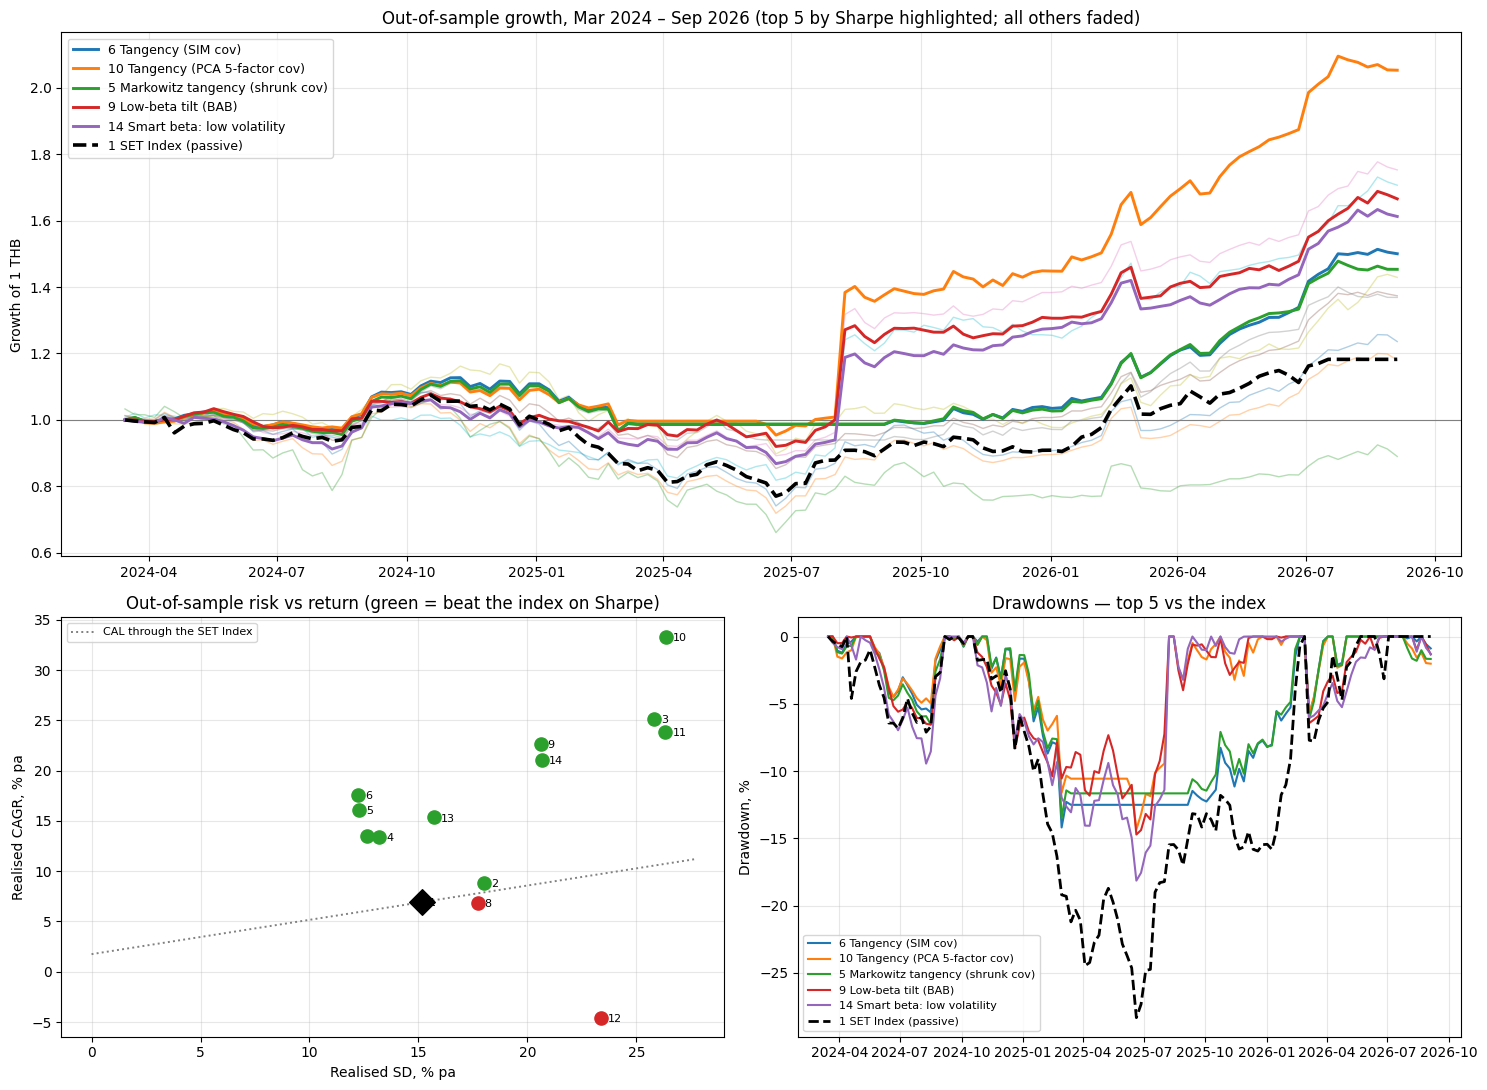

In [58]:
# ============================================================
# VI.4d The picture: growth, risk-return, drawdowns
# ============================================================
fig = plt.figure(figsize=(15, 11))
gs = fig.add_gridspec(2, 2, height_ratios=[1.25, 1])

ax1 = fig.add_subplot(gs[0, :])
top5 = list(results.index[:5])
for k in results.index:
    r = strat_rets[k]
    is_bench = "SET Index" in k
    is_top = k in top5
    ax1.plot(r.index, (1 + r).cumprod(),
             lw=2.6 if is_bench else (2.1 if is_top else 1.0),
             ls="--" if is_bench else "-",
             color="black" if is_bench else None,
             alpha=1.0 if (is_top or is_bench) else 0.35,
             label=k if (is_top or is_bench) else None,
             zorder=5 if (is_top or is_bench) else 1)
ax1.axhline(1.0, color="grey", lw=0.8)
ax1.set(ylabel="Growth of 1 THB",
        title=f"Out-of-sample growth, {strat_rets['1 SET Index (passive)'].index.min():%b %Y} – "
              f"{strat_rets['1 SET Index (passive)'].index.max():%b %Y} "
              f"(top 5 by Sharpe highlighted; all others faded)")
ax1.legend(fontsize=9, loc="upper left")

ax2 = fig.add_subplot(gs[1, 0])
for k in results.index:
    m = results.loc[k]
    is_bench = "SET Index" in k
    ax2.scatter(m["SD pa"] * 100, m["CAGR"] * 100, s=170 if is_bench else 90,
                marker="D" if is_bench else "o",
                color="black" if is_bench else ("tab:green" if m["Sharpe"] > results.loc["1 SET Index (passive)", "Sharpe"] else "tab:red"),
                zorder=6 if is_bench else 4)
    ax2.annotate(k.split(" ")[0], (m["SD pa"] * 100, m["CAGR"] * 100),
                 xytext=(5, -3), textcoords="offset points", fontsize=8)
sd_line = np.linspace(0, results["SD pa"].max() * 105, 20)
bench_sharpe = results.loc["1 SET Index (passive)", "Sharpe"]
ax2.plot(sd_line, RF_ANNUAL * 100 + bench_sharpe * sd_line, color="grey", ls=":", lw=1.4,
         label="CAL through the SET Index")
ax2.set(xlabel="Realised SD, % pa", ylabel="Realised CAGR, % pa",
        title="Out-of-sample risk vs return (green = beat the index on Sharpe)")
ax2.legend(fontsize=8)

ax3 = fig.add_subplot(gs[1, 1])
for k in top5 + ["1 SET Index (passive)"]:
    g = (1 + strat_rets[k]).cumprod()
    ax3.plot(g.index, (g / g.cummax() - 1) * 100, lw=2.0 if "SET" in k else 1.5,
             ls="--" if "SET" in k else "-", color="black" if "SET" in k else None, label=k)
ax3.set(ylabel="Drawdown, %", title="Drawdowns — top 5 vs the index")
ax3.legend(fontsize=8, loc="lower left")
plt.tight_layout(); plt.show()

Consistency across the quarterly sub-periods (rank 1 = best return that quarter)


,mean rank,best rank,worst rank,sub-periods beating SET,sub-periods positive,of N sub-periods
10 Tangency (PCA 5-factor cov),3.800000,2.000000,10.000000,8,8,10
6 Tangency (SIM cov),5.150000,2.000000,12.500000,7,7,10
5 Markowitz tangency (shrunk cov),5.650000,2.000000,12.500000,7,6,10
14 Smart beta: low volatility,6.200000,1.000000,13.000000,7,6,10
13 Smart beta: momentum,7.100000,1.000000,13.000000,6,7,10
11 Macro-APT mu + shrunk cov,7.200000,1.000000,14.000000,6,6,10
9 Low-beta tilt (BAB),7.300000,1.000000,12.000000,6,7,10
4 Markowitz tangency (sample cov),7.300000,1.000000,14.000000,7,6,10
3 GMV (shrunk cov),7.700000,2.000000,12.000000,6,6,10
7 Treynor-Black (shrunk alphas),8.200000,6.000000,11.000000,5,7,10


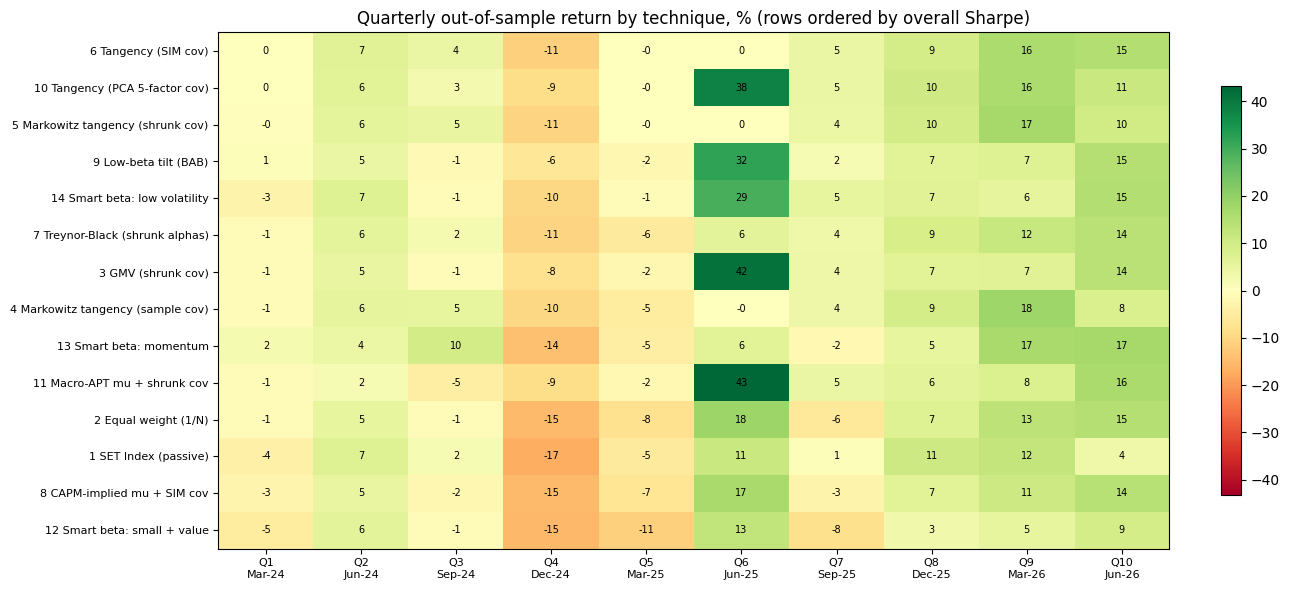

In [59]:
# ============================================================
# VI.4e Is the ranking stable, or is it one lucky quarter?
# ============================================================
# Split the out-of-sample period into the rebalancing sub-periods and rank every technique in each.
seg_bounds = [(dates[p], dates[min(p + STEP_WEEKS, len(dates) - 1)]) for p in rebal_idx]
sub_perf = {}
for i, (s0, s1) in enumerate(seg_bounds):
    lab = f"Q{i+1}\n{s0:%b-%y}"
    sub_perf[lab] = {k: float((1 + v.loc[(v.index >= s0) & (v.index < s1)]).prod() - 1)
                     for k, v in strat_rets.items()}
sub = pd.DataFrame(sub_perf)
sub = sub.reindex(results.index)

ranks = sub.rank(ascending=False, axis=0)
consistency = pd.DataFrame({
    "mean rank": ranks.mean(axis=1),
    "best rank": ranks.min(axis=1),
    "worst rank": ranks.max(axis=1),
    "sub-periods beating SET": (sub.gt(sub.loc["1 SET Index (passive)"], axis=1)).sum(axis=1),
    "sub-periods positive": (sub > 0).sum(axis=1),
})
consistency["of N sub-periods"] = sub.shape[1]
print("Consistency across the quarterly sub-periods (rank 1 = best return that quarter)")
display(consistency.sort_values("mean rank").round(2))

fig, ax = plt.subplots(figsize=(13, 6))
im = ax.imshow(sub.values * 100, cmap="RdYlGn", aspect="auto",
               vmin=-np.abs(sub.values * 100).max(), vmax=np.abs(sub.values * 100).max())
ax.set_xticks(range(sub.shape[1])); ax.set_xticklabels(sub.columns, fontsize=8)
ax.set_yticks(range(sub.shape[0])); ax.set_yticklabels(sub.index, fontsize=8)
for i in range(sub.shape[0]):
    for j in range(sub.shape[1]):
        ax.text(j, i, f"{sub.values[i,j]*100:.0f}", ha="center", va="center", fontsize=7)
ax.set_title("Quarterly out-of-sample return by technique, % (rows ordered by overall Sharpe)")
plt.colorbar(im, fraction=0.02); ax.grid(False); plt.tight_layout(); plt.show()

In [60]:
# ============================================================
# VI.4f What is each technique actually betting on?
#         Attribute every strategy's return to the SET100 factors.
# ============================================================
attrib = {}
for k, r in strat_rets.items():
    if "SET Index" in k:
        continue          # regressing the index on itself is degenerate, not informative
    out = multi_factor_fit(r, factors[["MKT_RF", "SMB", "HML", "WML", "LOWVOL"]], RF_WEEKLY, min_obs=40)
    if out:
        attrib[k] = out
att = pd.DataFrame(attrib).T.astype(float).reindex([i for i in results.index if "SET Index" not in i])
att = att.rename(columns={"b_MKT_RF": "market", "b_SMB": "size", "b_HML": "value",
                          "b_WML": "momentum", "b_LOWVOL": "low-vol"})
print("Factor exposures of each technique's OUT-OF-SAMPLE return stream, and the alpha left over")
display(att[["market", "size", "value", "momentum", "low-vol", "alpha_ann", "t_alpha", "r2"]].round(3))

print("\nHow to read this against the performance table.")
print("  * Every winning technique carries a market beta well BELOW 1 (0.32-0.68). Much of the")
print("    out-performance is simply having held less market risk in a flat market.")
print("  * The top optimisers also load NEGATIVELY on size, momentum and low-vol. They are, in")
print("    effect, large-cap defensive portfolios — smart beta arrived at by optimisation rather")
print("    than by rule.")
print("  * The 'small + value' row looks paradoxical: it LOST money (see the performance table) yet")
print("    shows a positive alpha here. That is exactly right and worth understanding — it loaded")
print("    +0.89 on SMB and +0.81 on HML, and both factors had large negative premia in this")
print("    sample. Controlling for exposures that lost money makes what is left look good. It is a")
print("    reminder that alpha is only meaningful relative to a factor model you actually believe.")
print("  * Caveat: these attribution factors are built from CURRENT size and B/M, so the SMB and")
print("    HML columns carry look-ahead bias. The market, momentum and low-vol columns do not.")

Factor exposures of each technique's OUT-OF-SAMPLE return stream, and the alpha left over


,market,size,value,momentum,low-vol,alpha_ann,t_alpha,r2
6 Tangency (SIM cov),0.538000,0.086000,0.112000,0.084000,0.049000,0.111000,1.725000,0.453000
10 Tangency (PCA 5-factor cov),0.323000,-1.195000,-0.146000,-0.656000,-0.784000,0.268000,2.461000,0.668000
5 Markowitz tangency (shrunk cov),0.555000,0.070000,0.092000,0.089000,0.037000,0.100000,1.596000,0.479000
9 Low-beta tilt (BAB),0.444000,-0.718000,-0.024000,-0.532000,-0.456000,0.202000,2.331000,0.656000
14 Smart beta: low volatility,0.506000,-0.727000,0.150000,-0.562000,-0.385000,0.212000,2.653000,0.708000
7 Treynor-Black (shrunk alphas),0.682000,0.165000,0.202000,-0.008000,0.035000,0.113000,2.548000,0.759000
3 GMV (shrunk cov),0.348000,-1.099000,-0.048000,-0.723000,-0.667000,0.228000,2.121000,0.663000
4 Markowitz tangency (sample cov),0.647000,0.050000,0.114000,0.145000,0.032000,0.057000,0.928000,0.580000
13 Smart beta: momentum,0.735000,0.067000,0.007000,0.129000,-0.177000,0.032000,0.551000,0.729000
11 Macro-APT mu + shrunk cov,0.489000,-1.051000,-0.063000,-0.628000,-0.716000,0.174000,1.650000,0.688000



How to read this against the performance table.
  * Every winning technique carries a market beta well BELOW 1 (0.32-0.68). Much of the
    out-performance is simply having held less market risk in a flat market.
  * The top optimisers also load NEGATIVELY on size, momentum and low-vol. They are, in
    effect, large-cap defensive portfolios — smart beta arrived at by optimisation rather
    than by rule.
  * The 'small + value' row looks paradoxical: it LOST money (see the performance table) yet
    shows a positive alpha here. That is exactly right and worth understanding — it loaded
    +0.89 on SMB and +0.81 on HML, and both factors had large negative premia in this
    sample. Controlling for exposures that lost money makes what is left look good. It is a
    reminder that alpha is only meaningful relative to a factor model you actually believe.
  * Caveat: these attribution factors are built from CURRENT size and B/M, so the SMB and
    HML columns carry look-ahead bias. The mar

## VI.5 The verdict

The table below pairs each technique with what it costs to run and what it actually delivered.

In [61]:
# ============================================================
# VI.5 Decision guide: what each technique needs, and what it delivered
# ============================================================
GUIDE = {
    "1 SET Index (passive)":              ("T6 CAPM",      "nothing",                 "zero cost, zero estimation error", "no way to add value"),
    "2 Equal weight (1/N)":               ("T4 diversif.", "nothing",                 "robust, cheap, hard to beat",      "ignores all risk information"),
    "3 GMV (shrunk cov)":                 ("T4 frontier",  "V only",                  "no expected returns needed",       "concentrates in low-vol names"),
    "4 Markowitz tangency (sample cov)":  ("T4 §4.2",      "mu and full V",           "the textbook optimum",             "error maximisation; V ill-conditioned"),
    "5 Markowitz tangency (shrunk cov)":  ("T4 + shrinkage","mu and V",               "tames the covariance error",       "still trusts historical mu"),
    "6 Tangency (SIM cov)":               ("T5 SIM",       "alpha, beta, sigma_eps",  "3N+2 inputs, V always invertible",  "assumes one factor, uncorrelated residuals"),
    "7 Treynor-Black (shrunk alphas)":    ("T5 §3.2",      "alphas you believe in",   "separates passive from active",     "collapses if alphas are fitted noise"),
    "8 CAPM-implied mu + SIM cov":        ("T6 SML",       "beta only",               "no alpha forecast required",        "by construction cannot beat the index"),
    "9 Low-beta tilt (BAB)":              ("T6 empirical", "beta only",               "exploits the flat empirical SML",   "a bet the anomaly persists"),
    "10 Tangency (PCA 5-factor cov)":     ("T7 statistical","returns only",           "best statistical fit of V",         "factors have no economic meaning"),
    "11 Macro-APT mu + shrunk cov":       ("T7 macro",     "macro data + 2-pass",     "economically interpretable risks",  "lambdas very noisy to estimate"),
    "12 Smart beta: small + value":       ("T7 charact.",  "size, B/M",               "the Fama-French premia",            "needs point-in-time fundamentals"),
    "13 Smart beta: momentum":            ("T7 charact.",  "prices only",             "clean, cheap signal",               "high turnover, crash risk"),
    "14 Smart beta: low volatility":      ("T7 charact.",  "prices only",             "clean signal, low drawdown",        "sector concentration"),
}
guide = pd.DataFrame(GUIDE, index=["topic", "inputs needed", "strength", "weakness"]).T
guide = guide.join(results[["CAGR", "Sharpe", "alpha pa", "t(alpha)", "max drawdown", "avg turnover"]])
guide["beat index (Sharpe)"] = np.where(
    guide.Sharpe > results.loc["1 SET Index (passive)", "Sharpe"], "YES", "no")
display(guide.sort_values("Sharpe", ascending=False).round(4))

bench_row = results.loc["1 SET Index (passive)"]
winners = results[results.Sharpe > bench_row.Sharpe]
sig_alpha = results[(results["t(alpha)"] > 2.0)]
print(f"\nTechniques beating the SET Index on Sharpe : {len(winners)} of {len(results)}")
print(f"Techniques with t(alpha) > 2               : {len(sig_alpha)} "
      f"({', '.join(sig_alpha.index[:6])})")
print(f"\nBenchmark: SET Index CAGR {bench_row.CAGR:.2%}, SD {bench_row['SD pa']:.2%}, "
      f"Sharpe {bench_row.Sharpe:.3f}, max DD {bench_row['max drawdown']:.2%}")
best = results.index[0]
print(f"Best by Sharpe: {best} — CAGR {results.loc[best,'CAGR']:.2%}, "
      f"Sharpe {results.loc[best,'Sharpe']:.3f}, alpha {results.loc[best,'alpha pa']:.2%} "
      f"(t = {results.loc[best,'t(alpha)']:.2f})")

,topic,inputs needed,strength,weakness,CAGR,Sharpe,alpha pa,t(alpha),max drawdown,avg turnover,beat index (Sharpe)
6 Tangency (SIM cov),T5 SIM,"alpha, beta, sigma_eps","3N+2 inputs, V always invertible","assumes one factor, uncorrelated residuals",0.176200,1.296900,0.120800,2.028100,-0.142000,0.522100,YES
10 Tangency (PCA 5-factor cov),T7 statistical,returns only,best statistical fit of V,factors have no economic meaning,0.333400,1.199600,0.251900,1.690900,-0.143400,0.532300,YES
5 Markowitz tangency (shrunk cov),T4 + shrinkage,mu and V,tames the covariance error,still trusts historical mu,0.161300,1.171900,0.106900,1.837700,-0.135000,0.541400,YES
9 Low-beta tilt (BAB),T6 empirical,beta only,exploits the flat empirical SML,a bet the anomaly persists,0.226400,1.013900,0.161000,1.463100,-0.147200,0.394600,YES
14 Smart beta: low volatility,T7 charact.,prices only,"clean signal, low drawdown",sector concentration,0.210600,0.934900,0.145500,1.352700,-0.181500,0.269500,YES
7 Treynor-Black (shrunk alphas),T5 §3.2,alphas you believe in,separates passive from active,collapses if alphas are fitted noise,0.135400,0.933600,0.075200,1.703100,-0.215800,0.390100,YES
3 GMV (shrunk cov),T4 frontier,V only,no expected returns needed,concentrates in low-vol names,0.251700,0.907200,0.188500,1.287500,-0.157900,0.365700,YES
4 Markowitz tangency (sample cov),T4 §4.2,mu and full V,the textbook optimum,error maximisation; V ill-conditioned,0.133800,0.880600,0.078400,1.356500,-0.156200,0.598000,YES
13 Smart beta: momentum,T7 charact.,prices only,"clean, cheap signal","high turnover, crash risk",0.153500,0.864800,0.087000,1.465600,-0.232000,0.778100,YES
11 Macro-APT mu + shrunk cov,T7 macro,macro data + 2-pass,economically interpretable risks,lambdas very noisy to estimate,0.238400,0.839000,0.169900,1.201800,-0.197900,0.672200,YES



Techniques beating the SET Index on Sharpe : 11 of 14
Techniques with t(alpha) > 2               : 1 (6 Tangency (SIM cov))

Benchmark: SET Index CAGR 6.92%, SD 15.16%, Sharpe 0.341, max DD -28.34%
Best by Sharpe: 6 Tangency (SIM cov) — CAGR 17.62%, Sharpe 1.297, alpha 12.08% (t = 2.03)


In [62]:
# ============================================================
# VI.5b How much did trading frictions matter?
# ============================================================
gross = {}
for k in strat_rets:
    if k not in turnover_log:
        gross[k] = results.loc[k, "CAGR"]
        continue
    drag = results.loc[k, "cost drag pa"]
    gross[k] = results.loc[k, "CAGR"] + drag
cost_tbl = pd.DataFrame({
    "CAGR gross of costs": pd.Series(gross),
    "CAGR net of costs": results["CAGR"],
    "cost drag pa": results["cost drag pa"],
    "avg turnover per rebalance": results["avg turnover"],
}).reindex(results.index)
display(cost_tbl.round(4))

print("At QUARTERLY rebalancing and 25 bps the drag is real but modest — 0.1% to 0.8% pa, small")
print("next to the alphas above. That is not a licence to ignore costs: drag scales linearly with")
print("both the cost assumption and the rebalancing frequency.\n")

freq_tbl = {}
for label, per_year in [("quarterly (as tested)", 4), ("monthly", 12), ("weekly", 52)]:
    freq_tbl[label] = results["avg turnover"] * TCOST * per_year
freq = pd.DataFrame(freq_tbl)
for bps in [50, 100]:
    freq[f"quarterly @ {bps}bps"] = results["avg turnover"] * (bps / 1e4) * 4
print("Annual cost drag under different trading assumptions:")
display(freq.round(4))

worst = freq["weekly"].idxmax()
print(f"\nRebalanced weekly at the same 25 bps, {worst} would pay {freq.loc[worst,'weekly']:.2%} pa")
print(f"in costs alone — against a net CAGR of {results.loc[worst,'CAGR']:.2%}. The edge would be")
print("largely gone. Turnover belongs in the comparison table, not a footnote: a technique is only")
print("as good as its return NET of the trading it requires.")

,CAGR gross of costs,CAGR net of costs,cost drag pa,avg turnover per rebalance
6 Tangency (SIM cov),0.181400,0.176200,0.005200,0.522100
10 Tangency (PCA 5-factor cov),0.338800,0.333400,0.005300,0.532300
5 Markowitz tangency (shrunk cov),0.166700,0.161300,0.005400,0.541400
9 Low-beta tilt (BAB),0.230400,0.226400,0.003900,0.394600
14 Smart beta: low volatility,0.213300,0.210600,0.002700,0.269500
7 Treynor-Black (shrunk alphas),0.139300,0.135400,0.003900,0.390100
3 GMV (shrunk cov),0.255400,0.251700,0.003700,0.365700
4 Markowitz tangency (sample cov),0.139800,0.133800,0.006000,0.598000
13 Smart beta: momentum,0.161300,0.153500,0.007800,0.778100
11 Macro-APT mu + shrunk cov,0.245100,0.238400,0.006700,0.672200


At QUARTERLY rebalancing and 25 bps the drag is real but modest — 0.1% to 0.8% pa, small
next to the alphas above. That is not a licence to ignore costs: drag scales linearly with
both the cost assumption and the rebalancing frequency.

Annual cost drag under different trading assumptions:


,quarterly (as tested),monthly,weekly,quarterly @ 50bps,quarterly @ 100bps
6 Tangency (SIM cov),0.005200,0.015700,0.067900,0.010400,0.020900
10 Tangency (PCA 5-factor cov),0.005300,0.016000,0.069200,0.010600,0.021300
5 Markowitz tangency (shrunk cov),0.005400,0.016200,0.070400,0.010800,0.021700
9 Low-beta tilt (BAB),0.003900,0.011800,0.051300,0.007900,0.015800
14 Smart beta: low volatility,0.002700,0.008100,0.035000,0.005400,0.010800
7 Treynor-Black (shrunk alphas),0.003900,0.011700,0.050700,0.007800,0.015600
3 GMV (shrunk cov),0.003700,0.011000,0.047500,0.007300,0.014600
4 Markowitz tangency (sample cov),0.006000,0.017900,0.077700,0.012000,0.023900
13 Smart beta: momentum,0.007800,0.023300,0.101100,0.015600,0.031100
11 Macro-APT mu + shrunk cov,0.006700,0.020200,0.087400,0.013400,0.026900



Rebalanced weekly at the same 25 bps, 13 Smart beta: momentum would pay 10.11% pa
in costs alone — against a net CAGR of 15.35%. The edge would be
largely gone. Turnover belongs in the comparison table, not a footnote: a technique is only
as good as its return NET of the trading it requires.


---
## VI.6 What the whole exercise says

**The techniques that won were the ones that estimated less.** Ranked by out-of-sample Sharpe, the
top of the table is the SIM covariance, the PCA covariance and the shrunk sample covariance — three
different ways of *imposing structure* on $V$ rather than trusting 4,950 individually estimated
covariances. The raw sample-covariance Markowitz portfolio, the textbook optimum, finished mid-table
below several one-line rules. Topic 5's argument for the Single Index Model is vindicated not because
it fits better — in-sample it fits worse — but because it is stable enough to survive contact with
the future.

**Expected returns are the weak link, not the covariance matrix.** Section VI.2 put three input lists
side by side: historical means, CAPM-implied returns and macro-APT returns. Their cross-sectional
correlations were near zero and in one case negative. The same optimiser, the same universe, the same
constraints — and three theories that disagree about which SET100 stocks should earn what. Every
result downstream inherits that disagreement, which is why the techniques needing **no** expected
return at all (GMV, low-beta, low-volatility) held up so well.

**The CAPM's own prediction came true, in the least glamorous way.** Technique 8 — CAPM-implied
expected returns with all alphas set to zero — produced a portfolio of ~95 names, beta 0.97, and
returned within a few basis points of the SET Index. That is not a failure of the implementation. It
is the CAPM working exactly as advertised: with no superior information, the theory says hold the
market, and the optimiser duly rebuilt the market.

**Most of the out-performance was beta timing and factor tilt, not skill.** The attribution in VI.4f
is blunt: every winning strategy ran a market beta between 0.32 and 0.68 in a market that went
roughly nowhere. Strip out the market, size, momentum and low-volatility exposures and only one
technique retained an alpha with $t>2$. The APT's message is precisely this — returns come from
factor exposures, and a portfolio that looks clever is usually a factor bet wearing a disguise.

**The APT's implementation gap is real and it showed up everywhere.** The theory is airtight: no
arbitrage implies $E[r_i]=r_F+\sum_k\beta_{i,k}\lambda_k$. But it names no factors. The statistical
route gave a PC2 dominated by a single stock. The macro route produced five risk premia, none
significant, with a cross-sectional $R^2$ under 0.10. The characteristic route produced SMB and HML
premia that were significantly **negative** — the opposite of the textbook sign — which is why the
small-value tilt was the only strategy to lose money outright. The APT tells you the form of the
answer, not the answer.

**Costs and turnover decide close races.** At quarterly rebalancing the drag was 0.1–0.8% pa, small
against the gross spreads. Move to weekly rebalancing and the high-turnover optimisers hand back most
of their edge. Any comparison of techniques that omits turnover is not a comparison of what an
investor could have earned.

### Honest limitations

One market, one five-year sample, one 130-week out-of-sample window with ten rebalances — that is not
enough to crown a winner, and the difference between a Sharpe of 1.30 and 1.17 here is well inside
noise. Index membership is today's SET100 applied to history, so survivorship bias flatters every
active strategy relative to the index. Size and value factors use current fundamentals and are
flagged as look-ahead wherever they appear. Costs are a flat 25 bps with no market impact, no
borrowing constraints and no liquidity limits, all of which would bite hardest on exactly the
concentrated, high-turnover portfolios that ranked highest. And `^SET.BK` remains a proxy for an
unobservable market portfolio, so Roll's critique applies to every CAPM result here.

What the exercise does establish is narrower and more useful than a winner: **structure beats
precision in covariance estimation, expected returns are where portfolio construction actually
breaks, and most apparent skill is factor exposure that a multi-factor model can price.**